# Linear Track — Electrophysiology Analysis
### WT vs NLGF genotype comparison · Pyramidal cells & Interneurons

---

## Overview

This notebook analyses single-unit electrophysiology recordings from mice
performing **open field exploration** and **linear track running**, comparing
wildtype (**WT**) and NLGF knock-in (**NLGF**) genotypes. Cells are classified
as Pyramidal neurons or Interneurons, and mouse identity is treated as a random
effect throughout to control for within-animal clustering.

---

## Data

- **Input:** concatenated cell-level CSV (1 row per unit) with columns for
  firing metrics, spatial metrics, theta-phase metrics, and cell identity
- **Environments:** `open_field`, `linear_track`
- **Groups:** Genotype (`WT` / `NLGF`) × Cell type (`Pyramidal` / `Interneuron`)

---

## Analysis pipeline

### 1 · Data loading & quality control
Load and cache the concatenated trials CSV, filter by environment, inspect
distributions.

### 2 · Residual diagnostics & data transforms
DHARMa simulation-based diagnostics (via `lmerTest` in R); log, log1p, logit,
Yeo-Johnson transforms on selected columns to improve normality before
parametric modelling.

### 3 · Proportion of spatial cells — binomial GLMM
Fit a binomial GLMM (`glmmTMB`) per cell type to test whether the proportion
of spatially tuned cells differs by genotype, with mouse as a random effect.

### 4 · Family-appropriate GLMMs for all metrics (`METRIC_SPECS`)
For each of 23+ metrics, fit two GLMMs (one per cell type) using the
appropriate distributional family (Gaussian, Gamma, negative-binomial, Beta),
with Genotype as the fixed effect and mouse as a random effect:

$$y \sim \text{Genotype} + (1 \mid \text{mouse})$$

Outputs: Type III ANOVA (`car::Anova`), Wald CIs, emmeans pairwise contrasts
(WT − NLGF on link scale; WT/NLGF ratio on response scale for log-link models).
Saved to per-metric Excel workbooks and `glmmTMB_genotype_summary.csv`.

### 5 · Animal-level permutation tests
For each metric × environment × cell type, aggregate to animal medians and run
a label-permutation test (10 000 iterations) on the median difference.
Null distributions and results saved to `df_perm`.

### 6 · Violin / box plots with GLMM annotations
Grid of violin + box plots per metric, colour-coded by genotype, with
significance brackets drawn from the GLMM emmeans p-values.

### 7 · Mann-Whitney U tests (non-parametric, cell-level)
For each metric × environment × cell type, run a two-sided Mann-Whitney U test
comparing WT vs NLGF cells. Effect size: rank-biserial correlation *r*.
Benjamini-Hochberg FDR correction applied across all tests.
Saved to `mannwhitney_WT_vs_NLGF_per_celltype.csv`.

### 8 · GLMM vs Mann-Whitney concordance
Head-to-head comparison of significance calls between the parametric (GLMM) and
non-parametric (MWU) approaches, classified as: both significant, GLMM only,
MWU only, or neither. Saved to `glmm_vs_mwu_concordance.csv`.

---

## Key output files

| File | Contents |
|---|---|
| `glmmTMB_genotype_summary.csv` | All GLMM genotype contrasts (emmeans) |
| `glmmTMB_<metric>.xlsx` | Per-metric ANOVA, fixed effects, emmeans sheets |
| `linear_track_2way_anova_genotype_celltype.csv` | 2-way ANOVA F-statistics |
| `mannwhitney_WT_vs_NLGF_per_celltype.csv` | Mann-Whitney U results + FDR |
| `glmm_vs_mwu_concordance.csv` | Cross-method significance concordance |

# Load the data

In [5]:
"""Linear Track Analysis
===================
This notebook performs the following analyses on the linear track data:
1. Loads and preprocesses the data.
2. Generates summary statistics and visualizations for key metrics.
3. Saves the results to the specified output directory.
"""
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import re, math, textwrap
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D
import seaborn as sns
import re
import warnings
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson', standardize=False)

from figure_style import apply_style, set_panel_title, WT, NLGF
GENO_COLORS = {"NLGF": NLGF, "WT": WT}
GENO_ORDER = ["WT", "NLGF"]
apply_style()

warnings.filterwarnings("ignore")

# Optional: nice dataframe display in notebooks (falls back to print)
try:
    from IPython.display import display  # type: ignore
    def display_df(title, x):
        print(title)
        display(x)
except Exception:
    def display_df(title, x):
        print(title)
        print(x)


# Set the input path ONCE (edit this one line only)
CSV_PATH = Path('/Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/concatenated_trials.csv')
LINEAR_TRACK_DIR = CSV_PATH.parent
# LINEAR_TRACK_OUTDIR = LINEAR_TRACK_DIR.parent / "LinearTrackAnalysis"
# (or, if you want it INSIDE the same folder as the excel:)
linear_track_OUTDIR = LINEAR_TRACK_DIR / "LinearTrackAnalysis"

linear_track_OUTDIR.mkdir(parents=True, exist_ok=True)
print("Saving outputs to:", linear_track_OUTDIR)\

df_linear_track = pd.read_csv(CSV_PATH) #select all cells in all trials

# Keep only linear track trials (handles "linear_track", "lineartrack", "Linear_Track", etc.)
df_linear_track = df_linear_track.loc[
    df_linear_track["environment"].astype(str).str.contains("linear.?track", case=False, na=False)
].copy()
print("________________________________________________________________")
print(df_linear_track["environment"].value_counts(dropna=False).head(10))
print("________________________________________________________________")
print("Dataframe:", df_linear_track.shape, df_linear_track.columns.tolist(), df_linear_track.head())

# ── Derived columns (matching confound testing notebook) ─────────────────────
df_linear_track['half_split_z'] = np.arctanh(df_linear_track['half_split_stability'].clip(-0.9999, 0.9999))
df_linear_track['odd_even_z']   = np.arctanh(df_linear_track['odd_even_stability'].clip(-0.9999, 0.9999))
df_linear_track['phase_locked'] = (df_linear_track['phase_locking_pval'] < 0.05).astype(int) # produces 1 = phase-locked (p < 0.05) and 0 = not locked (p ≥ 0.05).
df_linear_track['log_field_size'] = np.log1p(df_linear_track['field_size'])
df_linear_track['phase_locking_vector_length_locked_cells'] = df_linear_track['phase_locking_vector_length'].where(df_linear_track['phase_locked'] == 1)
df_linear_track['theta_mod_v3_log'] = np.log(df_linear_track['theta_mod_v3'] + 1e-6)  # add small constant to avoid log(0)
offset = abs(df_linear_track['theta_mod_v3'].min()) + 0.01
df_linear_track['theta_mod_v3_shifted'] = df_linear_track['theta_mod_v3'] + offset
df_linear_track['theta_mod_v3_yj'] = pt.fit_transform(df_linear_track[['theta_mod_v3']]).flatten()
df_linear_track['phase_variance_locked_cells'] = df_linear_track['phase_variance'].where(df_linear_track['phase_locked'] == 1)


# check if parket file exists and is up to date, otherwise save to parquet for faster loading next time
PARQUET_PATH = os.path.join(linear_track_OUTDIR, "linear_track.parquet")
CSV_saved_PATH = os.path.join(linear_track_OUTDIR, "linear_track.csv")
df_linear_track.to_parquet(PARQUET_PATH, index=False)
df_linear_track = pd.read_parquet(PARQUET_PATH)
df_linear_track.to_csv(CSV_saved_PATH)

print(df_linear_track.head())

Saving outputs to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis
________________________________________________________________
environment
linear_track    760
Name: count, dtype: int64
________________________________________________________________
Dataframe: (760, 36) ['filename', 'channel', 'cluster', 'num_spikes', 'mouse_name', 'Experimenter', 'Age_weeks', 'Genotype', 'spike_width', 'cell_type', 'theta_mod_v1', 'theta_mod_v2', 'theta_mod_v3', 'peak_rate', 'mean_rate', 'ahp_decay', 'field_size', 'phase_mean', 'phase_variance', 'overdispersion', 'spatial_info', 'coherence', 'phase_locking_vector_length', 'phase_locking_z_stat', 'phase_locking_pval', 'head_dir_mean_resultant_length', 'head_dir_mean_resultant_angle', 'contamination_Q', 'contamination_R', 'head_dir_kl_div', 'kl_spatial_sparsity', 'spatial_sparsity', 'environment', 'half_split_stability', 'odd_even_stability', 'thet

In [6]:
[c for c in df_linear_track.columns if 'phase' in c.lower() and 'p' in c.lower()]

['phase_mean',
 'phase_variance',
 'phase_locking_vector_length',
 'phase_locking_z_stat',
 'phase_locking_pval',
 'theta_phase_label',
 'phase_locked',
 'phase_locking_vector_length_locked_cells',
 'phase_variance_locked_cells']

In [7]:
[t for t in df_linear_track.columns if 'theta' in t.lower() and 'mod' in t.lower()]

['theta_mod_v1',
 'theta_mod_v2',
 'theta_mod_v3',
 'theta_mod_v3_log',
 'theta_mod_v3_shifted',
 'theta_mod_v3_yj']

In [8]:
# Count how many cells we recorded in total (and median per mouse) and also for each genotype and environment
no_cells_total = len(df_linear_track)
no_cells_per_mouse = df_linear_track.groupby('mouse_name').size()
no_cells_per_genotype = df_linear_track.groupby('Genotype').size()
no_cells_per_environment = df_linear_track.groupby('environment').size()  
print(f"Total number of cells recorded: {no_cells_total}")
print(f"Median number of cells per mouse: {no_cells_per_mouse.median()}")
print(f"Number of cells per genotype:\n{no_cells_per_genotype}")    
print(f"Number of cells per environment:\n{no_cells_per_environment}")    

Total number of cells recorded: 760
Median number of cells per mouse: 45.0
Number of cells per genotype:
Genotype
NLGF    367
WT      393
dtype: int64
Number of cells per environment:
environment
linear_track    760
dtype: int64


## % of Pyramidal vs Interneurons

Cell type counts per genotype:
 cell_type  Interneuron  Pyramidal
Genotype                         
WT                 101        292
NLGF               146        221

Cell type proportions per genotype:
 cell_type  Interneuron  Pyramidal
Genotype                         
WT            0.256997   0.743003
NLGF          0.397820   0.602180
Saved cell type proportions figure to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/cell_type_proportions_per_genotype.pdf


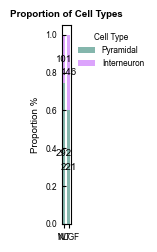

In [9]:
import matplotlib.pyplot as plt


cell_type_counts = (
df_linear_track
.groupby('Genotype')['cell_type']
.value_counts()
.unstack(fill_value=0)
)

cell_type_counts = cell_type_counts.reindex(['WT', 'NLGF']).fillna(0)
print("Cell type counts per genotype:\n", cell_type_counts)

cell_type_proportions = cell_type_counts.div(cell_type_counts.sum(axis=1), axis=0)
print("\nCell type proportions per genotype:\n", cell_type_proportions)

# Plot proportions of cell types per genotype
cell_type_proportions = (
    cell_type_proportions
    .reindex(['WT', 'NLGF'])
    .dropna(how='all')
)

# Put pyramidal first so it appears at the bottom of the stacked bars
cell_type_proportions = cell_type_proportions.reindex(
    columns=['Pyramidal', 'Interneuron'],
    fill_value=0
)

cell_type_counts = cell_type_counts.reindex(
    index=['WT', 'NLGF'],
    columns=['Pyramidal', 'Interneuron'],
    fill_value=0
)

ax = cell_type_proportions.plot(
    kind='bar',
    stacked=True,
    figsize=(1.67, 2.5),
    color=["#076B577E", "#a20bf95f"]  # PYR, INS
)

# Add count labels inside each stacked bar segment
for container, col in zip(ax.containers, cell_type_proportions.columns):
    labels = [
        f"{int(v)}" if v > 0 else ""
        for v in cell_type_counts[col].values
    ]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=7, color='black')

set_panel_title(ax, 'Proportion of Cell Types')
plt.xlabel(None)
plt.xticks(rotation=0)
plt.ylabel('Proportion %', fontsize=7, fontweight='regular')
plt.legend(title='Cell Type')
plt.legend(title='Cell Type', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.savefig(linear_track_OUTDIR / "cell_type_proportions_per_genotype.pdf")
print("Saved cell type proportions figure to:", linear_track_OUTDIR / "cell_type_proportions_per_genotype.pdf")


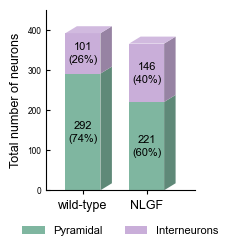

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/cell_type_counts_3d_excel_style.pdf


In [10]:
# 3D STACKED BAR PLOT for total number of neurons by cell type (Excel-style pseudo-3D)
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

def _lighten(hex_color, amount=0.25):
    c = np.array(mcolors.to_rgb(hex_color))
    white = np.array([1, 1, 1])
    return tuple(c + (white - c) * amount)

def _darken(hex_color, amount=0.25):
    c = np.array(mcolors.to_rgb(hex_color))
    return tuple(c * (1 - amount))

PYR_COLOR = "#7FB6A0"   # teal/sage — Pyramidal
INS_COLOR = "#C9AED9"   # lilac — Interneurons
LABEL_DISPLAY = {'WT': 'wild-type', 'NLGF': 'NLGF'}

genos = ['WT', 'NLGF']
bar_width = 0.55
depth_x = 0.18
depth_y = cell_type_counts.values.max() * 0.06  # pseudo-3D skew depth

fig, ax = plt.subplots(figsize=(2.2, 2.5))


for xi, g in enumerate(genos):
    x0 = xi
    y0 = 0
    for ct, color in zip(['Pyramidal', 'Interneuron'], [PYR_COLOR, INS_COLOR]):
        h = cell_type_counts.loc[g, ct]
        pct = cell_type_proportions.loc[g, ct] * 100

        # front face
        ax.add_patch(mpatches.Rectangle(
            (x0, y0), bar_width, h,
            facecolor=color, edgecolor='none', linewidth=0, zorder=2
        ))
        # right-side face (depth shading)
        ax.add_patch(mpatches.Polygon([
            (x0 + bar_width, y0),
            (x0 + bar_width + depth_x, y0 + depth_y),
            (x0 + bar_width + depth_x, y0 + depth_y + h),
            (x0 + bar_width, y0 + h)
        ], facecolor=_darken(color), edgecolor='none', linewidth=0, zorder=1))
        # count label
        ax.text(x0 + bar_width / 2, y0 + h / 2, f"{int(h)}\n({pct:.0f}%)",
                ha='center', va='center', fontsize=8, color='black', zorder=3,
                linespacing=1.4)

        y0 += h

    # top cap on the uppermost segment
    ax.add_patch(mpatches.Polygon([
        (x0, y0),
        (x0 + bar_width, y0),
        (x0 + bar_width + depth_x, y0 + depth_y),
        (x0 + depth_x, y0 + depth_y)
    ], facecolor=_lighten(INS_COLOR, 0.15), edgecolor='none', linewidth=0, zorder=2))

ymax = cell_type_counts.sum(axis=1).max()
ax.set_xlim(-0.3, len(genos) - 1 + bar_width + depth_x + 0.3)
ax.set_ylim(0, ymax * 1.15)
ax.set_xticks(np.arange(len(genos)) + bar_width / 2)
ax.set_xticklabels([LABEL_DISPLAY[g] for g in genos], fontsize=9)
ax.set_ylabel("Total number of neurons", fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

legend_handles = [
    mpatches.Patch(facecolor=PYR_COLOR, label='Pyramidal'),
    mpatches.Patch(facecolor=INS_COLOR, label='Interneurons')
]
ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, -0.14),
          ncol=2, frameon=False, fontsize=8)

plt.tight_layout()
out_path_3d = linear_track_OUTDIR / "cell_type_counts_3d_excel_style.pdf"
plt.savefig(out_path_3d, bbox_inches='tight')
plt.show()
print(f"Saved: {out_path_3d}")

In [11]:
#  Chi=square analysis to test for differences in cell type distribution between genotypes
from scipy.stats import chi2_contingency
contingency_table = cell_type_counts.values
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square statistic: {chi2:.6f}, p-value: {p:.6f}, degrees of freedom: {dof}")
print(f"Expected counts under null hypothesis:\n{pd.DataFrame(expected, index=cell_type_counts.index, columns=cell_type_counts.columns)}")

Chi-square statistic: 16.519574, p-value: 0.000048, degrees of freedom: 1
Expected counts under null hypothesis:
cell_type  Pyramidal  Interneuron
Genotype                         
WT           265.275      127.725
NLGF         247.725      119.275


In [12]:
# Compute odds ratio for being an interneuron in NLGF vs WT
wt_interneurons = cell_type_counts.loc['WT', 'Interneuron']
wt_pyramidal = cell_type_counts.loc['WT', 'Pyramidal']
nlgf_interneurons = cell_type_counts.loc['NLGF', 'Interneuron']
nlgf_pyramidal = cell_type_counts.loc['NLGF', 'Pyramidal']
odds_wt = wt_interneurons / wt_pyramidal if wt_pyramidal > 0 else np.inf
odds_nlgf = nlgf_interneurons / nlgf_pyramidal if nlgf_pyramidal > 0 else np.inf
odds_ratio = odds_nlgf / odds_wt if odds_wt > 0 else np.inf
print(f"Odds of being an interneuron in WT: {odds_wt:.4f}")
print(f"Odds of being an interneuron in NLGF: {odds_nlgf:.4f}")
print(f"Odds ratio (NLGF vs WT): {odds_ratio:.4f}") 

Odds of being an interneuron in WT: 0.3459
Odds of being an interneuron in NLGF: 0.6606
Odds ratio (NLGF vs WT): 1.9100


In [13]:
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr
import rpy2.robjects as ro
import numpy as np
import pandas as pd

importr('glmmTMB')
importr('emmeans')

# ── Build cell-level data ─────────────────────────────────────────────────────
cell_level_data = df_linear_track[['cell_type', 'Genotype', 'mouse_name']].dropna().copy()
cell_level_data['is_interneuron'] = (
    cell_level_data['cell_type']
    .astype(str)
    .str.contains('interneuron', case=False, na=False)
    .astype(int)
)

with localconverter(ro.default_converter + pandas2ri.converter):
    ro.globalenv['cell_level_data'] = ro.conversion.py2rpy(cell_level_data)

# ── Fit GLMM ─────────────────────────────────────────────────────────────────
ro.r('''
    cell_level_data$Genotype   <- relevel(factor(cell_level_data$Genotype), ref = "WT")
    cell_level_data$mouse_name <- factor(cell_level_data$mouse_name)
    cell_level_data$is_interneuron <- as.integer(cell_level_data$is_interneuron)

    m <- glmmTMB(
        is_interneuron ~ Genotype + (1|mouse_name),
        data   = cell_level_data,
        family = binomial(link = "logit"),
        control = glmmTMBControl(optimizer = optim, optArgs = list(method = "BFGS"))
    )

    fe      <- as.data.frame(coef(summary(m))$cond)
    re_var  <- as.numeric(VarCorr(m)$cond$mouse_name[1,1])
    aic_val <- AIC(m)
    conv    <- isTRUE(m$sdr$pdHess)

    # emmeans: OR with 95% CI
    emm   <- emmeans(m, ~ Genotype, type = "response")
    ph_df <- as.data.frame(pairs(emm, reverse = TRUE))

    # Wald CI on OR scale
    ci      <- confint(m, parm = "beta_", method = "Wald")
    ci_resp <- as.data.frame(exp(ci))
''')

# ── Pull results back to Python ───────────────────────────────────────────────
with localconverter(ro.default_converter + pandas2ri.converter):
    fe_df  = ro.conversion.rpy2py(ro.r('fe'))
    ph_df  = ro.conversion.rpy2py(ro.r('ph_df'))
    ci_df  = ro.conversion.rpy2py(ro.r('ci_resp'))

fe_df = fe_df.rename(columns={
    'Estimate':   'estimate',
    'Std. Error': 'SE',
    'z value':    'z',
    'Pr(>|z|)':   'p_value'
})

re_var    = float(ro.r('re_var')[0])
aic_val   = float(ro.r('aic_val')[0])
converged = bool(ro.r('conv')[0])

# ── Print results ─────────────────────────────────────────────────────────────
print(f"Converged : {converged}")
print(f"AIC       : {aic_val:.2f}")
print(f"RE variance (mouse): {re_var:.4f}")
print()
print("Fixed effects:")
print(fe_df.round(4))
print()
print("Emmeans pairwise contrast (OR scale):")
print(ph_df.round(4))
print()
print("Wald 95% CI on OR scale:")
print(ci_df.round(3))

# ── Interpret NLGF effect ─────────────────────────────────────────────────────
nlgf_row = fe_df[fe_df.index.astype(str).str.contains('NLGF')]
if not nlgf_row.empty:
    est  = float(nlgf_row['estimate'].iloc[0])
    pval = float(nlgf_row['p_value'].iloc[0])
    OR   = np.exp(est)
    stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    print(f"\nNLGF vs WT  |  log-odds = {est:.4f}  |  OR = {OR:.4f}  |  p = {pval:.4g} {stars}")

# ── Save ──────────────────────────────────────────────────────────────────────
out_stem = linear_track_OUTDIR / "interneuron_proportion_glmm"
fe_df.to_csv(f"{out_stem}_fixed_effects.csv", index=True)
ph_df.to_csv(f"{out_stem}_emmeans_contrast.csv", index=False)
ci_df.to_csv(f"{out_stem}_CI_OR_scale.csv", index=True)
print(f"\nSaved to: {out_stem}_*.csv")

Converged : True
AIC       : 829.33
RE variance (mouse): 0.9947

Fixed effects:
              estimate      SE       z  p_value
(Intercept)    -1.2372  0.3791 -3.2633   0.0011
GenotypeNLGF    0.6055  0.5215  1.1612   0.2456

Emmeans pairwise contrast (OR scale):
    contrast  odds.ratio      SE   df  null  z.ratio  p.value
1  NLGF / WT      1.8322  0.9555  inf   1.0   1.1612   0.2456

Wald 95% CI on OR scale:
              2.5 %  97.5 %  Estimate
(Intercept)   0.138   0.610     0.290
GenotypeNLGF  0.659   5.092     1.832

NLGF vs WT  |  log-odds = 0.6055  |  OR = 1.8322  |  p = 0.2456 ns

Saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/interneuron_proportion_glmm_*.csv


In [14]:
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr
import rpy2.robjects as ro
import numpy as np
import pandas as pd

importr('glmmTMB')
importr('emmeans')

OUTLIER_MOUSE = '733075'  # NLGF, 81-87% interneuron in both environments

def fit_interneuron_glmm(df_env, env_label, exclude_mice=None, outdir=None):
    """
    Fit is_interneuron ~ Genotype + (1|mouse_name) on a given environment subset.
    exclude_mice: list of mouse_name values to drop (for sensitivity checks).
    """
    cell_level_data = df_env[['cell_type', 'Genotype', 'mouse_name']].dropna().copy()
    cell_level_data['mouse_name'] = cell_level_data['mouse_name'].astype(str)

    excluded_n = 0
    if exclude_mice:
        exclude_mice = [str(m) for m in exclude_mice]
        excluded_n = cell_level_data['mouse_name'].isin(exclude_mice).sum()
        cell_level_data = cell_level_data[~cell_level_data['mouse_name'].isin(exclude_mice)]

    cell_level_data['is_interneuron'] = (
        cell_level_data['cell_type']
        .astype(str)
        .str.contains('interneuron', case=False, na=False)
        .astype(int)
    )

    with localconverter(ro.default_converter + pandas2ri.converter):
        ro.globalenv['cell_level_data'] = ro.conversion.py2rpy(cell_level_data)

    ro.r('''
        cell_level_data$Genotype   <- relevel(factor(cell_level_data$Genotype), ref = "WT")
        cell_level_data$mouse_name <- factor(cell_level_data$mouse_name)
        cell_level_data$is_interneuron <- as.integer(cell_level_data$is_interneuron)

        m <- glmmTMB(
            is_interneuron ~ Genotype + (1|mouse_name),
            data   = cell_level_data,
            family = binomial(link = "logit"),
            control = glmmTMBControl(optimizer = optim, optArgs = list(method = "BFGS"))
        )

        fe      <- as.data.frame(coef(summary(m))$cond)
        re_var  <- as.numeric(VarCorr(m)$cond$mouse_name[1,1])
        aic_val <- AIC(m)
        conv    <- isTRUE(m$sdr$pdHess)

        emm   <- emmeans(m, ~ Genotype, type = "response")
        ph_df <- as.data.frame(pairs(emm, reverse = TRUE))

        ci      <- confint(m, parm = "beta_", method = "Wald")
        ci_resp <- as.data.frame(exp(ci))
    ''')

    with localconverter(ro.default_converter + pandas2ri.converter):
        fe_df = ro.conversion.rpy2py(ro.r('fe'))
        ph_df = ro.conversion.rpy2py(ro.r('ph_df'))
        ci_df = ro.conversion.rpy2py(ro.r('ci_resp'))

    fe_df = fe_df.rename(columns={
        'Estimate': 'estimate', 'Std. Error': 'SE',
        'z value': 'z', 'Pr(>|z|)': 'p_value'
    })

    re_var    = float(ro.r('re_var')[0])
    aic_val   = float(ro.r('aic_val')[0])
    converged = bool(ro.r('conv')[0])

    nlgf_row = fe_df[fe_df.index.astype(str).str.contains('NLGF')]
    est  = float(nlgf_row['estimate'].iloc[0])
    pval = float(nlgf_row['p_value'].iloc[0])
    OR   = np.exp(est)

    summary = {
        'environment': env_label,
        'n_cells': len(cell_level_data),
        'n_animals': cell_level_data['mouse_name'].nunique(),
        'excluded_mice': ','.join(exclude_mice) if exclude_mice else 'none',
        'n_excluded_cells': excluded_n,
        'converged': converged,
        'AIC': round(aic_val, 2),
        'RE_var_mouse': round(re_var, 4),
        'log_odds_NLGF': round(est, 4),
        'OR_NLGF': round(OR, 4),
        'p_value': pval,
    }

    if outdir is not None:
        suffix = '_excl_outlier' if exclude_mice else ''
        stem = outdir / f"interneuron_proportion_glmm_{env_label}{suffix}"
        fe_df.to_csv(f"{stem}_fixed_effects.csv", index=True)
        ph_df.to_csv(f"{stem}_emmeans_contrast.csv", index=False)
        ci_df.to_csv(f"{stem}_CI_OR_scale.csv", index=True)

    return fe_df, ph_df, ci_df, summary


# ── Run full model + sensitivity (excl. mouse 733075) for both environments ──
results = []

for env_label, df_env, outdir in [
    # ('open_field', df_open_field, OPEN_FIELD_OUTDIR),
    ('linear_track', df_linear_track, linear_track_OUTDIR),
]:
    _, _, _, full_summary = fit_interneuron_glmm(df_env, env_label, outdir=outdir)
    results.append(full_summary)

    _, _, _, excl_summary = fit_interneuron_glmm(
        df_env, env_label, exclude_mice=[OUTLIER_MOUSE], outdir=outdir
    )
    results.append(excl_summary)

sensitivity_df = pd.DataFrame(results)
print(sensitivity_df.to_string(index=False))

sensitivity_df.to_csv(linear_track_OUTDIR / "interneuron_glmm_sensitivity_summary.csv", index=False)

 environment  n_cells  n_animals excluded_mice  n_excluded_cells  converged    AIC  RE_var_mouse  log_odds_NLGF  OR_NLGF  p_value
linear_track      760         17          none                 0       True 829.33        0.9947         0.6055   1.8322 0.245569
linear_track      692         16        733075                68       True 766.11        0.5864         0.2658   1.3044 0.537133


## Mann-Whitney test for % of neuronal cell type

In [15]:
from scipy.stats import mannwhitneyu

# Animal-level cell-type composition (one row per animal)
key = ["filename", "channel", "cluster", "mouse_name"]
per_animal = (
    df_linear_track
    .drop_duplicates(subset=key)
    .groupby(["mouse_name", "Genotype"])["cell_type"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .mul(100)
    .rename(columns={"Pyramidal": "pct_pyramidal", "Interneuron": "pct_interneuron"})
    .reset_index()
)

for metric in ["pct_pyramidal", "pct_interneuron"]:
    wt   = per_animal.loc[per_animal["Genotype"] == "WT",   metric].values
    nlgf = per_animal.loc[per_animal["Genotype"] == "NLGF", metric].values
    u_stat, p_value = mannwhitneyu(wt, nlgf, alternative="two-sided")
    print(f"{metric}: WT median={np.median(wt):.1f}%, NLGF median={np.median(nlgf):.1f}%  "
          f"(U={u_stat:.1f}, p={p_value:.4f})")


pct_pyramidal: WT median=80.4%, NLGF median=65.0%  (U=46.0, p=0.3704)
pct_interneuron: WT median=19.6%, NLGF median=35.0%  (U=26.0, p=0.3704)


## Permutation test using median

In [16]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

RNG_SEED = 42
N_PERMUTATIONS = 10000

df = pd.read_csv(CSV_PATH)

def median_permutation_test(group_a, group_b, n_perm=N_PERMUTATIONS, seed=RNG_SEED):
    """Two-sided permutation test on the difference of medians (WT - NLGF)."""
    rng = np.random.default_rng(seed)
    observed_diff = np.median(group_a) - np.median(group_b)
    pooled = np.concatenate([group_a, group_b])
    n_a = len(group_a)

    perm_diffs = np.empty(n_perm)
    for i in range(n_perm):
        shuffled = rng.permutation(pooled)
        perm_diffs[i] = np.median(shuffled[:n_a]) - np.median(shuffled[n_a:])

    p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
    return observed_diff, p_value


def animal_level_composition_test(df_env, env_label, outdir=None):
    key = ['filename', 'channel', 'cluster', 'mouse_name']
    uniq = df_env.drop_duplicates(subset=key)

    per_animal = uniq.groupby(['mouse_name', 'Genotype']).apply(lambda g: pd.Series({
        'n_cells': len(g),
        'n_IN': (g['cell_type'] == 'Interneuron').sum(),
        'n_Pyr': (g['cell_type'] == 'Pyramidal').sum(),
        'prop_IN': (g['cell_type'] == 'Interneuron').mean(),
    })).reset_index()

    wt = per_animal.loc[per_animal.Genotype == 'WT', 'prop_IN'].values
    nlgf = per_animal.loc[per_animal.Genotype == 'NLGF', 'prop_IN'].values

    u_stat, mwu_p = mannwhitneyu(wt, nlgf, alternative='two-sided')
    med_diff, perm_p = median_permutation_test(wt, nlgf)

    summary = {
        'environment': env_label,
        'n_animals_WT': len(wt),
        'n_animals_NLGF': len(nlgf),
        'median_prop_IN_WT': round(np.median(wt), 4),
        'median_prop_IN_NLGF': round(np.median(nlgf), 4),
        'median_diff_WT_minus_NLGF': round(med_diff, 4),
        'mannwhitney_U': u_stat,
        'mannwhitney_p': round(mwu_p, 4),
        'permutation_p': round(perm_p, 4),
    }

    if outdir is not None:
        per_animal.to_csv(outdir / f"interneuron_proportion_per_animal_{env_label}.csv", index=False)

    return per_animal, summary


results = []
for env_label, df_env, outdir in [
    # ('open_field', df[df.environment == 'open_field'], OPEN_FIELD_OUTDIR),
    ('linear_track', df[df.environment == 'linear_track'], linear_track_OUTDIR),
]:
    per_animal, summary = animal_level_composition_test(df_env, env_label, outdir=outdir)
    results.append(summary)
    print(f"\n{env_label}:")
    print(per_animal.to_string(index=False))

summary_df = pd.DataFrame(results)
print("\nAnimal-level composition test summary:")
print(summary_df.to_string(index=False))

summary_df.to_csv(linear_track_OUTDIR / "interneuron_composition_animal_level_summary.csv", index=False)


linear_track:
 mouse_name Genotype  n_cells  n_IN  n_Pyr  prop_IN
     644788     NLGF     25.0   6.0   19.0 0.240000
     667893       WT     33.0   4.0   29.0 0.121212
     708153     NLGF     48.0   4.0   44.0 0.083333
     719648       WT     45.0   9.0   36.0 0.200000
     726050       WT     52.0  26.0   26.0 0.500000
     726857     NLGF     36.0   4.0   32.0 0.111111
     733075     NLGF     68.0  59.0    9.0 0.867647
    1116806     NLGF     48.0  21.0   27.0 0.437500
    1116808     NLGF     65.0  18.0   47.0 0.276923
    1116810     NLGF     27.0  10.0   17.0 0.370370
    1117201     NLGF     30.0  17.0   13.0 0.566667
    1117425     NLGF     20.0   7.0   13.0 0.350000
    1117537       WT     33.0   8.0   25.0 0.242424
    1118466       WT     53.0  29.0   24.0 0.547170
    1118467       WT     90.0  12.0   78.0 0.133333
    1118468       WT     52.0  10.0   42.0 0.192308
    1118674       WT     35.0   3.0   32.0 0.085714

Animal-level composition test summary:
 environm

# Spatial information analysis

## Spatial Information Shuffle Distribution

Array shape: (380000,)
dtype: float64
Total shuffle values: 380,000
Min: 0.0017, Max: 2.0424

95th percentile threshold: 0.5707


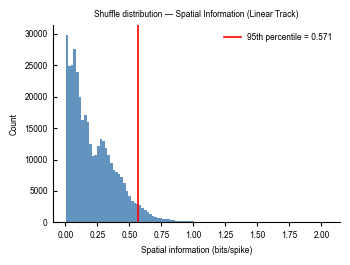

Saved shuffle distribution figure to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/SI_shuffle_linear_track.pdf


In [17]:
"""
Spatial Information Shuffle Distribution
"""

import numpy as np
import matplotlib.pyplot as plt

# Load shuffle results
linear_track_SI_shuffle_results = np.load(
    '/Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/shuffles/spatial_info/linear_track/spatial_info_shuffle.npy',
    allow_pickle=True
)

# Flatten all shuffle values into one distribution
# Shape depends on how the shuffle was saved - check first
print("Array shape:", linear_track_SI_shuffle_results.shape)
print("dtype:", linear_track_SI_shuffle_results.dtype)

# If it's an object array (ragged), flatten like this:
if linear_track_SI_shuffle_results.dtype == object:
    shuffle_flat = np.concatenate([x.flatten() for x in linear_track_SI_shuffle_results])
else:
    shuffle_flat = linear_track_SI_shuffle_results.flatten()

print(f"Total shuffle values: {len(shuffle_flat):,}")
print(f"Min: {shuffle_flat.min():.4f}, Max: {shuffle_flat.max():.4f}")

# Compute 95th percentile threshold
threshold_95 = np.percentile(shuffle_flat, 95)
print(f"\n95th percentile threshold: {threshold_95:.4f}")

import matplotlib.pyplot as plt
import os

# -------------------------
# Single-column figure size
# ~8.5 cm wide = 3.35 inches
# -------------------------
fig, ax = plt.subplots(figsize=(3.35, 2.5))

# Histogram
ax.hist(
    shuffle_flat,
    bins=100,
    color='steelblue',
    edgecolor='none',
    alpha=0.85
)

# Threshold line
ax.axvline(
    threshold_95,
    color='red',
    linewidth=1.2,
    label=f'95th percentile = {threshold_95:.3f}'
)

# Labels
ax.set_xlabel('Spatial information (bits/spike)')
ax.set_ylabel('Count')
ax.set_title('Shuffle distribution — Spatial Information (Linear Track)')

# Optional: shorter title or remove entirely
# (many journals prefer panel labels added in Illustrator)
# ax.set_title('Shuffle distribution')

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
ax.legend(frameon=False)

# Optional: set x-axis limits to zoom in on the relevant range
# ax.set_xlim(0, threshold_95 * 1.5)

# Tight layout
plt.tight_layout(pad=0.3)

# Save
plt.savefig(
    os.path.join(linear_track_OUTDIR, 'SI_shuffle_linear_track.pdf'),
    bbox_inches='tight',
    transparent=True
)

plt.show()
print("Saved shuffle distribution figure to:", linear_track_OUTDIR / 'SI_shuffle_linear_track.pdf')

In [18]:
"""
Classifying cells as spatial vs non-spatial based on the 95th percentile threshold from the shuffle distribution
"""

print(f"Applying spatial info threshold: {threshold_95:.4f}")

df_linear_track['is_spatial'] = df_linear_track['spatial_info'] > threshold_95
df_linear_track['is_spatial'] = df_linear_track['is_spatial'].astype(int)  # Convert boolean to int (1 for spatial, 0 for non-spatial)
print(df_linear_track[['spatial_info', 'is_spatial']].head())

append_path = os.path.join(linear_track_OUTDIR, "linear_track_with_spatial_flag.csv")
df_linear_track.to_csv(append_path, index=False)
print("\nDataframe with spatial flag saved to:", append_path)

# Summary by genotype and cell type
summary = df_linear_track.groupby(['Genotype', 'cell_type']).agg(
    n_cells=('is_spatial', 'count'),
    n_spatial=('is_spatial', 'sum'),
    pct_spatial=('is_spatial', 'mean')
).reset_index()

summary['pct_spatial'] = summary['pct_spatial'] * 100
save_path = linear_track_OUTDIR / "spatial_cell_summary.csv"
summary.to_csv(save_path, index=False)
print(summary.to_string(index=False))
print("\nSummary saved to:", save_path)

Applying spatial info threshold: 0.5707
   spatial_info  is_spatial
0      0.081061           0
1      0.418782           0
2      0.498397           0
3      0.097655           0
4      0.050080           0

Dataframe with spatial flag saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/linear_track_with_spatial_flag.csv
Genotype   cell_type  n_cells  n_spatial  pct_spatial
    NLGF Interneuron      146          8     5.479452
    NLGF   Pyramidal      221         67    30.316742
      WT Interneuron      101         12    11.881188
      WT   Pyramidal      292        132    45.205479

Summary saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/spatial_cell_summary.csv


## Animal-level summary


Animal-level summary saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/animal_level_spatial_summary.csv
    mouse_name Genotype  n_spatial  n_total  pct_spatial
0       644788     NLGF          6       19    31.578947
1       667893       WT          8       29    27.586207
2       708153     NLGF          3       44     6.818182
3       719648       WT         18       36    50.000000
4       726050       WT          4       26    15.384615
5       726857     NLGF          5       32    15.625000
6       733075     NLGF          4        9    44.444444
7      1116806     NLGF          4       27    14.814815
8      1116808     NLGF         35       47    74.468085
9      1116810     NLGF          0       17     0.000000
10     1117201     NLGF          6       13    46.153846
11     1117425     NLGF          4       13    30.769231
12     1117537       WT         12       25 

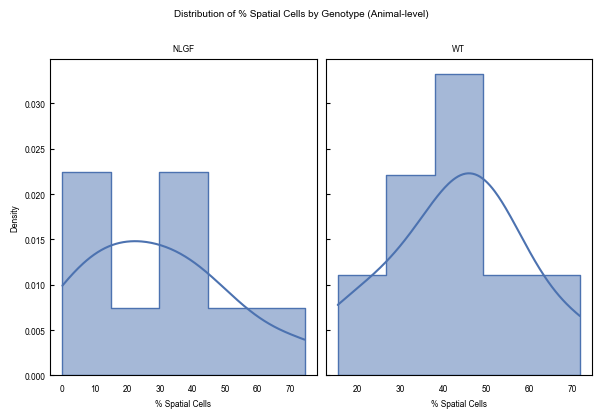

Shapiro-Wilk test for NLGF: W=0.9473, p=0.6600
  Normally distributed
Shapiro-Wilk test for WT: W=0.9396, p=0.6070
  Normally distributed


In [19]:
"""
Animal-level summary is also useful for checking the data 
and for fitting a binomial GLMM to test for differences 
in the proportion of spatial cells by genotype, 
controlling for cell type and mouse as a random effect.
"""
import pandas as pd
import numpy as np

# You need cell-level data with is_spatial (0/1), Genotype, cell_type, mouse_name
# Then fit a binomial GLMM in R (easiest) or Python via statsmodels/bambi

# Create animal-level summary first to check the data
animal_summary = df_linear_track[df_linear_track['cell_type'] == 'Pyramidal'].groupby(['mouse_name', 'Genotype']).agg(
    n_spatial=('is_spatial', 'sum'),
    n_total=('is_spatial', 'count')
).reset_index()
animal_summary['pct_spatial'] = animal_summary['n_spatial'] / animal_summary['n_total'] * 100
save_path = linear_track_OUTDIR / "animal_level_spatial_summary.csv"
animal_summary.to_csv(save_path, index=False)
print("\nAnimal-level summary saved to:", save_path)
print(animal_summary)

#check whether the pct_spatial values are normally distributed for each genotype (make 2 histograms)
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")
apply_style()
genotypes = animal_summary['Genotype'].unique()

fig, axes = plt.subplots(1, len(genotypes), figsize=(6, 4), sharey=True)

for ax, geno in zip(axes, genotypes):
    subset = animal_summary[animal_summary['Genotype'] == geno]
    sns.histplot(data=subset, x='pct_spatial', kde=True, element='step', stat='density', ax=ax)
    ax.set_title(geno)
    ax.set_xlabel('% Spatial Cells')
    ax.set_ylabel('Density')
    

fig.suptitle('Distribution of % Spatial Cells by Genotype (Animal-level)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(linear_track_OUTDIR, 'pct_spatial_distribution_by_genotype.pdf'), bbox_inches='tight', transparent=True)
plt.show()

#check whether the pct_spatial values are normally distributed for each genotype using statistics
from scipy.stats import shapiro
for genotype in animal_summary['Genotype'].unique():
    subset = animal_summary[animal_summary['Genotype'] == genotype]['pct_spatial']
    stat, p = shapiro(subset)
    print(f"Shapiro-Wilk test for {genotype}: W={stat:.4f}, p={p:.4f}") 
    print(f"  {'Normally distributed' if p > 0.05 else 'Not normally distributed'}")



## Fit a binomial GLMM to test for differences in the proportion of spatial cells by genotype, controlling for cell type and mouse as a random effect.


In [20]:
"""
Fit separate binomial GLMMs for each cell type to test
whether the probability of a cell being spatial
differs by genotype, with mouse included as a random intercept.
"""

import pandas as pd
import numpy as np
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr

glmmTMB = importr('glmmTMB')
emmeans = importr('emmeans')
base    = importr('base')

def run_spatial_glmm(df, cell_type):
    sub = df[df['cell_type'] == cell_type][['is_spatial', 'Genotype', 'mouse_name']].copy()
    sub = sub.dropna()

    # Convert to R dataframe
    with localconverter(ro.default_converter + pandas2ri.converter):
        r_df = ro.conversion.py2rpy(sub)
    ro.globalenv['r_df'] = r_df

    ro.r('r_df$Genotype   <- relevel(factor(r_df$Genotype), ref = "WT")')
    ro.r('r_df$mouse_name <- factor(r_df$mouse_name)')
    ro.r('r_df$is_spatial <- as.integer(r_df$is_spatial)')

    ro.r('''
        m <- glmmTMB(
            is_spatial ~ Genotype + (1 | mouse_name),
            data   = r_df,
            family = binomial(link = "logit")
        )
    ''')

    ro.r('s  <- summary(m)')
    ro.r('fe <- as.data.frame(coef(s)$cond)')

    with localconverter(ro.default_converter + pandas2ri.converter):
        fe_df = ro.conversion.rpy2py(ro.r('fe'))
    fe_df = fe_df.rename(columns={
    'Estimate': 'estimate',
    'Std. Error': 'SE',
    'z value': 'z',
    'Pr(>|z|)': 'p_value'
})

    re_var = ro.r('as.numeric(VarCorr(m)$cond$mouse_name)')[0]
    aic    = ro.r('AIC(m)')[0]

    # GLMM-predicted probability per genotype, back-transformed with 95% CI
    ro.r('emm <- emmeans::emmeans(m, ~ Genotype, type = "response")')
    with localconverter(ro.default_converter + pandas2ri.converter):
        emm_df = ro.conversion.rpy2py(ro.r('as.data.frame(emm)'))
    emm_df = emm_df.rename(columns={
        'asymp.LCL': 'ci_low',
        'asymp.UCL': 'ci_high',
    }).set_index('Genotype')

    print(f"\n{'='*60}")
    print(f"Cell type: {cell_type}")
    print(f"N cells: {len(sub)}, N mice: {sub['mouse_name'].nunique()}")
    print(f"AIC: {aic:.2f}")
    print(f"Random effect variance (mouse): {float(re_var):.4f}")
    print(f"\nFixed effects:")
    print(fe_df.round(4))

    nlgf_row = fe_df[fe_df.index.str.contains('NLGF')]
    if len(nlgf_row) > 0:
        est  = nlgf_row['estimate'].values[0]
        se   = nlgf_row['SE'].values[0]
        pval = nlgf_row['p_value'].values[0]
        OR   = np.exp(est)
        stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        print(f"\nWT vs NLGF:")
        print(f"  Estimate (log-odds): {est:.4f} (SE={se:.4f})")
        print(f"  Odds ratio:          {OR:.4f}")
        print(f"  p-value:             {pval:.4f}  {stars}")

    return fe_df, float(re_var), aic, emm_df

results = {}
for ct in ['Pyramidal', 'Interneuron']:
    fe, re_var, aic, emm_df = run_spatial_glmm(df_linear_track, ct)
    results[ct] = {'fixed_effects': fe, 're_variance': re_var, 'aic': aic, 'emm': emm_df}

rows = []
for ct, res in results.items():
    fe    = res['fixed_effects']
    nlgf_row = fe[fe.index.str.contains('NLGF')]
    if len(nlgf_row) > 0:
        est  = nlgf_row['estimate'].values[0]
        se   = nlgf_row['SE'].values[0]
        pval = nlgf_row['p_value'].values[0]
        rows.append({
            'cell_type':   ct,
            'estimate':    round(est, 4),
            'SE':          round(se, 4),
            'OR':          round(np.exp(est), 4),
            'p_value':     round(pval, 4),
            're_variance': round(res['re_variance'], 4),
            'AIC':         round(res['aic'], 2),
        })

df_results = pd.DataFrame(rows)
save_path = linear_track_OUTDIR / "spatial_glmm_results.csv"
df_results.to_csv(save_path, index=False)
print("\n\nSummary:")
print(df_results.to_string(index=False))
print("\nResults saved to:", save_path)


Cell type: Pyramidal
N cells: 513, N mice: 17
AIC: 625.47
Random effect variance (mouse): 0.8338

Fixed effects:
              estimate      SE       z  p_value
(Intercept)    -0.2919  0.3498 -0.8344   0.4041
GenotypeNLGF   -0.8094  0.5019 -1.6127   0.1068

WT vs NLGF:
  Estimate (log-odds): -0.8094 (SE=0.5019)
  Odds ratio:          0.4451
  p-value:             0.1068  ns

Cell type: Interneuron
N cells: 247, N mice: 17
AIC: 139.87
Random effect variance (mouse): 0.4929

Fixed effects:
              estimate      SE       z  p_value
(Intercept)    -2.1239  0.4479 -4.7417   0.0000
GenotypeNLGF   -1.2736  0.7517 -1.6944   0.0902

WT vs NLGF:
  Estimate (log-odds): -1.2736 (SE=0.7517)
  Odds ratio:          0.2798
  p-value:             0.0902  ns


Summary:
  cell_type  estimate     SE     OR  p_value  re_variance    AIC
  Pyramidal   -0.8094 0.5019 0.4451   0.1068       0.8338 625.47
Interneuron   -1.2736 0.7517 0.2798   0.0902       0.4929 139.87

Results saved to: /Users/loukia/Lib

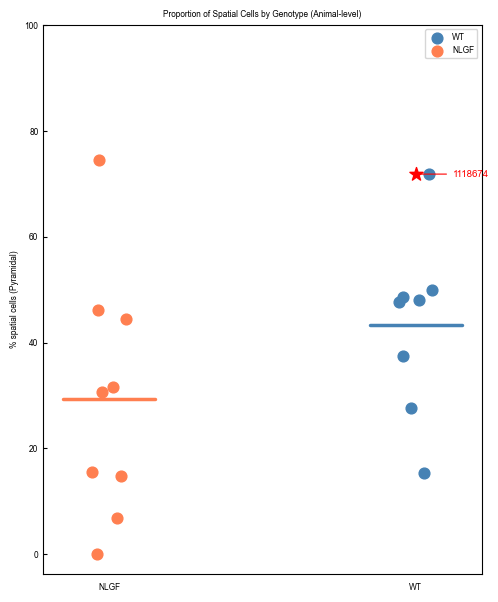

In [21]:
"""
Next steps:
1. Fit a binomial GLMM to test for differences in the proportion of spatial cells by genotype, controlling for cell type and mouse as a random effect.
2. Visualize the results (e.g., bar plot with error bars showing the proportion of spatial cells by genotype and cell type).        
"""

import matplotlib.pyplot as plt
import numpy as np

animal_pyr = animal_summary[['mouse_name', 'Genotype', 'pct_spatial']].copy()
animal_pyr['mouse_name'] = animal_pyr['mouse_name'].astype(str)
fig, ax = plt.subplots(figsize=(5, 6))

colors = {'WT': 'steelblue', 'NLGF': 'coral'}
np.random.seed(42)

for geno in ['WT', 'NLGF']:
    sub = animal_pyr[animal_pyr['Genotype'] == geno]
    x = np.where(geno == 'WT', 1, 0)
    jitter = np.random.uniform(-0.06, 0.06, len(sub))
    ax.scatter([x + j for j in jitter], sub['pct_spatial'],
               color=colors[geno], s=60, zorder=3, label=geno)
    ax.plot([x - 0.15, x + 0.15],
            [sub['pct_spatial'].mean()] * 2,
            color=colors[geno], lw=2.5, zorder=4)

# Detect and label outliers (IQR method, per genotype)
for geno in ['WT', 'NLGF']:
    sub = animal_pyr[animal_pyr['Genotype'] == geno]
    x_pos = 1 if geno == 'WT' else 0
    q1, q3 = sub['pct_spatial'].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = sub[
        (sub['pct_spatial'] < q1 - 1.5 * iqr) |
        (sub['pct_spatial'] > q3 + 1.5 * iqr)
    ]
    for _, row in outliers.iterrows():
        ax.scatter(x_pos, row['pct_spatial'],
                   color='red', s=100, zorder=6, marker='*')
        ax.annotate(
            row['mouse_name'],
            xy=(x_pos, row['pct_spatial']),
            xytext=(x_pos + 0.12, row['pct_spatial']),
            fontsize=7, color='red', va='center',
            arrowprops=dict(arrowstyle='-', color='red', lw=0.8)
        )

ax.set_xticks([0, 1])
ax.set_xticklabels(['NLGF', 'WT'])
ax.set_ylabel('% spatial cells (Pyramidal)')
ax.set_title('Proportion of Spatial Cells by Genotype (Animal-level)')
ax.set_yticks(range(0, 101, 20))
ax.legend()
plt.tight_layout()
plt.show()

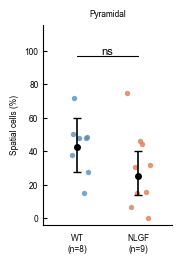

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/glmm_spatial_proportion_Pyramidal_single_column.pdf


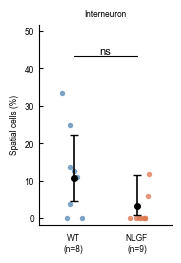

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/glmm_spatial_proportion_Interneuron_single_column.pdf


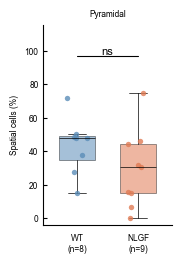

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/box_spatial_proportion_Pyramidal_single_column.pdf


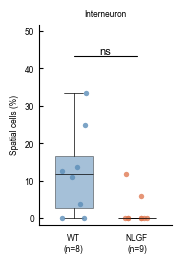

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/box_spatial_proportion_Interneuron_single_column.pdf


In [22]:
"""
Finally, we can visualize the animal-level proportions of spatial cells by genotype and cell type,
with significance from the GLMM results indicated on the plot.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _pstars(p):
    if pd.isna(p): return ""
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "ns"

# ── Build animal-level proportion table ───────────────────────────────────────
animal_pct = (
    df_linear_track
    .groupby(["mouse_name", "Genotype", "cell_type"])
    .agg(pct_spatial=("is_spatial", "mean"))
    .reset_index()
)
animal_pct["pct_spatial_100"] = animal_pct["pct_spatial"] * 100

cts_plot = [
    ct for ct in ["Pyramidal", "Interneuron"]
    if ct in animal_pct["cell_type"].values
]

rng_spat = np.random.default_rng(101)

def _glmm_stars(cell_type):
    fe = results.get(cell_type, {}).get("fixed_effects", None)
    if fe is None:
        return "", np.nan
    nlgf_row = fe[fe.index.str.contains("NLGF")]
    if nlgf_row.empty:
        return "", np.nan
    p_val = nlgf_row["p_value"].values[0]
    return _pstars(p_val), p_val

# ─── Plots ────────────────────────────────────────────────────────────────────
for plot_type in ("glmm", "box"):
    for ct in cts_plot:

        fig, ax = plt.subplots(figsize=(1.65, 2.6))

        sub      = animal_pct[animal_pct["cell_type"] == ct]
        genos_ct = [g for g in GENO_ORDER if g in sub["Genotype"].values]
        vals     = {
            g: sub.loc[sub["Genotype"] == g, "pct_spatial_100"].values
            for g in genos_ct
        }

        # ── Individual data + GLMM predicted probability ± 95% CI ────────────
        if plot_type == "glmm":
            emm = results.get(ct, {}).get("emm", None)
            for xi, g in enumerate(genos_ct):
                if emm is None or g not in emm.index:
                    continue
                prob  = emm.loc[g, "prob"] * 100
                ci_lo = emm.loc[g, "ci_low"] * 100
                ci_hi = emm.loc[g, "ci_high"] * 100
                ax.errorbar(
                    xi, prob,
                    yerr=[[prob - ci_lo], [ci_hi - prob]],
                    fmt="o", color="black", markersize=4,
                    elinewidth=1.2, capsize=3, zorder=7,
                ) 

        # ── Box ──────────────────────────────────────────────────────────────
        else:
            for xi, g in enumerate(genos_ct):
                bp_parts = ax.boxplot(
                    vals[g], positions=[xi], widths=0.6,
                    patch_artist=True, manage_ticks=False,
                    showfliers=False,
                    boxprops=dict(facecolor=GENO_COLORS.get(g, "#aaaaaa"),
                                  alpha=0.55, linewidth=0.5),
                    medianprops=dict(color="black", linewidth=0.5),
                    whiskerprops=dict(linewidth=0.5),
                    capprops=dict(linewidth=0.5),
                )
                bp_parts["medians"][0].set_zorder(8)

        # ── Individual animal dots ────────────────────────────────────────────
        for xi, g in enumerate(genos_ct):
            jitter = rng_spat.uniform(-0.20, 0.20, size=len(vals[g]))
            ax.scatter(
                xi + jitter, vals[g],
                color=GENO_COLORS.get(g, "#aaaaaa"),
                s=15, alpha=0.8,
                zorder=5 if plot_type == "glmm" else 4,
                linewidths=0,
            )

        # ── GLMM significance bracket ─────────────────────────────────────────
        if len(genos_ct) >= 2:
            stars, p_val = _glmm_stars(ct)
            if stars:
                all_v   = np.concatenate(list(vals.values()))
                y_top   = np.nanmax(all_v)
                y_range = np.nanmax(all_v) - np.nanmin(all_v) or 1.0
                bar_y   = y_top + 0.30 * y_range
                tip_y   = bar_y - 0.0  * y_range
                y_lo, y_hi = ax.get_ylim()
                ax.set_ylim(y_lo, max(y_hi, bar_y + 0.25 * y_range))
                x0, x1 = 0, len(genos_ct) - 1
                ax.plot([x0, x0, x1, x1], [tip_y, bar_y, bar_y, tip_y],
                        color="black", linewidth=0.8, zorder=10)
                ax.text((x0 + x1) / 2, bar_y, stars,
                        ha="center", va="bottom", fontsize=8,
                        fontweight="normal", color="black", zorder=10)

        # ── Axis styling ──────────────────────────────────────────────────────
        ax.set_xticks(list(range(len(genos_ct))))
        ax.set_xticklabels([f"{g}\n(n={len(vals[g])})" for g in genos_ct])
        ax.set_xlim(-0.55, len(genos_ct) - 0.45)
        ax.set_ylabel("Spatial cells (%)")
        ax.set_title(ct)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="x", width=0.8, length=3)
        ax.tick_params(axis="y", width=0.8, length=3, direction="in")

        plt.tight_layout(pad=0.2, rect=[0, 0, 1, 0.95])

        fname = f"{plot_type}_spatial_proportion_{ct.replace(' ', '_')}_single_column.pdf"
        out_path = os.path.join(linear_track_OUTDIR, fname)
        fig.savefig(out_path)
        plt.show()
        plt.close(fig)
        print(f"Saved: {out_path}")

## Permutation test using mean proportion

Pyramidal: WT=0.433, NLGF=0.294, diff=-0.139, p=0.1803 ns
Interneuron: WT=0.124, NLGF=0.020, diff=-0.105, p=0.0208 *


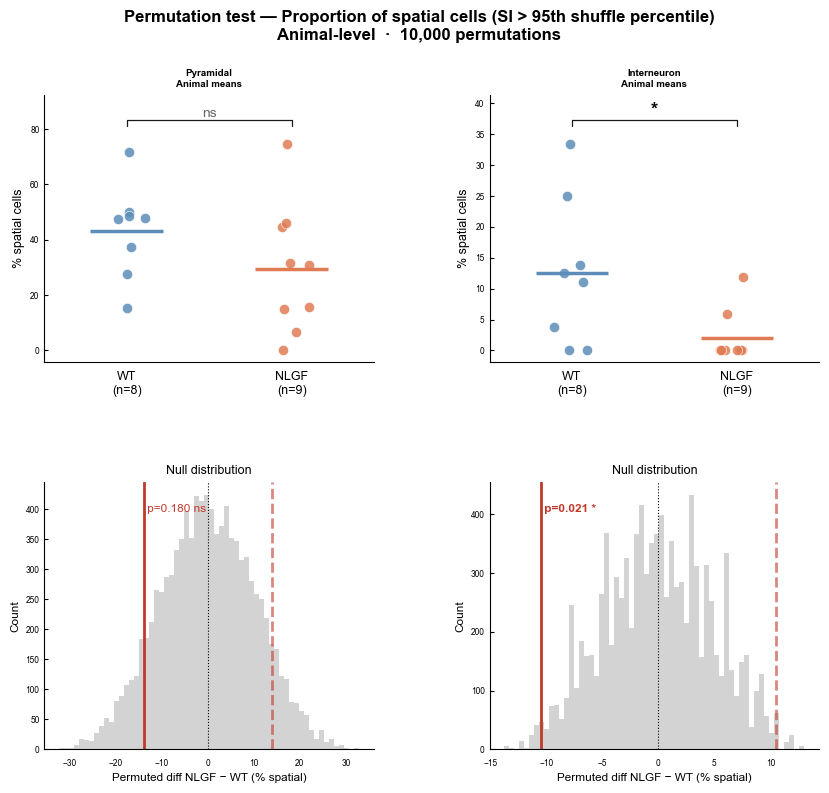

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/perm_test_spatial_proportion.pdf


In [23]:
"""
Permutation test: proportion of spatial cells (WT vs NLGF), animal level using mean proportion per mouse, one test per cell type. 
This is a non-parametric alternative to the GLMM, which is more robust to outliers and small sample sizes. 
It also gives a nice visualisation of the null distribution of differences under the null hypothesis of no genotype effect.
"""
import matplotlib.gridspec as gridspec

def permutation_test_proportion(df, cell_type, n_permutations=10000):
    sub = df[df['cell_type'] == cell_type].copy()
    
    animal_data = sub.groupby('mouse_name').agg(
        genotype=('Genotype', 'first'),
        pct_spatial=('is_spatial', 'mean')
    ).reset_index()
    
    nlgf_mean = animal_data[animal_data['genotype']=='NLGF']['pct_spatial'].mean()
    wt_mean   = animal_data[animal_data['genotype']=='WT']['pct_spatial'].mean()
    observed  = nlgf_mean - wt_mean
    
    null_dist = []
    genotypes = animal_data['genotype'].values.copy()
    
    for _ in range(n_permutations):
        shuffled = np.random.permutation(genotypes)
        animal_data['shuffled'] = shuffled
        nlgf_p = animal_data[animal_data['shuffled']=='NLGF']['pct_spatial'].mean()
        wt_p   = animal_data[animal_data['shuffled']=='WT']['pct_spatial'].mean()
        null_dist.append(nlgf_p - wt_p)
    
    null_dist = np.array(null_dist)
    p_value = np.mean(np.abs(null_dist) >= np.abs(observed))
    
    return {
        'cell_type':     cell_type,
        'mean_WT':       wt_mean,
        'mean_NLGF':     nlgf_mean,
        'observed_diff': observed,
        'null_dist':     null_dist,
        'p_value':       p_value,
        'animal_data':   animal_data,
        'n_WT_mice':     int((animal_data['genotype'] == 'WT').sum()),
        'n_NLGF_mice':   int((animal_data['genotype'] == 'NLGF').sum()),
    }

cts_to_test = [ct for ct in ['Pyramidal', 'Interneuron'] if ct in df_linear_track['cell_type'].values]
prop_results = {}

for ct in cts_to_test:
    res = permutation_test_proportion(df_linear_track, ct)
    prop_results[ct] = res
    print(f"{ct}: WT={res['mean_WT']:.3f}, NLGF={res['mean_NLGF']:.3f}, "
          f"diff={res['observed_diff']:.3f}, p={res['p_value']:.4f} {_pstars(res['p_value'])}")

# ── Plot: one column per cell type ───────────────────────────────────────────
n_cols = len(cts_to_test)
fig = plt.figure(figsize=(5.0 * n_cols, 8.5))
gs  = gridspec.GridSpec(2, n_cols, figure=fig, hspace=0.45, wspace=0.35)
rng_plot = np.random.default_rng(99)

for col_i, ct in enumerate(cts_to_test):
    r       = prop_results[ct]
    obs     = r['observed_diff']
    pval    = r['p_value']
    stars   = _pstars(pval)
    ad      = r['animal_data']

    # ── Top: animal-level dot plot ────────────────────────────────────────
    ax_dot = fig.add_subplot(gs[0, col_i])

    for xi, geno in enumerate(["WT", "NLGF"]):
        gd = ad[ad['genotype'] == geno]['pct_spatial'].values
        jitter = rng_plot.uniform(-0.12, 0.12, size=len(gd))
        ax_dot.scatter(
            xi + jitter, gd * 100,
            color=GENO_COLORS.get(geno, "#aaaaaa"),
            s=55, zorder=4, alpha=0.85, edgecolors="white", linewidths=0.5,
        )
        ax_dot.hlines(
            gd.mean() * 100, xi - 0.22, xi + 0.22,
            colors=GENO_COLORS.get(geno, "#aaaaaa"),
            linewidth=2.5, zorder=5,
        )

    # Significance bracket
    all_pct = ad['pct_spatial'].values * 100
    y_top   = np.nanmax(all_pct)
    y_range = np.nanmax(all_pct) - np.nanmin(all_pct) or 1.0
    bar_y   = y_top + 0.12 * y_range
    tip_y   = bar_y - 0.03 * y_range
    ax_dot.plot([0, 0, 1, 1], [tip_y, bar_y, bar_y, tip_y], "k-", linewidth=0.9)
    ax_dot.text(0.5, bar_y, stars,
                ha="center", va="bottom",
                fontsize=13 if pval < 0.05 else 10,
                fontweight="bold" if pval < 0.05 else "normal",
                color="black" if pval < 0.05 else "#666666")
    y_lo, y_hi = ax_dot.get_ylim()
    ax_dot.set_ylim(y_lo, max(y_hi, bar_y + 0.12 * y_range))

    ax_dot.set_xticks([0, 1])
    ax_dot.set_xticklabels(
        [f"WT\n(n={r['n_WT_mice']})", f"NLGF\n(n={r['n_NLGF_mice']})"], fontsize=9
    )
    ax_dot.set_xlim(-0.5, 1.5)
    ax_dot.set_ylabel("% spatial cells", fontsize=9)
    set_panel_title(ax_dot, f"{ct}\nAnimal means")
    ax_dot.spines[["top", "right"]].set_visible(False)

    # ── Bottom: null distribution histogram ───────────────────────────────
    ax_null = fig.add_subplot(gs[1, col_i])

    ax_null.hist(r['null_dist'] * 100, bins=60, color="#cccccc", edgecolor="none", alpha=0.85)
    ax_null.axvline(obs * 100,  color="#C0392B", linewidth=2.0)
    ax_null.axvline(-obs * 100, color="#C0392B", linewidth=2.0, linestyle="--", alpha=0.6)
    ax_null.axvline(0,          color="black",   linewidth=0.8, linestyle=":")

    y_max = ax_null.get_ylim()[1]
    ax_null.text(
        obs * 100, y_max * 0.92,
        f" p={pval:.3f} {stars}",
        color="#C0392B", fontsize=8.5, va="top",
        fontweight="bold" if pval < 0.05 else "normal",
    )
    ax_null.set_xlabel("Permuted diff NLGF − WT (% spatial)", fontsize=8.5)
    ax_null.set_ylabel("Count", fontsize=8.5)
    ax_null.set_title("Null distribution", fontsize=9)
    ax_null.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Permutation test — Proportion of spatial cells (SI > 95th shuffle percentile)\n"
    f"Animal-level  ·  10,000 permutations",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
out_path = os.path.join(linear_track_OUTDIR, "perm_test_spatial_proportion.pdf")
plt.savefig(out_path, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved: {out_path}")

## Permutation test using MEDIAN instead of mean

Pyramidal: WT median=0.478, NLGF median=0.308, diff=-0.170, p=0.2130 ns
Interneuron: WT median=0.118, NLGF median=0.000, diff=-0.118, p=0.0381 *


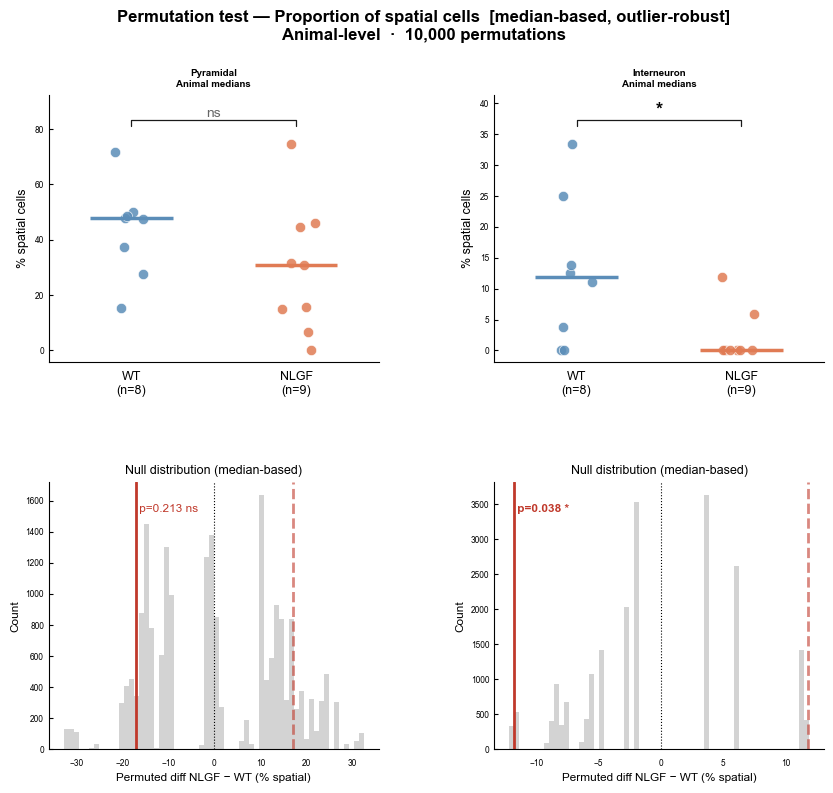

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/perm_test_spatial_proportion_robust.pdf


In [24]:
"""
Robust version of the permutation test using MEDIAN instead of mean, to reduce the influence of outliers (e.g. mouse 1117201 with 90% spatial cells).
"""
import matplotlib.gridspec as gridspec

def permutation_test_robust(df, cell_type, n_permutations=20000):
    sub = df[df['cell_type'] == cell_type].copy()
    
    animal_data = sub.groupby('mouse_name').agg(
        genotype=('Genotype', 'first'),
        pct_spatial=('is_spatial', 'mean')
    ).reset_index()
    
    nlgf_med = animal_data[animal_data['genotype']=='NLGF']['pct_spatial'].median()
    wt_med   = animal_data[animal_data['genotype']=='WT']['pct_spatial'].median()
    observed = nlgf_med - wt_med
    
    null_dist = []
    genotypes = animal_data['genotype'].values.copy()
    
    for _ in range(n_permutations):
        shuffled = np.random.permutation(genotypes)
        animal_data['shuffled'] = shuffled
        null_dist.append(
            animal_data[animal_data['shuffled']=='NLGF']['pct_spatial'].median() -
            animal_data[animal_data['shuffled']=='WT']['pct_spatial'].median()
        )
    
    null_dist = np.array(null_dist)
    p_value = np.mean(np.abs(null_dist) >= np.abs(observed))
    
    return {
        'observed_diff': observed,
        'p_value':       p_value,
        'null_dist':     null_dist,
        'median_WT':     wt_med,
        'median_NLGF':   nlgf_med,
        'animal_data':   animal_data,
    }

cts_to_test = [ct for ct in ['Pyramidal', 'Interneuron'] if ct in df_linear_track['cell_type'].values]
robust_results = {}

for ct in cts_to_test:
    res = permutation_test_robust(df_linear_track, ct)
    robust_results[ct] = res
    print(f"{ct}: WT median={res['median_WT']:.3f}, NLGF median={res['median_NLGF']:.3f}, "
          f"diff={res['observed_diff']:.3f}, p={res['p_value']:.4f} {_pstars(res['p_value'])}")

# ── Plot ──────────────────────────────────────────────────────────────────────
n_cols   = len(cts_to_test)
fig      = plt.figure(figsize=(5.0 * n_cols, 8.5))
gs       = gridspec.GridSpec(2, n_cols, figure=fig, hspace=0.45, wspace=0.35)
rng_rob  = np.random.default_rng(77)

for col_i, ct in enumerate(cts_to_test):
    r     = robust_results[ct]
    obs   = r['observed_diff']
    pval  = r['p_value']
    stars = _pstars(pval)
    ad    = r['animal_data']

    # ── Top: animal-level dot plot with median bar ────────────────────────
    ax_dot = fig.add_subplot(gs[0, col_i])

    for xi, geno in enumerate(["WT", "NLGF"]):
        gd      = ad[ad['genotype'] == geno]['pct_spatial'].values
        jitter  = rng_rob.uniform(-0.12, 0.12, size=len(gd))
        ax_dot.scatter(
            xi + jitter, gd * 100,
            color=GENO_COLORS.get(geno, "#aaaaaa"),
            s=55, zorder=4, alpha=0.85, edgecolors="white", linewidths=0.5,
        )
        # Median bar (filled, slightly wider than mean bar to signal it's median)
        ax_dot.hlines(
            np.median(gd) * 100, xi - 0.25, xi + 0.25,
            colors=GENO_COLORS.get(geno, "#aaaaaa"),
            linewidth=2.5, zorder=5,
        )

    # Significance bracket
    all_pct = ad['pct_spatial'].values * 100
    y_top   = np.nanmax(all_pct)
    y_range = np.nanmax(all_pct) - np.nanmin(all_pct) or 1.0
    bar_y   = y_top + 0.12 * y_range
    tip_y   = bar_y - 0.03 * y_range
    ax_dot.plot([0, 0, 1, 1], [tip_y, bar_y, bar_y, tip_y], "k-", linewidth=0.9)
    ax_dot.text(0.5, bar_y, stars,
                ha="center", va="bottom",
                fontsize=13 if pval < 0.05 else 10,
                fontweight="bold" if pval < 0.05 else "normal",
                color="black" if pval < 0.05 else "#666666")
    y_lo, y_hi = ax_dot.get_ylim()
    ax_dot.set_ylim(y_lo, max(y_hi, bar_y + 0.12 * y_range))

    n_wt   = int((ad['genotype'] == 'WT').sum())
    n_nlgf = int((ad['genotype'] == 'NLGF').sum())
    ax_dot.set_xticks([0, 1])
    ax_dot.set_xticklabels([f"WT\n(n={n_wt})", f"NLGF\n(n={n_nlgf})"], fontsize=9)
    ax_dot.set_xlim(-0.5, 1.5)
    ax_dot.set_ylabel("% spatial cells", fontsize=9)
    set_panel_title(ax_dot, f"{ct}\nAnimal medians")
    ax_dot.spines[["top", "right"]].set_visible(False)

    # ── Bottom: null distribution histogram ───────────────────────────────
    ax_null = fig.add_subplot(gs[1, col_i])

    ax_null.hist(r['null_dist'] * 100, bins=60, color="#cccccc", edgecolor="none", alpha=0.85)
    ax_null.axvline(obs * 100,  color="#C0392B", linewidth=2.0)
    ax_null.axvline(-obs * 100, color="#C0392B", linewidth=2.0, linestyle="--", alpha=0.6)
    ax_null.axvline(0,          color="black",   linewidth=0.8, linestyle=":")

    y_max = ax_null.get_ylim()[1]
    ax_null.text(
        obs * 100, y_max * 0.92,
        f" p={pval:.3f} {stars}",
        color="#C0392B", fontsize=8.5, va="top",
        fontweight="bold" if pval < 0.05 else "normal",
    )
    ax_null.set_xlabel("Permuted diff NLGF − WT (% spatial)", fontsize=8.5)
    ax_null.set_ylabel("Count", fontsize=8.5)
    ax_null.set_title("Null distribution (median-based)", fontsize=9)
    ax_null.spines[["top", "right"]].set_visible(False)
    sns.set_theme(style="white")
    apply_style()

fig.suptitle(
    "Permutation test — Proportion of spatial cells  [median-based, outlier-robust]\n"
    "Animal-level  ·  10,000 permutations",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
out_path = os.path.join(linear_track_OUTDIR, "perm_test_spatial_proportion_robust.pdf")
plt.savefig(out_path, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved: {out_path}")

## Spatial information deciles by genotype (bin ranges, mean, median & SEM)

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/spatial_info_by_Genotype_deciles.csv
Spatial information deciles by genotype


,Genotype,decile,spatial_info,spatial_info_bin_low,spatial_info_bin_high,n_cells,spatial_info_mean,spatial_info_median,spatial_info_sem
0,NLGF,0.0,0.004288,0.00329,0.0378,37,0.022399,0.024437,0.001586
1,NLGF,0.1,0.037816,0.03780,0.0810,37,0.058709,0.054546,0.002277
2,NLGF,0.2,0.080997,0.08100,0.1290,36,0.101052,0.097797,0.002467
3,NLGF,0.3,0.128729,0.12900,0.1740,37,0.150542,0.148735,0.002334
4,NLGF,0.4,0.173513,0.17400,0.2420,37,0.205544,0.207434,0.003351
5,NLGF,0.5,0.242091,0.24200,0.3130,36,0.284567,0.285378,0.002805
6,NLGF,0.6,0.312514,0.31300,0.4190,37,0.361360,0.356078,0.005282
7,NLGF,0.7,0.419200,0.41900,0.5960,36,0.492156,0.486874,0.007351
8,NLGF,0.8,0.596098,0.59600,0.8660,37,0.707443,0.704538,0.013082
9,NLGF,0.9,0.865834,0.86600,2.5110,37,1.359695,1.339393,0.059233


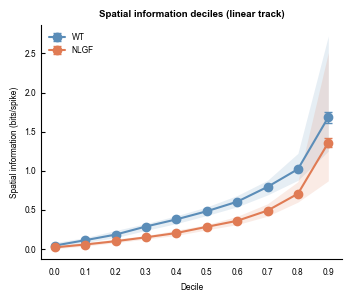

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/spatial_info_by_Genotype_deciles_min_max.pdf


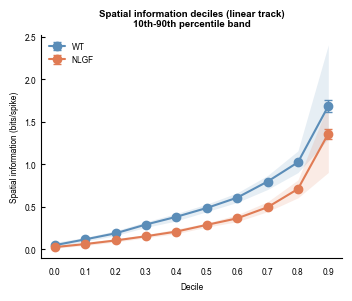

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/spatial_info_by_Genotype_deciles_p10_p90.pdf


In [25]:
"""
Spatial information deciles by genotype (linear track, pooled cell types).
Within each genotype, drop NaNs in spatial_info, compute decile edges
(0th-90th percentile, step 10, plus max as the top edge) with
pandas.Series.quantile, and bin cells with a single pd.cut call. That one
grouping is reused for the CSV (boundary value, bin range, n_cells, mean,
median, SEM) and for both plots below (mean +/- SEM, shaded with either the
min-max range or the within-bin 10th-90th percentile range) — no duplicate
quantile/pd.cut calls.
"""

deciles = [round(i / 10, 1) for i in range(10)]
si_decile_rows = []
si_bin_stats_by_geno = {}
for geno, grp in df_linear_track.groupby('Genotype'):
    si = grp['spatial_info'].dropna()
    edges = [si.quantile(d) for d in deciles] + [si.max()]
    bins = pd.cut(si, bins=edges, include_lowest=True, right=True)
    bin_edges = bins.cat.categories

    stats = si.groupby(bins, observed=False).agg(
        mean='mean', sem='sem', min='min', max='max', median='median', count='count',
        p10=lambda x: x.quantile(0.1), p90=lambda x: x.quantile(0.9),
    )
    stats.index = deciles
    si_bin_stats_by_geno[geno] = stats

    for d, boundary, bin_iv in zip(deciles, edges, bin_edges):
        row = stats.loc[d]
        si_decile_rows.append({
            'Genotype': geno,
            'decile': d,
            'spatial_info': boundary,
            'spatial_info_bin_low': bin_iv.left,
            'spatial_info_bin_high': bin_iv.right,
            'n_cells': int(row['count']),
            'spatial_info_mean': row['mean'],
            'spatial_info_median': row['median'],
            'spatial_info_sem': row['sem'],
        })

spatial_info_deciles = pd.DataFrame(si_decile_rows)

decile_csv_path = os.path.join(linear_track_OUTDIR, "spatial_info_by_Genotype_deciles.csv")
spatial_info_deciles.to_csv(decile_csv_path, index=False)
print(f"Saved: {decile_csv_path}")
display_df("Spatial information deciles by genotype", spatial_info_deciles)

# ── Plot (per-bin mean +/- SEM, min-max shading) ────────────────────────────
fig, ax = plt.subplots(figsize=(3.5, 3))
for geno in GENO_ORDER:
    stats = si_bin_stats_by_geno[geno]
    ax.fill_between(deciles, stats['min'], stats['max'],
                     color=GENO_COLORS[geno], alpha=0.15, linewidth=0)
    ax.errorbar(deciles, stats['mean'], yerr=stats['sem'], marker='o', label=geno,
                color=GENO_COLORS[geno], capsize=3, elinewidth=1, linewidth=1.5)

ax.set_xticks(deciles)
ax.set_xlabel("Decile")
ax.set_ylabel("Spatial information (bits/spike)")
set_panel_title(ax, "Spatial information deciles (linear track)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

decile_pdf_path = os.path.join(linear_track_OUTDIR, "spatial_info_by_Genotype_deciles_min_max.pdf")
fig.savefig(decile_pdf_path, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved: {decile_pdf_path}")

# ── Plot (per-bin mean +/- SEM, 10th-90th percentile shading) ──────────────
fig, ax = plt.subplots(figsize=(3.5, 3))
for geno in GENO_ORDER:
    stats = si_bin_stats_by_geno[geno]
    ax.fill_between(deciles, stats['p10'], stats['p90'],
                     color=GENO_COLORS[geno], alpha=0.15, linewidth=0)
    ax.errorbar(deciles, stats['mean'], yerr=stats['sem'], marker='o', label=geno,
                color=GENO_COLORS[geno], capsize=3, elinewidth=1, linewidth=1.5)

ax.set_xticks(deciles)
ax.set_xlabel("Decile")
ax.set_ylabel("Spatial information (bits/spike)")
set_panel_title(ax, "Spatial information deciles (linear track)\n10th-90th percentile band")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

decile_p10_p90_pdf_path = os.path.join(linear_track_OUTDIR, "spatial_info_by_Genotype_deciles_p10_p90.pdf")
fig.savefig(decile_p10_p90_pdf_path, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved: {decile_p10_p90_pdf_path}")


# Spatial sparsity and coherence deciles analysis and plotting 

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/coherence_by_Genotype_deciles.csv
Spatial coherence deciles by genotype


,Genotype,decile,coherence,coherence_bin_low,coherence_bin_high,n_cells,coherence_mean,coherence_median,coherence_sem
0,NLGF,0.0,-0.449781,-0.4510,-0.0989,37,-0.208186,-0.175966,0.014810
1,NLGF,0.1,-0.098922,-0.0989,-0.0323,37,-0.067129,-0.067896,0.003608
2,NLGF,0.2,-0.032322,-0.0323,0.0251,36,0.000624,0.002544,0.003145
3,NLGF,0.3,0.025097,0.0251,0.1060,37,0.064204,0.070782,0.004159
4,NLGF,0.4,0.106419,0.1060,0.2190,37,0.159047,0.159227,0.005140
5,NLGF,0.5,0.219390,0.2190,0.3300,36,0.287749,0.296171,0.004894
6,NLGF,0.6,0.330054,0.3300,0.4210,37,0.377991,0.380199,0.004580
7,NLGF,0.7,0.421030,0.4210,0.5000,36,0.457291,0.456667,0.003712
8,NLGF,0.8,0.499545,0.5000,0.5960,37,0.536487,0.535721,0.004431
9,NLGF,0.9,0.596446,0.5960,0.8310,37,0.666872,0.657961,0.008817


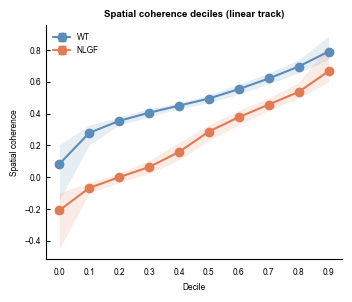

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/coherence_by_Genotype_deciles_min_max.pdf


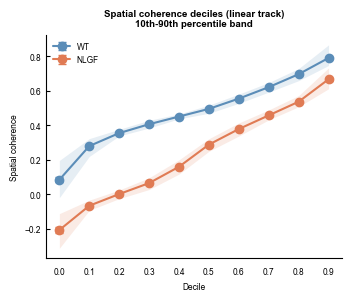

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/coherence_by_Genotype_deciles_p10_p90.pdf
Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/spatial_sparsity_by_Genotype_deciles.csv
Spatial sparsity deciles by genotype


,Genotype,decile,spatial_sparsity,spatial_sparsity_bin_low,spatial_sparsity_bin_high,n_cells,spatial_sparsity_mean,spatial_sparsity_median,spatial_sparsity_sem
0,NLGF,0.0,0.151364,0.150,0.567,37,0.412081,0.418792,0.016542
1,NLGF,0.1,0.566955,0.567,0.727,37,0.663161,0.666441,0.007194
2,NLGF,0.2,0.727052,0.727,0.818,36,0.778374,0.782032,0.004218
3,NLGF,0.3,0.817583,0.818,0.863,37,0.840008,0.842131,0.002262
4,NLGF,0.4,0.863259,0.863,0.908,37,0.882762,0.880949,0.002130
5,NLGF,0.5,0.908467,0.908,0.935,36,0.922015,0.922036,0.001367
6,NLGF,0.6,0.935373,0.935,0.956,37,0.945724,0.945653,0.001087
7,NLGF,0.7,0.956264,0.956,0.971,36,0.963292,0.962088,0.000717
8,NLGF,0.8,0.970588,0.971,0.984,37,0.977726,0.978283,0.000699
9,NLGF,0.9,0.983546,0.984,0.998,37,0.988995,0.988633,0.000620


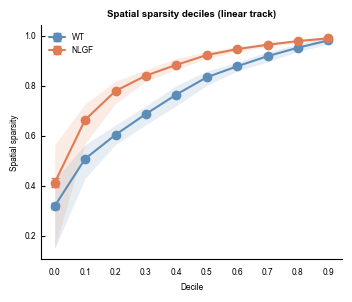

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/spatial_sparsity_by_Genotype_deciles_min_max.pdf


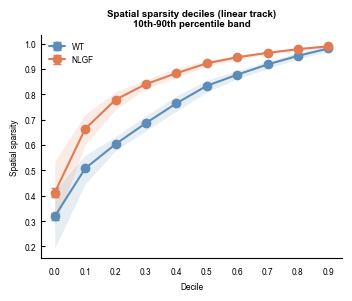

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/spatial_sparsity_by_Genotype_deciles_p10_p90.pdf


In [26]:
"""
Spatial sparsity and coherence deciles by genotype (linear track, pooled cell types).
Within each genotype, drop NaNs in the metric, compute decile edges
(0th-90th percentile, step 10, plus max as the top edge) with
pandas.Series.quantile, and bin cells with a single pd.cut call. That one
grouping is reused for the CSV (boundary value, bin range, n_cells, mean,
median, SEM) and for both plots below (mean +/- SEM, shaded with either the
min-max range or the within-bin 10th-90th percentile range) — no duplicate
quantile/pd.cut calls.
"""

deciles = [round(i / 10, 1) for i in range(10)]
DECILE_METRICS = ['coherence', 'spatial_sparsity']
METRIC_AXIS_LABELS = {
    'coherence': 'Spatial coherence',
    'spatial_sparsity': 'Spatial sparsity',
}

for metric in DECILE_METRICS:
    decile_rows = []
    metric_bin_stats_by_geno = {}
    for geno, grp in df_linear_track.groupby('Genotype'):
        vals = grp[metric].dropna()
        edges = [vals.quantile(d) for d in deciles] + [vals.max()]
        bins = pd.cut(vals, bins=edges, include_lowest=True, right=True)
        bin_edges = bins.cat.categories

        stats = vals.groupby(bins, observed=False).agg(
            mean='mean', sem='sem', min='min', max='max', median='median', count='count',
            p10=lambda x: x.quantile(0.1), p90=lambda x: x.quantile(0.9),
        )
        stats.index = deciles
        metric_bin_stats_by_geno[geno] = stats

        for d, boundary, bin_iv in zip(deciles, edges, bin_edges):
            row = stats.loc[d]
            decile_rows.append({
                'Genotype': geno,
                'decile': d,
                metric: boundary,
                f'{metric}_bin_low': bin_iv.left,
                f'{metric}_bin_high': bin_iv.right,
                'n_cells': int(row['count']),
                f'{metric}_mean': row['mean'],
                f'{metric}_median': row['median'],
                f'{metric}_sem': row['sem'],
            })

    metric_deciles = pd.DataFrame(decile_rows)

    decile_csv_path = os.path.join(linear_track_OUTDIR, f"{metric}_by_Genotype_deciles.csv")
    metric_deciles.to_csv(decile_csv_path, index=False)
    print(f"Saved: {decile_csv_path}")
    display_df(f"{METRIC_AXIS_LABELS[metric]} deciles by genotype", metric_deciles)

    # ── Plot (per-bin mean +/- SEM, min-max shading) ────────────────────────
    fig, ax = plt.subplots(figsize=(3.5, 3))
    for geno in GENO_ORDER:
        stats = metric_bin_stats_by_geno[geno]
        ax.fill_between(deciles, stats['min'], stats['max'],
                         color=GENO_COLORS[geno], alpha=0.15, linewidth=0)
        ax.errorbar(deciles, stats['mean'], yerr=stats['sem'], marker='o', label=geno,
                    color=GENO_COLORS[geno], capsize=3, elinewidth=1, linewidth=1.5)

    ax.set_xticks(deciles)
    ax.set_xlabel("Decile")
    ax.set_ylabel(METRIC_AXIS_LABELS[metric])
    set_panel_title(ax, f"{METRIC_AXIS_LABELS[metric]} deciles (linear track)")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()

    decile_pdf_path = os.path.join(linear_track_OUTDIR, f"{metric}_by_Genotype_deciles_min_max.pdf")
    fig.savefig(decile_pdf_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {decile_pdf_path}")

    # ── Plot (per-bin mean +/- SEM, 10th-90th percentile shading) ──────────
    fig, ax = plt.subplots(figsize=(3.5, 3))
    for geno in GENO_ORDER:
        stats = metric_bin_stats_by_geno[geno]
        ax.fill_between(deciles, stats['p10'], stats['p90'],
                         color=GENO_COLORS[geno], alpha=0.15, linewidth=0)
        ax.errorbar(deciles, stats['mean'], yerr=stats['sem'], marker='o', label=geno,
                    color=GENO_COLORS[geno], capsize=3, elinewidth=1, linewidth=1.5)

    ax.set_xticks(deciles)
    ax.set_xlabel("Decile")
    ax.set_ylabel(METRIC_AXIS_LABELS[metric])
    set_panel_title(ax, f"{METRIC_AXIS_LABELS[metric]} deciles (linear track)\n10th-90th percentile band")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()

    decile_p10_p90_pdf_path = os.path.join(linear_track_OUTDIR, f"{metric}_by_Genotype_deciles_p10_p90.pdf")
    fig.savefig(decile_p10_p90_pdf_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {decile_p10_p90_pdf_path}")


# Spatial information Left/Right Analysis 

In [27]:
#TODO: ASK ROBIN TO CALCULATE THE SPTAIL INFORMATION FOR EAST AND WEST BOUND PLACE CELLS 


In [28]:
"""
Classifying cells as spatial vs non-spatial based on the 95th percentile threshold from the shuffle distribution
"""

print(f"Applying spatial info threshold: {threshold_95:.4f}")

df_linear_track['is_spatial'] = df_linear_track['spatial_info'] > threshold_95
df_linear_track['is_spatial'] = df_linear_track['is_spatial'].astype(int)  # Convert boolean to int (1 for spatial, 0 for non-spatial)
print(df_linear_track[['spatial_info', 'is_spatial']].head())

append_path = os.path.join(linear_track_OUTDIR, "linear_track_with_spatial_flag.csv")
df_linear_track.to_csv(append_path, index=False)
print("\nDataframe with spatial flag saved to:", append_path)

# Summary by genotype and cell type
summary = df_linear_track.groupby(['Genotype', 'cell_type']).agg(
    n_cells=('is_spatial', 'count'),
    n_spatial=('is_spatial', 'sum'),
    pct_spatial=('is_spatial', 'mean')
).reset_index()

summary['pct_spatial'] = summary['pct_spatial'] * 100
save_path = linear_track_OUTDIR / "spatial_cell_summary.csv"
summary.to_csv(save_path, index=False)
print(summary.to_string(index=False))
print("\nSummary saved to:", save_path)

# ── East vs West breakdown ────────────────────────────────────────────────────
# spatial_info in concatenated_trials.csv is a single pooled value per cell --
# it is NOT computed separately per run direction. concatenated_phase_precession.csv
# is the only file recording which direction(s) each cell ran in (run_direction:
# 'e'/'w'), so it's joined in here to stratify the existing is_spatial flags by
# East-only / West-only / both. For the cells recorded in both directions, the
# same (pooled) spatial_info value is counted in both direction groups below --
# this is a stratification by which direction(s) a cell ran in, not a true
# within-cell East vs West difference in spatial coding.
pp_direction = pd.read_csv(
    '/Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/csv_files/concatenated_phase_precession.csv',
    usecols=['filename', 'channel', 'cluster', 'run_direction']
).replace({'run_direction': {'e': 'East', 'w': 'West'}})

df_by_direction = df_linear_track.merge(
    pp_direction, on=['filename', 'channel', 'cluster'], how='left'
)
n_unmatched = df_by_direction['run_direction'].isna().sum()
n_both = len(df_by_direction) - len(df_linear_track)
print(f"\nCells with no East/West match in the phase-precession file: {n_unmatched}")
print(f"Cells recorded in both directions (counted in both groups below): {n_both}")

summary_by_direction = df_by_direction.dropna(subset=['run_direction']).groupby(
    ['Genotype', 'cell_type', 'run_direction']
).agg(
    n_cells=('is_spatial', 'count'),
    n_spatial=('is_spatial', 'sum'),
    pct_spatial=('is_spatial', 'mean')
).reset_index()

summary_by_direction['pct_spatial'] = summary_by_direction['pct_spatial'] * 100
save_path_direction = linear_track_OUTDIR / "spatial_cell_summary_by_direction.csv"
summary_by_direction.to_csv(save_path_direction, index=False)
print(summary_by_direction.to_string(index=False))
print("\nBy-direction summary saved to:", save_path_direction)

Applying spatial info threshold: 0.5707
   spatial_info  is_spatial
0      0.081061           0
1      0.418782           0
2      0.498397           0
3      0.097655           0
4      0.050080           0

Dataframe with spatial flag saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/linear_track_with_spatial_flag.csv
Genotype   cell_type  n_cells  n_spatial  pct_spatial
    NLGF Interneuron      146          8     5.479452
    NLGF   Pyramidal      221         67    30.316742
      WT Interneuron      101         12    11.881188
      WT   Pyramidal      292        132    45.205479

Summary saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/spatial_cell_summary.csv

Cells with no East/West match in the phase-precession file: 514
Cells recorded in both directions (coun

## Animal level summary 

# Phase locked cells analysis 

## Animal level summary phase locked


Animal-level summary saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/animal_level_locked_summary.csv
    mouse_name Genotype  n_phase_locked  n_total  pct_locked
0       644788     NLGF              18       25   72.000000
1       667893       WT              33       33  100.000000
2       708153     NLGF              35       48   72.916667
3       719648       WT              45       45  100.000000
4       726050       WT              46       52   88.461538
5       726857     NLGF              28       36   77.777778
6       733075     NLGF              50       68   73.529412
7      1116806     NLGF              37       48   77.083333
8      1116808     NLGF              52       65   80.000000
9      1116810     NLGF              23       27   85.185185
10     1117201     NLGF              24       30   80.000000
11     1117425     NLGF              18       20   90.

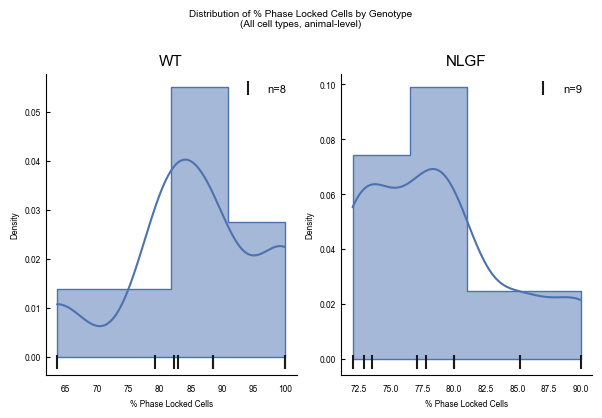

Shapiro-Wilk test for WT: W=0.9237, p=0.4604
  Normally distributed
Shapiro-Wilk test for NLGF: W=0.9242, p=0.4281
  Normally distributed


In [29]:
"""
Animal-level summary is also useful for checking the data 
and for fitting a binomial GLMM to test for differences 
in the proportion of phase locked cells by genotype, 
controlling for cell type and mouse as a random effect.
"""
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro

# Animal-level summary across ALL cell types
animal_summary = df_linear_track.groupby(['mouse_name', 'Genotype']).agg(
    n_phase_locked=('phase_locked', 'sum'),
    n_total=('phase_locked', 'count')
).reset_index()
animal_summary['pct_locked'] = animal_summary['n_phase_locked'] / animal_summary['n_total'] * 100
save_path = linear_track_OUTDIR / "animal_level_locked_summary.csv"
animal_summary.to_csv(save_path, index=False)
print("\nAnimal-level summary saved to:", save_path)
print(animal_summary)

# Check distribution of % phase locked cells per genotype
sns.set_theme(style="white")
apply_style()
genotypes = ['WT', 'NLGF']

fig, axes = plt.subplots(1, len(genotypes), figsize=(6, 4), sharey=False)

for ax, geno in zip(axes, genotypes):
    subset = animal_summary[animal_summary['Genotype'] == geno]['pct_locked'].dropna()

    if len(subset) < 3:
        ax.text(0.5, 0.5, f"n={len(subset)}\n(too few)", transform=ax.transAxes,
                ha='center', va='center', fontsize=9)
    else:
        sns.histplot(
            x=subset,
            kde=True,
            kde_kws={"bw_adjust": 0.6},
            bins=max(4, len(subset) // 2),
            element='step',
            stat='density',
            ax=ax,
        )
        ax.plot(subset, np.zeros_like(subset) - 0.001,
                '|', color='k', markersize=10, markeredgewidth=1.5,
                clip_on=False, label=f"n={len(subset)}")
        ax.legend(fontsize=8, frameon=False)

    ax.set_title(geno, fontsize=11)
    ax.set_xlabel('% Phase Locked Cells')
    ax.set_ylabel('Density')
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle('Distribution of % Phase Locked Cells by Genotype\n(All cell types, animal-level)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(linear_track_OUTDIR, 'pct_locked_distribution_by_genotype.pdf'),
            bbox_inches='tight', transparent=True)
plt.show()

# Shapiro-Wilk normality test
for genotype in genotypes:
    subset = animal_summary[animal_summary['Genotype'] == genotype]['pct_locked'].dropna()
    stat, p = shapiro(subset)
    print(f"Shapiro-Wilk test for {genotype}: W={stat:.4f}, p={p:.4f}")
    print(f"  {'Normally distributed' if p > 0.05 else 'Not normally distributed'}")

In [30]:
# Summary by genotype and cell type
summary = df_linear_track.groupby(['Genotype', 'cell_type']).agg(
    n_cells=('phase_locked', 'count'),
    n_spatial=('phase_locked', 'sum'),
    pct_locked=('phase_locked', 'mean')
).reset_index()

summary['pct_locked'] = summary['pct_locked'] * 100
save_path = linear_track_OUTDIR / "spatial_cell_summary.csv"
summary.to_csv(save_path, index=False)
print(summary.to_string(index=False))
print("\nSummary saved to:", save_path)

Genotype   cell_type  n_cells  n_spatial  pct_locked
    NLGF Interneuron      146        118   80.821918
    NLGF   Pyramidal      221        167   75.565611
      WT Interneuron      101         83   82.178218
      WT   Pyramidal      292        253   86.643836

Summary saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/spatial_cell_summary.csv


## Fit a binomial GLMM test for phase-locked cells

In [31]:
import pandas as pd
import numpy as np
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr

glmmTMB = importr('glmmTMB')
base    = importr('base')

def run_phase_locked_glmm(df, cell_type):
    sub = df[df['cell_type'] == cell_type][['phase_locked', 'Genotype', 'mouse_name']].copy()
    sub = sub.dropna()

    # Convert to R dataframe
    with localconverter(ro.default_converter + pandas2ri.converter):
        r_df = ro.conversion.py2rpy(sub)
    ro.globalenv['r_df'] = r_df

    ro.r('r_df$Genotype   <- relevel(factor(r_df$Genotype), ref = "WT")')
    ro.r('r_df$mouse_name <- factor(r_df$mouse_name)')
    ro.r('r_df$phase_locked <- as.integer(r_df$phase_locked)')

    ro.r('''
        m <- glmmTMB(
            phase_locked ~ Genotype + (1 | mouse_name),
            data   = r_df,
            family = binomial(link = "logit")
        )
    ''')

    ro.r('s  <- summary(m)')
    ro.r('fe <- as.data.frame(coef(s)$cond)')

    with localconverter(ro.default_converter + pandas2ri.converter):
        fe_df = ro.conversion.rpy2py(ro.r('fe'))
    fe_df.columns = ['estimate', 'SE', 'z', 'p_value']

    re_var = ro.r('as.numeric(VarCorr(m)$cond$mouse_name)')[0]
    aic    = ro.r('AIC(m)')[0]

    print(f"\n{'='*60}")
    print(f"Cell type: {cell_type}")
    print(f"N cells: {len(sub)}, N mice: {sub['mouse_name'].nunique()}")
    print(f"AIC: {aic:.2f}")
    print(f"Random effect variance (mouse): {float(re_var):.4f}")
    print(f"\nFixed effects:")
    print(fe_df.round(4))

    nlgf_row = fe_df[fe_df.index.str.contains('NLGF')]
    if len(nlgf_row) > 0:
        est  = nlgf_row['estimate'].values[0]
        se   = nlgf_row['SE'].values[0]
        pval = nlgf_row['p_value'].values[0]
        OR   = np.exp(est)
        stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        print(f"\nWT vs NLGF:")
        print(f"  Estimate (log-odds): {est:.4f} (SE={se:.4f})")
        print(f"  Odds ratio:          {OR:.4f}")
        print(f"  p-value:             {pval:.4f}  {stars}")

    return fe_df, float(re_var), aic

results = {}
for ct in ['Pyramidal', 'Interneuron']:
    fe, re_var, aic = run_phase_locked_glmm(df_linear_track, ct)
    results[ct] = {'fixed_effects': fe, 're_variance': re_var, 'aic': aic}

rows = []
for ct, res in results.items():
    fe    = res['fixed_effects']
    nlgf_row = fe[fe.index.str.contains('NLGF')]
    if len(nlgf_row) > 0:
        est  = nlgf_row['estimate'].values[0]
        se   = nlgf_row['SE'].values[0]
        pval = nlgf_row['p_value'].values[0]
        rows.append({
            'cell_type':   ct,
            'estimate':    round(est, 4),
            'SE':          round(se, 4),
            'OR':          round(np.exp(est), 4),
            'p_value':     round(pval, 4),
            're_variance': round(res['re_variance'], 4),
            'AIC':         round(res['aic'], 2),
        })

df_results = pd.DataFrame(rows)
save_path = linear_track_OUTDIR / "phase_locked_glmm_results.csv"
df_results.to_csv(save_path, index=False)
print("\n\nSummary:")
print(df_results.to_string(index=False))
print("\nResults saved to:", save_path)


Cell type: Pyramidal
N cells: 513, N mice: 17
AIC: 479.88
Random effect variance (mouse): 0.1657

Fixed effects:
              estimate      SE       z  p_value
(Intercept)     1.9874  0.2581  7.6999   0.0000
GenotypeNLGF   -0.7874  0.3229 -2.4384   0.0148

WT vs NLGF:
  Estimate (log-odds): -0.7874 (SE=0.3229)
  Odds ratio:          0.4550
  p-value:             0.0148  *

Cell type: Interneuron
N cells: 247, N mice: 17
AIC: 240.24
Random effect variance (mouse): 0.4773

Fixed effects:
              estimate      SE       z  p_value
(Intercept)     1.7725  0.4438  3.9937   0.0001
GenotypeNLGF    0.0132  0.5396  0.0245   0.9804

WT vs NLGF:
  Estimate (log-odds): 0.0132 (SE=0.5396)
  Odds ratio:          1.0133
  p-value:             0.9804  ns


Summary:
  cell_type  estimate     SE     OR  p_value  re_variance    AIC
  Pyramidal   -0.7874 0.3229 0.4550   0.0148       0.1657 479.88
Interneuron    0.0132 0.5396 1.0133   0.9804       0.4773 240.24

Results saved to: /Users/loukia/Libra

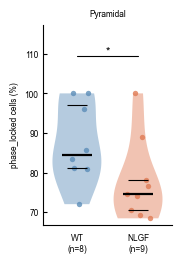

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/violin_phase_locked_proportion_Pyramidal_single_column.pdf


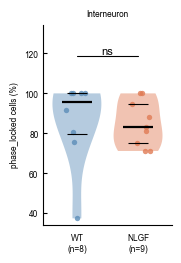

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/violin_phase_locked_proportion_Interneuron_single_column.pdf


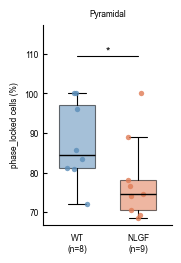

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/box_phase_locked_proportion_Pyramidal_single_column.pdf


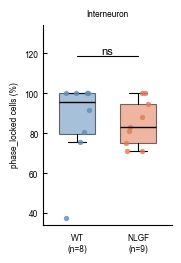

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/box_phase_locked_proportion_Interneuron_single_column.pdf


In [32]:
"""
Finally, we can visualize the animal-level proportions of phase_locked cells by genotype and cell type,
with significance from the GLMM results indicated on the plot.
"""

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _pstars(p):
    if pd.isna(p): return ""
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "ns"

# ── Build animal-level proportion table ───────────────────────────────────────
animal_pct = (
    df_linear_track
    .groupby(["mouse_name", "Genotype", "cell_type"])
    .agg(pct_phase_locked=("phase_locked", "mean"))
    .reset_index()
)
animal_pct["pct_phase_locked_100"] = animal_pct["pct_phase_locked"] * 100

cts_plot = [
    ct for ct in ["Pyramidal", "Interneuron"]
    if ct in animal_pct["cell_type"].values
]

rng_spat = np.random.default_rng(101)

def _glmm_stars(cell_type):
    fe = results.get(cell_type, {}).get("fixed_effects", None)
    if fe is None:
        return "", np.nan
    nlgf_row = fe[fe.index.str.contains("NLGF")]
    if nlgf_row.empty:
        return "", np.nan
    p_val = nlgf_row["p_value"].values[0]
    return _pstars(p_val), p_val

# ─── Plots ────────────────────────────────────────────────────────────────────
for plot_type in ("violin", "box"):
    for ct in cts_plot:

        fig, ax = plt.subplots(figsize=(1.65, 2.6))

        sub      = animal_pct[animal_pct["cell_type"] == ct]
        genos_ct = [g for g in GENO_ORDER if g in sub["Genotype"].values]
        vals     = {
            g: sub.loc[sub["Genotype"] == g, "pct_phase_locked_100"].values
            for g in genos_ct
        }

        # ── Violin ───────────────────────────────────────────────────────────
        if plot_type == "violin":
            if all(len(vals[g]) >= 3 for g in genos_ct):
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    parts = ax.violinplot(
                        [vals[g] for g in genos_ct],
                        positions=list(range(len(genos_ct))),
                        showmedians=False, showextrema=False, widths=0.8,
                    )
                for i_v, pc in enumerate(parts["bodies"]):
                    pc.set_facecolor(GENO_COLORS.get(genos_ct[i_v], "#aaaaaa"))
                    pc.set_alpha(0.45)
                    pc.set_edgecolor("none")

            for xi, g in enumerate(genos_ct):
                q1  = np.nanpercentile(vals[g], 25)
                med = np.nanmedian(vals[g])
                q3  = np.nanpercentile(vals[g], 75)
                ax.hlines([q1, q3], xi - 0.16, xi + 0.16,
                          colors="black", linewidth=0.8, zorder=7)
                ax.hlines(med, xi - 0.24, xi + 0.24,
                          colors="black", linewidth=1.6, zorder=6)

        # ── Box ──────────────────────────────────────────────────────────────
        else:
            for xi, g in enumerate(genos_ct):
                bp_parts = ax.boxplot(
                    vals[g], positions=[xi], widths=0.6,
                    patch_artist=True, manage_ticks=False,
                    showfliers=False,
                    boxprops=dict(facecolor=GENO_COLORS.get(g, "#aaaaaa"),
                                  alpha=0.55, linewidth=0.8),
                    medianprops=dict(color="black", linewidth=1.0),
                    whiskerprops=dict(linewidth=0.8),
                    capprops=dict(linewidth=0.8),
                )
                bp_parts["medians"][0].set_zorder(8)

        # ── Individual animal dots ────────────────────────────────────────────
        for xi, g in enumerate(genos_ct):
            jitter = rng_spat.uniform(-0.20, 0.20, size=len(vals[g]))
            ax.scatter(
                xi + jitter, vals[g],
                color=GENO_COLORS.get(g, "#aaaaaa"),
                s=15, alpha=0.8,
                zorder=5 if plot_type == "violin" else 4,
                linewidths=0,
            )

        # ── GLMM significance bracket ─────────────────────────────────────────
        if len(genos_ct) >= 2:
            stars, p_val = _glmm_stars(ct)
            if stars:
                all_v   = np.concatenate(list(vals.values()))
                y_top   = np.nanmax(all_v)
                y_range = np.nanmax(all_v) - np.nanmin(all_v) or 1.0
                bar_y   = y_top + 0.30 * y_range
                tip_y   = bar_y - 0.0  * y_range
                y_lo, y_hi = ax.get_ylim()
                ax.set_ylim(y_lo, max(y_hi, bar_y + 0.25 * y_range))
                x0, x1 = 0, len(genos_ct) - 1
                ax.plot([x0, x0, x1, x1], [tip_y, bar_y, bar_y, tip_y],
                        color="black", linewidth=0.8, zorder=10)
                ax.text((x0 + x1) / 2, bar_y, stars,
                        ha="center", va="bottom", fontsize=8,
                        fontweight="normal", color="black", zorder=10)

        # ── Axis styling ──────────────────────────────────────────────────────
        ax.set_xticks(list(range(len(genos_ct))))
        ax.set_xticklabels([f"{g}\n(n={len(vals[g])})" for g in genos_ct])
        ax.set_xlim(-0.55, len(genos_ct) - 0.45)
        ax.set_ylabel("phase_locked cells (%)")
        ax.set_title(ct)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="x", width=0.8, length=3)
        ax.tick_params(axis="y", width=0.8, length=3, direction="in")

        plt.tight_layout(pad=0.2, rect=[0, 0, 1, 0.95])

        fname = f"{plot_type}_phase_locked_proportion_{ct.replace(' ', '_')}_single_column.pdf"
        out_path = os.path.join(linear_track_OUTDIR, fname)
        fig.savefig(out_path)
        plt.show()
        plt.close(fig)
        print(f"Saved: {out_path}")

## Permutation test using mean proportion

Pyramidal: WT=0.874, NLGF=0.778, diff=-0.096, p=0.0805 ns
Interneuron: WT=0.857, NLGF=0.850, diff=-0.008, p=0.9361 ns


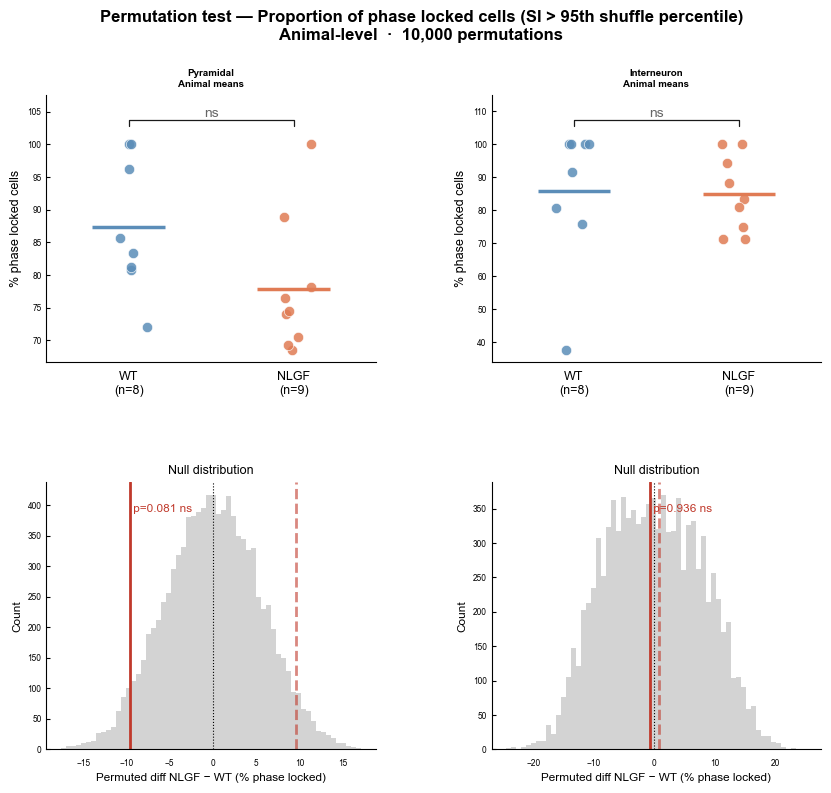

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/perm_test_phase_locked_proportion.pdf


In [33]:
"""
Permutation test: proportion of phase locked cells (WT vs NLGF), animal level using mean proportion per mouse, one test per cell type. 
This is a non-parametric alternative to the GLMM, which is more robust to outliers and small sample sizes. 
It also gives a nice visualisation of the null distribution of differences under the null hypothesis of no genotype effect.
DO NOT USE THIS TEST AS THERE IS AN OUTLIER IN THE NLGF GROUP (1117201) WITH 90% PHASE LOCKED CELLS, WHICH DRIVES THE SIGNIFICANT DIFFERENCE.
"""
import matplotlib.gridspec as gridspec

def permutation_test_proportion(df, cell_type, n_permutations=10000):
    sub = df[df['cell_type'] == cell_type].copy()
    
    animal_data = sub.groupby('mouse_name').agg(
        genotype=('Genotype', 'first'),
        pct_phase_locked=('phase_locked', 'mean')
    ).reset_index()
    
    nlgf_mean = animal_data[animal_data['genotype']=='NLGF']['pct_phase_locked'].mean()
    wt_mean   = animal_data[animal_data['genotype']=='WT']['pct_phase_locked'].mean()
    observed  = nlgf_mean - wt_mean
    
    null_dist = []
    genotypes = animal_data['genotype'].values.copy()
    
    for _ in range(n_permutations):
        shuffled = np.random.permutation(genotypes)
        animal_data['shuffled'] = shuffled
        nlgf_p = animal_data[animal_data['shuffled']=='NLGF']['pct_phase_locked'].mean()
        wt_p   = animal_data[animal_data['shuffled']=='WT']['pct_phase_locked'].mean()
        null_dist.append(nlgf_p - wt_p)
    
    null_dist = np.array(null_dist)
    p_value = np.mean(np.abs(null_dist) >= np.abs(observed))
    
    return {
        'cell_type':     cell_type,
        'mean_WT':       wt_mean,
        'mean_NLGF':     nlgf_mean,
        'observed_diff': observed,
        'null_dist':     null_dist,
        'p_value':       p_value,
        'animal_data':   animal_data,
        'n_WT_mice':     int((animal_data['genotype'] == 'WT').sum()),
        'n_NLGF_mice':   int((animal_data['genotype'] == 'NLGF').sum()),
    }

cts_to_test = [ct for ct in ['Pyramidal', 'Interneuron'] if ct in df_linear_track['cell_type'].values]
prop_results = {}

for ct in cts_to_test:
    res = permutation_test_proportion(df_linear_track, ct)
    prop_results[ct] = res
    print(f"{ct}: WT={res['mean_WT']:.3f}, NLGF={res['mean_NLGF']:.3f}, "
          f"diff={res['observed_diff']:.3f}, p={res['p_value']:.4f} {_pstars(res['p_value'])}")

# ── Plot: one column per cell type ───────────────────────────────────────────
n_cols = len(cts_to_test)
fig = plt.figure(figsize=(5.0 * n_cols, 8.5))
gs  = gridspec.GridSpec(2, n_cols, figure=fig, hspace=0.45, wspace=0.35)
rng_plot = np.random.default_rng(99)

for col_i, ct in enumerate(cts_to_test):
    r       = prop_results[ct]
    obs     = r['observed_diff']
    pval    = r['p_value']
    stars   = _pstars(pval)
    ad      = r['animal_data']

    # ── Top: animal-level dot plot ────────────────────────────────────────
    ax_dot = fig.add_subplot(gs[0, col_i])

    for xi, geno in enumerate(["WT", "NLGF"]):
        gd = ad[ad['genotype'] == geno]['pct_phase_locked'].values
        jitter = rng_plot.uniform(-0.12, 0.12, size=len(gd))
        ax_dot.scatter(
            xi + jitter, gd * 100,
            color=GENO_COLORS.get(geno, "#aaaaaa"),
            s=55, zorder=4, alpha=0.85, edgecolors="white", linewidths=0.5,
        )
        ax_dot.hlines(
            gd.mean() * 100, xi - 0.22, xi + 0.22,
            colors=GENO_COLORS.get(geno, "#aaaaaa"),
            linewidth=2.5, zorder=5,
        )

    # Significance bracket
    all_pct = ad['pct_phase_locked'].values * 100
    y_top   = np.nanmax(all_pct)
    y_range = np.nanmax(all_pct) - np.nanmin(all_pct) or 1.0
    bar_y   = y_top + 0.12 * y_range
    tip_y   = bar_y - 0.03 * y_range
    ax_dot.plot([0, 0, 1, 1], [tip_y, bar_y, bar_y, tip_y], "k-", linewidth=0.9)
    ax_dot.text(0.5, bar_y, stars,
                ha="center", va="bottom",
                fontsize=13 if pval < 0.05 else 10,
                fontweight="bold" if pval < 0.05 else "normal",
                color="black" if pval < 0.05 else "#666666")
    y_lo, y_hi = ax_dot.get_ylim()
    ax_dot.set_ylim(y_lo, max(y_hi, bar_y + 0.12 * y_range))

    ax_dot.set_xticks([0, 1])
    ax_dot.set_xticklabels(
        [f"WT\n(n={r['n_WT_mice']})", f"NLGF\n(n={r['n_NLGF_mice']})"], fontsize=9
    )
    ax_dot.set_xlim(-0.5, 1.5)
    ax_dot.set_ylabel("% phase locked cells", fontsize=9)
    set_panel_title(ax_dot, f"{ct}\nAnimal means")
    ax_dot.spines[["top", "right"]].set_visible(False)

    # ── Bottom: null distribution histogram ───────────────────────────────
    ax_null = fig.add_subplot(gs[1, col_i])

    ax_null.hist(r['null_dist'] * 100, bins=60, color="#cccccc", edgecolor="none", alpha=0.85)
    ax_null.axvline(obs * 100,  color="#C0392B", linewidth=2.0)
    ax_null.axvline(-obs * 100, color="#C0392B", linewidth=2.0, linestyle="--", alpha=0.6)
    ax_null.axvline(0,          color="black",   linewidth=0.8, linestyle=":")

    y_max = ax_null.get_ylim()[1]
    ax_null.text(
        obs * 100, y_max * 0.92,
        f" p={pval:.3f} {stars}",
        color="#C0392B", fontsize=8.5, va="top",
        fontweight="bold" if pval < 0.05 else "normal",
    )
    ax_null.set_xlabel("Permuted diff NLGF − WT (% phase locked)", fontsize=8.5)
    ax_null.set_ylabel("Count", fontsize=8.5)
    ax_null.set_title("Null distribution", fontsize=9)
    ax_null.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Permutation test — Proportion of phase locked cells (SI > 95th shuffle percentile)\n"
    f"Animal-level  ·  10,000 permutations",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
out_path = os.path.join(linear_track_OUTDIR, "perm_test_phase_locked_proportion.pdf")
plt.savefig(out_path, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved: {out_path}")

## Permutation test using the median 

Pyramidal: WT median=0.845, NLGF median=0.745, diff=-0.101, p=0.1333 ns
Interneuron: WT median=0.958, NLGF median=0.833, diff=-0.125, p=0.3439 ns


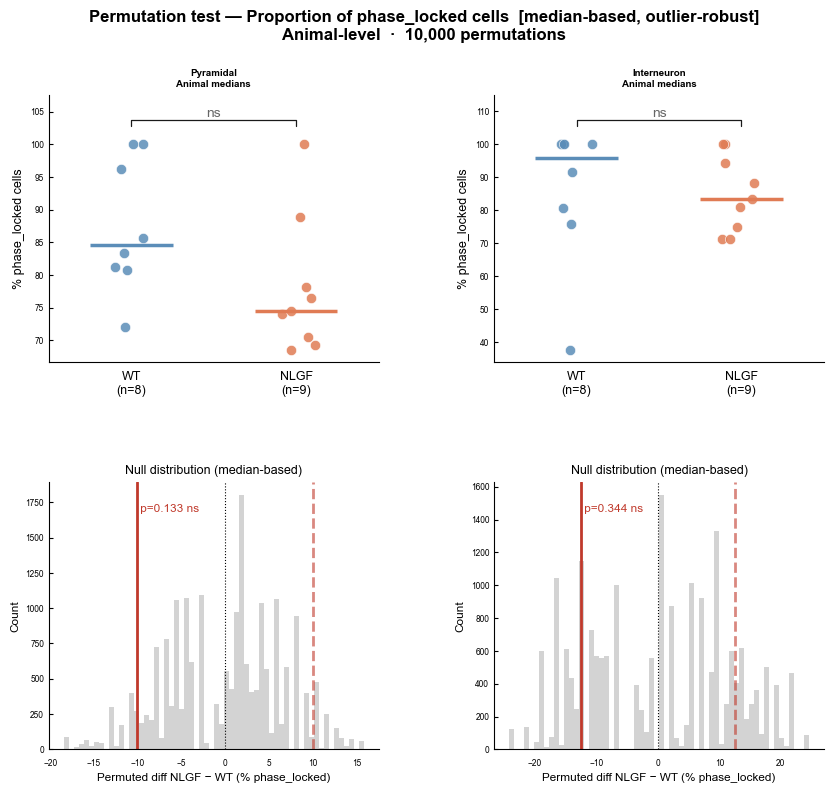

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/perm_test_phase_locked_proportion_robust.pdf


In [34]:
"""
Robust version of the permutation test using MEDIAN instead of mean, to reduce the influence of outliers (e.g. mouse 1117201 with 90% phase_locked cells).
"""
import matplotlib.gridspec as gridspec

def permutation_test_robust(df, cell_type, n_permutations=20000):
    sub = df[df['cell_type'] == cell_type].copy()
    
    animal_data = sub.groupby('mouse_name').agg(
        genotype=('Genotype', 'first'),
        pct_phase_locked=('phase_locked', 'mean')
    ).reset_index()
    
    nlgf_med = animal_data[animal_data['genotype']=='NLGF']['pct_phase_locked'].median()
    wt_med   = animal_data[animal_data['genotype']=='WT']['pct_phase_locked'].median()
    observed = nlgf_med - wt_med
    
    null_dist = []
    genotypes = animal_data['genotype'].values.copy()
    
    for _ in range(n_permutations):
        shuffled = np.random.permutation(genotypes)
        animal_data['shuffled'] = shuffled
        null_dist.append(
            animal_data[animal_data['shuffled']=='NLGF']['pct_phase_locked'].median() -
            animal_data[animal_data['shuffled']=='WT']['pct_phase_locked'].median()
        )
    
    null_dist = np.array(null_dist)
    p_value = np.mean(np.abs(null_dist) >= np.abs(observed))
    
    return {
        'observed_diff': observed,
        'p_value':       p_value,
        'null_dist':     null_dist,
        'median_WT':     wt_med,
        'median_NLGF':   nlgf_med,
        'animal_data':   animal_data,
    }

cts_to_test = [ct for ct in ['Pyramidal', 'Interneuron'] if ct in df_linear_track['cell_type'].values]
robust_results = {}

for ct in cts_to_test:
    res = permutation_test_robust(df_linear_track, ct)
    robust_results[ct] = res
    print(f"{ct}: WT median={res['median_WT']:.3f}, NLGF median={res['median_NLGF']:.3f}, "
          f"diff={res['observed_diff']:.3f}, p={res['p_value']:.4f} {_pstars(res['p_value'])}")

# ── Plot ──────────────────────────────────────────────────────────────────────
n_cols   = len(cts_to_test)
fig      = plt.figure(figsize=(5.0 * n_cols, 8.5))
gs       = gridspec.GridSpec(2, n_cols, figure=fig, hspace=0.45, wspace=0.35)
rng_rob  = np.random.default_rng(77)

for col_i, ct in enumerate(cts_to_test):
    r     = robust_results[ct]
    obs   = r['observed_diff']
    pval  = r['p_value']
    stars = _pstars(pval)
    ad    = r['animal_data']

    # ── Top: animal-level dot plot with median bar ────────────────────────
    ax_dot = fig.add_subplot(gs[0, col_i])

    for xi, geno in enumerate(["WT", "NLGF"]):
        gd      = ad[ad['genotype'] == geno]['pct_phase_locked'].values
        jitter  = rng_rob.uniform(-0.12, 0.12, size=len(gd))
        ax_dot.scatter(
            xi + jitter, gd * 100,
            color=GENO_COLORS.get(geno, "#aaaaaa"),
            s=55, zorder=4, alpha=0.85, edgecolors="white", linewidths=0.5,
        )
        # Median bar (filled, slightly wider than mean bar to signal it's median)
        ax_dot.hlines(
            np.median(gd) * 100, xi - 0.25, xi + 0.25,
            colors=GENO_COLORS.get(geno, "#aaaaaa"),
            linewidth=2.5, zorder=5,
        )

    # Significance bracket
    all_pct = ad['pct_phase_locked'].values * 100
    y_top   = np.nanmax(all_pct)
    y_range = np.nanmax(all_pct) - np.nanmin(all_pct) or 1.0
    bar_y   = y_top + 0.12 * y_range
    tip_y   = bar_y - 0.03 * y_range
    ax_dot.plot([0, 0, 1, 1], [tip_y, bar_y, bar_y, tip_y], "k-", linewidth=0.9)
    ax_dot.text(0.5, bar_y, stars,
                ha="center", va="bottom",
                fontsize=13 if pval < 0.05 else 10,
                fontweight="bold" if pval < 0.05 else "normal",
                color="black" if pval < 0.05 else "#666666")
    y_lo, y_hi = ax_dot.get_ylim()
    ax_dot.set_ylim(y_lo, max(y_hi, bar_y + 0.12 * y_range))

    n_wt   = int((ad['genotype'] == 'WT').sum())
    n_nlgf = int((ad['genotype'] == 'NLGF').sum())
    ax_dot.set_xticks([0, 1])
    ax_dot.set_xticklabels([f"WT\n(n={n_wt})", f"NLGF\n(n={n_nlgf})"], fontsize=9)
    ax_dot.set_xlim(-0.5, 1.5)
    ax_dot.set_ylabel("% phase_locked cells", fontsize=9)
    set_panel_title(ax_dot, f"{ct}\nAnimal medians")
    ax_dot.spines[["top", "right"]].set_visible(False)

    # ── Bottom: null distribution histogram ───────────────────────────────
    ax_null = fig.add_subplot(gs[1, col_i])

    ax_null.hist(r['null_dist'] * 100, bins=60, color="#cccccc", edgecolor="none", alpha=0.85)
    ax_null.axvline(obs * 100,  color="#C0392B", linewidth=2.0)
    ax_null.axvline(-obs * 100, color="#C0392B", linewidth=2.0, linestyle="--", alpha=0.6)
    ax_null.axvline(0,          color="black",   linewidth=0.8, linestyle=":")

    y_max = ax_null.get_ylim()[1]
    ax_null.text(
        obs * 100, y_max * 0.92,
        f" p={pval:.3f} {stars}",
        color="#C0392B", fontsize=8.5, va="top",
        fontweight="bold" if pval < 0.05 else "normal",
    )
    ax_null.set_xlabel("Permuted diff NLGF − WT (% phase_locked)", fontsize=8.5)
    ax_null.set_ylabel("Count", fontsize=8.5)
    ax_null.set_title("Null distribution (median-based)", fontsize=9)
    ax_null.spines[["top", "right"]].set_visible(False)
    sns.set_theme(style="white")
    apply_style()

fig.suptitle(
    "Permutation test — Proportion of phase_locked cells  [median-based, outlier-robust]\n"
    "Animal-level  ·  10,000 permutations",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
out_path = os.path.join(linear_track_OUTDIR, "perm_test_phase_locked_proportion_robust.pdf")
plt.savefig(out_path, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved: {out_path}")

# Spike width, kl_spatial_sparsity and theta_modulation_v3 analysis

In [35]:
def sig_label(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'
    
def _pstars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def _safe_filename(s):
    return s.replace(' ', '_').replace('/', '-')

## Animal-level spike width summary 

In [36]:
"""
Animal-level spike width summary
Computes the per-animal mean spike width separately for Pyramidal and Interneuron cells,
then prints descriptive statistics (count, mean, std, quartiles) grouped by genotype (NLGF vs WT). 
This gives a quick sanity check of whether the two genotypes differ at the animal level before formal testing.
"""

# Do NLGF and WT animals actually differ at the animal level?
# Compute once for all cell types — keeps 'cell_type' as a column
animal_spike_width = (df_linear_track
                      .groupby(['mouse_name', 'Genotype', 'cell_type'])['spike_width']
                      .mean()
                      .reset_index())

print("------------------ PYRAMIDAL ------------------------\n",
      animal_spike_width[animal_spike_width['cell_type'] == 'Pyramidal']
      .groupby("Genotype")["spike_width"].describe())

print("------------------ INTERNEURON ------------------------\n",
      animal_spike_width[animal_spike_width['cell_type'] == 'Interneuron']
      .groupby("Genotype")["spike_width"].describe())


# # Plot per-animal mean spike width for Pyramidal and Interneuron cells
# fig, axes = plt.subplots(1, 2, figsize=(8.0, 5.0))
# genos = ['WT', 'NLGF']

# for ax, ct in zip(axes, ['Pyramidal', 'Interneuron']):
#     sub  = animal_spike_width[animal_spike_width['cell_type'] == ct]
#     vals = {g: sub[sub['Genotype'] == g]['spike_width'].values for g in genos}
#     for xi, g in enumerate(genos):
#         jitter = np.random.uniform(-0.1, 0.1, size=len(vals[g]))
#         ax.scatter(xi + jitter, vals[g], color=GENO_COLORS.get(g, '#aaaaaa'),
#                    s=50, alpha=0.8, edgecolors='white', linewidths=0.5)
#         ax.hlines(np.mean(vals[g]), xi - 0.2, xi + 0.2,
#                   colors=GENO_COLORS.get(g, '#aaaaaa'), linewidth=2.5)
#     ax.set_xticks(list(range(len(genos))))
#     ax.set_xticklabels([f"{g}\n(n={len(vals[g])} mice)" for g in genos], fontsize=9)
#     ax.set_xlim(-0.5, len(genos) - 0.5)
#     ax.set_ylabel("Mean spike width (ms)", fontsize=9)
#     ax.set_title(ct, fontsize=10, fontweight='bold')
#     ax.spines[['top', 'right']].set_visible(False)

# plt.suptitle("Animal-level mean spike width", fontsize=11, fontweight='bold')
# plt.tight_layout()
# out_path = os.path.join(linear_track_OUTDIR, "mean_spike_width_by_celltype.pdf")
# plt.savefig(out_path, bbox_inches='tight')
# plt.show()
# plt.close(fig)
# print(f"Saved: {out_path}")

------------------ PYRAMIDAL ------------------------
           count        mean        std         min         25%         50%  \
Genotype                                                                     
NLGF        9.0  476.251527  19.638653  437.777778  465.263158  482.272727   
WT          8.0  462.374377  17.862606  424.827586  459.230769  462.460317   

                 75%         max  
Genotype                          
NLGF      488.750000  504.615385  
WT        471.987179  484.375000  
------------------ INTERNEURON ------------------------
           count        mean        std         min         25%         50%  \
Genotype                                                                     
NLGF        9.0  189.914431  30.845185  156.666667  170.588235  176.666667   
WT          8.0  206.195623  31.807776  158.461538  188.160920  205.000000   

            75%    max  
Genotype                
NLGF      215.0  248.0  
WT        229.5  250.0  


## Animal-level kl_spatial_sparsity summary


In [37]:
"""
Animal-level kl_spatial_sparsity summary
Computes the per-animal kl_spatial_sparsity width separately for Pyramidal and Interneuron cells,
then prints descriptive statistics (count, mean, std, quartiles) grouped by genotype (NLGF vs WT). 
This gives a quick sanity check of whether the two genotypes differ at the animal level before formal testing.
"""

# Do NLGF and WT animals actually differ at the animal level?
animal_kl_spatial_sparsity = (df_linear_track
                      .groupby(['mouse_name', 'Genotype'])['kl_spatial_sparsity']
                      .mean()
                      .reset_index())

print(animal_kl_spatial_sparsity.groupby("Genotype")["kl_spatial_sparsity"].describe())


          count      mean       std       min       25%       50%       75%  \
Genotype                                                                      
NLGF        9.0  1.016292  0.375542  0.493422  0.656385  1.112553  1.267191   
WT          8.0  1.231348  0.523030  0.317603  0.835456  1.520834  1.593943   

               max  
Genotype            
NLGF      1.632967  
WT        1.701402  


## Animal-level spike numpers


In [38]:
# Do NLGF and WT animals actually differ at the animal level?
# Compute once for all cell types — keeps 'cell_type' as a column
animal_spike_num = (df_linear_track
                       .groupby(['mouse_name', 'Genotype', 'cell_type'])['num_spikes']
                       .mean()
                       .reset_index())

print("------------------ PYRAMIDAL ------------------------\n",
      animal_spike_num[animal_spike_num['cell_type'] == 'Pyramidal']
      .groupby("Genotype")["num_spikes"].describe())

print("------------------ INTERNEURON ------------------------\n",
      animal_spike_num[animal_spike_num['cell_type'] == 'Interneuron']
      .groupby("Genotype")["num_spikes"].describe())


------------------ PYRAMIDAL ------------------------
           count         mean         std         min          25%  \
Genotype                                                            
NLGF        9.0  1226.141537  622.809609  756.777778   883.638298   
WT          8.0  1555.053904  544.159006  872.115385  1170.057292   

                  50%          75%          max  
Genotype                                         
NLGF      1072.454545  1196.230769  2812.705882  
WT        1456.112890  1825.417308  2580.166667  
------------------ INTERNEURON ------------------------
           count         mean          std     min          25%          50%  \
Genotype                                                                      
NLGF        9.0  4230.057743  2578.302527  491.25  2165.666667  4551.411765   
WT          8.0  5360.478403  2859.807580  771.25  4058.245192  5740.877395   

                  75%          max  
Genotype                            
NLGF      6694.66666

## Animal-level theta-modulation 


In [39]:
# Do NLGF and WT animals actually differ at the animal level?
# Compute once for all cell types — keeps 'cell_type' as a column
animal_theta_mod_v3 = (df_linear_track
                       .groupby(['mouse_name', 'Genotype', 'cell_type'])['theta_mod_v3']
                       .mean()
                       .reset_index())

print("------------------ PYRAMIDAL ------------------------\n",
      animal_theta_mod_v3[animal_theta_mod_v3['cell_type'] == 'Pyramidal']
      .groupby("Genotype")["theta_mod_v3"].describe())

print("------------------ INTERNEURON ------------------------\n",
      animal_theta_mod_v3[animal_theta_mod_v3['cell_type'] == 'Interneuron']
      .groupby("Genotype")["theta_mod_v3"].describe())


------------------ PYRAMIDAL ------------------------
           count      mean       std       min       25%       50%       75%  \
Genotype                                                                      
NLGF        9.0  0.060186  0.020955  0.033124  0.047532  0.055671  0.075040   
WT          8.0  0.090004  0.031650  0.035724  0.068245  0.092771  0.118571   

               max  
Genotype            
NLGF      0.100493  
WT        0.123151  
------------------ INTERNEURON ------------------------
           count      mean       std       min       25%       50%       75%  \
Genotype                                                                      
NLGF        9.0  0.048613  0.026774  0.007914  0.036943  0.043844  0.063940   
WT          8.0  0.074527  0.041478  0.016597  0.047431  0.079099  0.108504   

               max  
Genotype            
NLGF      0.099718  
WT        0.121626  


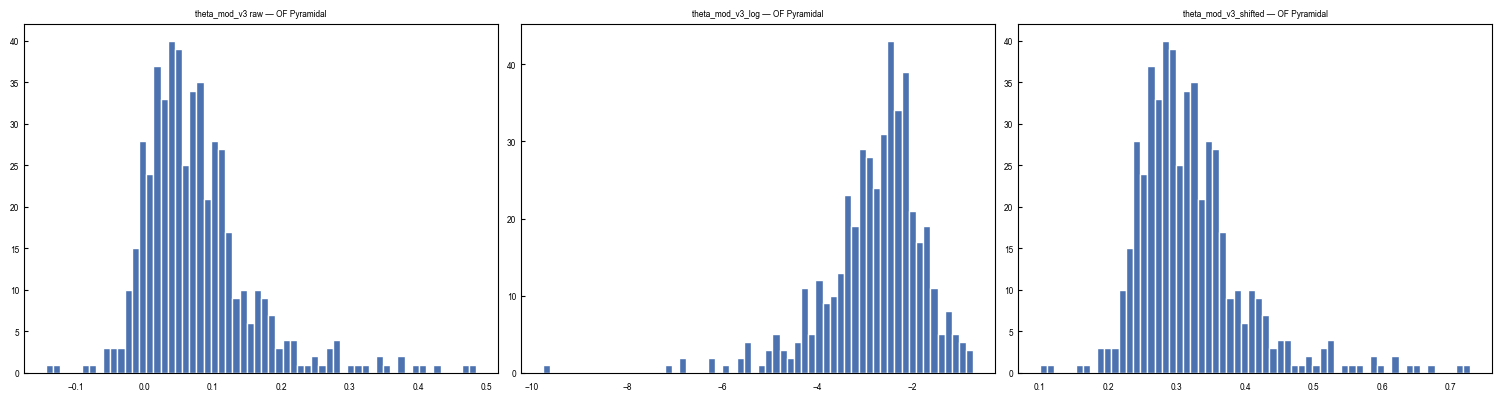

In [40]:
import matplotlib.pyplot as plt

sub = df_linear_track[(df_linear_track['environment'] == 'linear_track') & 
         (df_linear_track['cell_type'] == 'Pyramidal')]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Raw
axes[0].hist(sub['theta_mod_v3'], bins=60)
axes[0].set_title('theta_mod_v3 raw — OF Pyramidal')

# Log-shifted  
axes[1].hist(sub['theta_mod_v3_log'], bins=60)
axes[1].set_title('theta_mod_v3_log — OF Pyramidal')

# 'theta_mod_v3'] + 0.20 shifted
axes[2].hist(sub['theta_mod_v3_shifted'], bins=60)
axes[2].set_title('theta_mod_v3_shifted — OF Pyramidal')


plt.tight_layout()
plt.show()

## Step 1 — Normality tests (Shapiro–Wilk) for spike_width, kl_spatial_sparsity, num_spikes, and theta_mod_v3, at the animal level

In [41]:
# ── Step 1: Normality tests (Shapiro–Wilk), one per metric × environment × cell_type ──
# Tested on per-animal means (one value per mouse, per genotype). Both genotype
# groups must pass (p > 0.05) for the combination to be treated as normally
# distributed; this decision drives Steps 2, 3 and 5 below.
from scipy.stats import shapiro

SW_METRICS = ['spike_width', 'kl_spatial_sparsity', 'num_spikes', 'theta_mod_v3']

# kl_spatial_sparsity is a single animal-level value (identical across a mouse's
# cells, unlike the other three per-cell metrics), so it is tested once per
# animal x environment rather than separately per cell_type.
ANIMAL_LEVEL_METRICS = {'kl_spatial_sparsity'}

animal_agg_store  = {}   # (metric, env, cell_type) -> per-animal mean/median dataframe
normality_results = {}   # (metric, env, cell_type) -> bool (True = both genotypes normal)
normality_rows    = []

for metric in SW_METRICS:
    cell_types = ['all'] if metric in ANIMAL_LEVEL_METRICS else df_linear_track['cell_type'].unique()
    for env in df_linear_track['environment'].unique():
        for ct in cell_types:
            env_mask = df_linear_track['environment'] == env
            ct_mask  = True if ct == 'all' else (df_linear_track['cell_type'] == ct)
            sub = df_linear_track[env_mask & ct_mask]
            if sub.empty:
                continue

            animal_df = (
                sub.groupby(['mouse_name', 'Genotype'])[metric]
                .agg(metric_mean='mean', metric_median='median', n_cells='count')
                .reset_index()
            )
            animal_agg_store[(metric, env, ct)] = animal_df

            is_normal = True
            for geno in GENO_ORDER:
                vals = animal_df.loc[animal_df['Genotype'] == geno, 'metric_mean'].dropna().values
                if len(vals) < 3:
                    is_normal = False
                    sw_p = np.nan
                else:
                    _, sw_p = shapiro(vals)
                    if sw_p <= 0.05:
                        is_normal = False
                normality_rows.append({
                    'metric': metric, 'environment': env, 'cell_type': ct,
                    'Genotype': geno, 'n_mice': len(vals), 'shapiro_p': sw_p,
                })

            normality_results[(metric, env, ct)] = is_normal

normality_df = pd.DataFrame(normality_rows)
normality_df['normal'] = normality_df['shapiro_p'] > 0.05
print(normality_df.to_string(index=False))

             metric  environment   cell_type Genotype  n_mice  shapiro_p  normal
        spike_width linear_track   Pyramidal       WT       8   0.233786    True
        spike_width linear_track   Pyramidal     NLGF       9   0.804869    True
        spike_width linear_track Interneuron       WT       8   0.891316    True
        spike_width linear_track Interneuron     NLGF       9   0.229351    True
kl_spatial_sparsity linear_track         all       WT       8   0.057635    True
kl_spatial_sparsity linear_track         all     NLGF       9   0.664166    True
         num_spikes linear_track   Pyramidal       WT       8   0.730873    True
         num_spikes linear_track   Pyramidal     NLGF       9   0.000697   False
         num_spikes linear_track Interneuron       WT       8   0.863159    True
         num_spikes linear_track Interneuron     NLGF       9   0.453633    True
       theta_mod_v3 linear_track   Pyramidal       WT       8   0.381494    True
       theta_mod_v3 linear_t

## Step 2 — Levene's test for homogeneity of variance (center chosen from Step 1's normality result)

In [42]:
# ── Step 2: Levene's test for homogeneity of variance ────────────────────────
# center='mean' (classic Levene) when Step 1 found the combination normal,
# center='median' (Brown-Forsythe, robust to non-normality) otherwise.
from scipy.stats import levene

levene_results = {}   # (metric, env, cell_type) -> dict(statistic, p_value, center, equal_var)
levene_rows = []

for key, animal_df in animal_agg_store.items():
    metric, env, ct = key
    is_normal = normality_results[key]
    center = 'mean' if is_normal else 'median'

    wt_vals   = animal_df.loc[animal_df['Genotype'] == 'WT',   'metric_mean'].dropna().values
    nlgf_vals = animal_df.loc[animal_df['Genotype'] == 'NLGF', 'metric_mean'].dropna().values
    if len(wt_vals) < 2 or len(nlgf_vals) < 2:
        continue

    stat, p = levene(wt_vals, nlgf_vals, center=center)
    equal_var = p > 0.05
    levene_results[key] = {'statistic': stat, 'p_value': p, 'center': center, 'equal_var': equal_var}
    levene_rows.append({
        'metric': metric, 'environment': env, 'cell_type': ct,
        'normal': is_normal, 'levene_center': center,
        'levene_stat': stat, 'levene_p': p, 'equal_var': equal_var,
    })

levene_df = pd.DataFrame(levene_rows)
print(levene_df.to_string(index=False))

             metric  environment   cell_type  normal levene_center  levene_stat  levene_p  equal_var
        spike_width linear_track   Pyramidal    True          mean     0.386283  0.543591       True
        spike_width linear_track Interneuron    True          mean     0.020166  0.888963       True
kl_spatial_sparsity linear_track         all    True          mean     2.117663  0.166217       True
         num_spikes linear_track   Pyramidal   False        median     0.123782  0.729862       True
         num_spikes linear_track Interneuron    True          mean     0.008370  0.928315       True
       theta_mod_v3 linear_track   Pyramidal    True          mean     2.239778  0.155244       True
       theta_mod_v3 linear_track Interneuron    True          mean     2.078292  0.169959       True


## Step 3 — Primary statistical test: t-test if normal (Student's/Welch's per Step 2), Mann-Whitney U otherwise

In [43]:
# ── Step 3: Primary statistical test ──────────────────────────────────────────
# Normal (Step 1) -> t-test on per-animal means; equal_var from Step 2's Levene
# result picks Student's (equal_var=True) vs Welch's (equal_var=False).
# Not normal -> Mann-Whitney U on per-animal medians.
from scipy.stats import ttest_ind, mannwhitneyu

test_results = []

for key, animal_df in animal_agg_store.items():
    metric, env, ct = key
    is_normal = normality_results[key]

    if is_normal:
        value_col = 'metric_mean'
        equal_var = levene_results[key]['equal_var']
        wt_vals   = animal_df.loc[animal_df['Genotype'] == 'WT',   value_col].dropna().values
        nlgf_vals = animal_df.loc[animal_df['Genotype'] == 'NLGF', value_col].dropna().values
        if len(wt_vals) < 2 or len(nlgf_vals) < 2:
            continue
        stat, p_val = ttest_ind(wt_vals, nlgf_vals, equal_var=equal_var)
        test_name = "Student's t-test" if equal_var else "Welch's t-test"
    else:
        value_col = 'metric_median'
        wt_vals   = animal_df.loc[animal_df['Genotype'] == 'WT',   value_col].dropna().values
        nlgf_vals = animal_df.loc[animal_df['Genotype'] == 'NLGF', value_col].dropna().values
        if len(wt_vals) < 1 or len(nlgf_vals) < 1:
            continue
        stat, p_val = mannwhitneyu(wt_vals, nlgf_vals, alternative='two-sided')
        test_name = 'Mann-Whitney U'

    test_results.append({
        'metric': metric, 'environment': env, 'cell_type': ct,
        'test': test_name, 'value_col': value_col,
        'statistic': stat, 'p_value': p_val,
        'n_WT': len(wt_vals), 'n_NLGF': len(nlgf_vals),
        'WT_value':   np.mean(wt_vals)   if is_normal else np.median(wt_vals),
        'NLGF_value': np.mean(nlgf_vals) if is_normal else np.median(nlgf_vals),
    })

test_results_df = pd.DataFrame(test_results)
test_results_df['significance'] = test_results_df['p_value'].apply(_pstars)
print(test_results_df)

test_results_path = os.path.join(linear_track_OUTDIR,
    "primary_test_results_spike_width_kl_spatial_sparsity_num_spikes_theta_mod_v3.csv")
test_results_df.to_csv(test_results_path, index=False)
print(f"\n✅ Primary test results saved to: {test_results_path}")

                metric   environment    cell_type              test  \
0          spike_width  linear_track    Pyramidal  Student's t-test   
1          spike_width  linear_track  Interneuron  Student's t-test   
2  kl_spatial_sparsity  linear_track          all  Student's t-test   
3           num_spikes  linear_track    Pyramidal    Mann-Whitney U   
4           num_spikes  linear_track  Interneuron  Student's t-test   
5         theta_mod_v3  linear_track    Pyramidal  Student's t-test   
6         theta_mod_v3  linear_track  Interneuron  Student's t-test   

       value_col  statistic   p_value  n_WT  n_NLGF     WT_value   NLGF_value  \
0    metric_mean  -1.516617  0.150153     8       9   462.374377   476.251527   
1    metric_mean   1.070558  0.301292     8       9   206.195623   189.914431   
2    metric_mean   0.982600  0.341388     8       9     1.231348     1.016292   
3  metric_median  56.000000  0.059235     8       9  1086.500000   741.500000   
4    metric_mean   0.85739

## Step 4 — Box plots for spike_width, kl_spatial_sparsity, num_spikes, and theta_mod_v3 (bracket & stars from the Step 3 test)

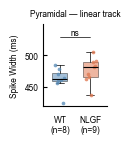

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/box_spike_width_linear_track_Pyramidal_single_column.pdf | Student's t-test p=0.1502 ns


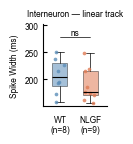

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/box_spike_width_linear_track_Interneuron_single_column.pdf | Student's t-test p=0.3013 ns


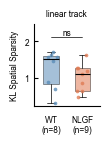

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/box_kl_spatial_sparsity_linear_track_all_single_column.pdf | Student's t-test p=0.3414 ns


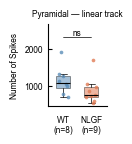

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/box_num_spikes_linear_track_Pyramidal_single_column.pdf | Mann-Whitney U p=0.0592 ns


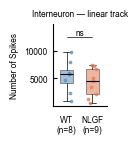

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/box_num_spikes_linear_track_Interneuron_single_column.pdf | Student's t-test p=0.4047 ns


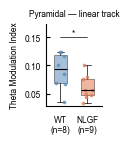

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/box_theta_mod_v3_linear_track_Pyramidal_single_column.pdf | Student's t-test p=0.0351 *


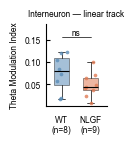

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/box_theta_mod_v3_linear_track_Interneuron_single_column.pdf | Student's t-test p=0.1422 ns


In [44]:
# ── Step 4: Box plots — bracket & stars from the Step 3 primary test ─────────
METRIC_LABELS = {
    'spike_width':         'Spike Width (ms)',
    'kl_spatial_sparsity': 'KL Spatial Sparsity',
    'num_spikes':          'Number of Spikes',
    'theta_mod_v3':        'Theta Modulation Index',
}
rng_plot = np.random.default_rng(77)

for metric in SW_METRICS:
    ylabel = METRIC_LABELS.get(metric, metric)
    cell_types = ['all'] if metric in ANIMAL_LEVEL_METRICS else df_linear_track['cell_type'].unique()

    for env in df_linear_track['environment'].unique():
        for ct in cell_types:
            key = (metric, env, ct)
            if key not in animal_agg_store:
                continue

            row = test_results_df[
                (test_results_df['metric'] == metric) &
                (test_results_df['environment'] == env) &
                (test_results_df['cell_type'] == ct)
            ]
            if row.empty:
                continue
            row = row.iloc[0]
            value_col = row['value_col']
            pval, stars = row['p_value'], row['significance']

            animal_df = animal_agg_store[key]
            genos_ct = [g for g in GENO_ORDER if g in animal_df['Genotype'].values]
            vals = {g: animal_df.loc[animal_df['Genotype'] == g, value_col].dropna().values
                    for g in genos_ct}
            if not all(len(vals[g]) for g in genos_ct):
                continue

            title = env.replace('_', ' ')
            if ct != 'all':
                title = f"{ct} — {title}"

            fig, ax = plt.subplots(figsize=(1, 1.35))

            for xi, g in enumerate(genos_ct):
                bp_parts = ax.boxplot(
                    vals[g], positions=[xi], widths=0.5,
                    patch_artist=True, manage_ticks=False,
                    showfliers=False,
                    boxprops=dict(facecolor=GENO_COLORS.get(g, "#aaaaaa"),
                                  alpha=0.55, linewidth=0.5),
                    medianprops=dict(color="black", linewidth=0.8),
                    whiskerprops=dict(linewidth=0.5),
                    capprops=dict(linewidth=0.5),
                )
                bp_parts["medians"][0].set_zorder(8)

            for xi, g in enumerate(genos_ct):
                jitter = rng_plot.uniform(-0.20, 0.20, size=len(vals[g]))
                ax.scatter(xi + jitter, vals[g],
                           color=GENO_COLORS.get(g, "#aaaaaa"),
                           s=7, alpha=0.8, zorder=4, linewidths=0)

            if len(genos_ct) >= 2:
                all_v   = np.concatenate([vals[g] for g in genos_ct])
                y_top   = np.nanmax(all_v)
                y_range = np.nanmax(all_v) - np.nanmin(all_v) or 1.0
                bar_y   = y_top + 0.30 * y_range
                tip_y   = bar_y
                y_lo, y_hi = ax.get_ylim()
                ax.set_ylim(y_lo, max(y_hi, bar_y + 0.25 * y_range))
                x0, x1 = 0, len(genos_ct) - 1
                ax.plot([x0, x0, x1, x1], [tip_y, bar_y, bar_y, tip_y],
                        color="black", linewidth=0.5, zorder=10)
                ax.text((x0 + x1) / 2, bar_y, stars,
                        ha="center", va="bottom", fontsize=6,
                        fontweight="normal", color="black", zorder=10)

            ax.set_xticks(list(range(len(genos_ct))))
            ax.set_xticklabels([f"{g}\n(n={len(vals[g])})" for g in genos_ct])
            ax.set_xlim(-0.55, len(genos_ct) - 0.45)
            ax.set_ylabel(ylabel)
            ax.set_title(title)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            plt.tight_layout(pad=0.2, rect=[0, 0, 1, 0.95])

            safe_ct  = ct.replace(' ', '_').replace('/', '-')
            safe_env = env.replace(' ', '_')
            fname    = f"box_{metric}_{safe_env}_{safe_ct}_single_column.pdf"
            out_path = os.path.join(linear_track_OUTDIR, fname)
            fig.savefig(out_path)
            plt.show()
            plt.close(fig)
            print(f"Saved: {out_path} | {row['test']} p={pval:.4f} {stars}")

## Step 5 — Permutation tests (animal-level; mean-based if Step 1 found the combination normal, median-based otherwise)

In [ ]:
# ── Step 5: Permutation tests, mean- or median-based per Step 1's normality call ──
from itertools import product as iterproduct
from IPython.display import display, HTML

def permutation_test_animal_level(df, metric_col, use_median, n_permutations, rng):
    """Shuffles genotype at the animal level. Test statistic is the difference of
    per-animal medians when `use_median` is True (non-normal combinations), or of
    per-animal means otherwise — matching the Step 1 normality decision."""
    agg = 'median' if use_median else 'mean'
    animal_data = df.groupby('mouse_name').agg(
        genotype=('Genotype', 'first'),
        metric_val=(metric_col, agg),
    ).reset_index()

    nlgf_val = animal_data.loc[animal_data['genotype'] == 'NLGF', 'metric_val'].agg(agg)
    wt_val   = animal_data.loc[animal_data['genotype'] == 'WT',   'metric_val'].agg(agg)
    observed = nlgf_val - wt_val

    genotypes = animal_data['genotype'].values.copy()
    null_distribution = np.empty(n_permutations)
    for i in range(n_permutations):
        animal_data['shuffled'] = rng.permutation(genotypes)
        nlgf_perm = animal_data.loc[animal_data['shuffled'] == 'NLGF', 'metric_val'].agg(agg)
        wt_perm   = animal_data.loc[animal_data['shuffled'] == 'WT',   'metric_val'].agg(agg)
        null_distribution[i] = nlgf_perm - wt_perm

    p_value = np.mean(np.abs(null_distribution) >= np.abs(observed))
    return {'observed_difference': observed, 'p_value': p_value,
            'n_permutations': n_permutations, 'null_distribution': null_distribution, 'agg': agg}

N_PERM = 10000
rng = np.random.default_rng(42)

null_dists         = {}
perm_animal_store  = {}
perm_results       = []

for metric in SW_METRICS:
    cell_types = ['all'] if metric in ANIMAL_LEVEL_METRICS else df_linear_track['cell_type'].unique()
    for env in df_linear_track['environment'].unique():
        for ct in cell_types:
            key = (metric, env, ct)
            if key not in animal_agg_store:
                continue

            env_mask = df_linear_track['environment'] == env
            ct_mask  = True if ct == 'all' else (df_linear_track['cell_type'] == ct)
            sub = df_linear_track[env_mask & ct_mask].copy()
            mice_per_geno = sub.groupby('Genotype')['mouse_name'].nunique()
            if mice_per_geno.min() < 2 or len(mice_per_geno) < 2:
                print(f"  {metric:22s} | {env:15s} | {ct:12s} — skipped (too few mice per genotype)")
                continue

            use_median = not normality_results[key]
            res = permutation_test_animal_level(sub, metric, use_median, n_permutations=N_PERM, rng=rng)

            animal_df = animal_agg_store[key]
            nlgf, wt = animal_df[animal_df['Genotype'] == 'NLGF'], animal_df[animal_df['Genotype'] == 'WT']
            val_col = 'metric_median' if use_median else 'metric_mean'
            agg_fn  = np.median if use_median else np.mean

            null_dists[key]        = res['null_distribution']
            perm_animal_store[key] = animal_df

            row = {
                'metric': metric, 'environment': env, 'cell_type': ct, 'agg': res['agg'],
                'n_NLGF_mice': len(nlgf), 'n_WT_mice': len(wt),
                'n_NLGF_cells': int(nlgf['n_cells'].sum()), 'n_WT_cells': int(wt['n_cells'].sum()),
                'NLGF_value': agg_fn(nlgf[val_col]), 'WT_value': agg_fn(wt[val_col]),
                'observed_diff': res['observed_difference'],
                'p_value': res['p_value'],
                'sig': sig_label(res['p_value']),
            }
            perm_results.append(row)

            print(f"  {metric:22s} | {env:15s} | {ct:12s} | agg={res['agg']:6s} | "
                  f"NLGF={row['NLGF_value']:.3f} (n={row['n_NLGF_mice']}m/{row['n_NLGF_cells']}c)  "
                  f"WT={row['WT_value']:.3f} (n={row['n_WT_mice']}m/{row['n_WT_cells']}c)  "
                  f"diff={row['observed_diff']:.3f}  p={row['p_value']:.4f} {row['sig']}")

df_perm = pd.DataFrame(perm_results)

def colour_pval(p):
    if p < 0.001: return "background-color: #c62828; color: white; font-weight: bold;"
    if p < 0.01:  return "background-color: #ef5350; color: white; font-weight: bold;"
    if p < 0.05:  return "background-color: #ffcc80; color: black; font-weight: bold;"
    return ""

display(HTML("<h3>Permutation Tests: NLGF vs WT (animal-level, mean/median per Step 1 normality, 10k permutations)</h3>"))
display(df_perm.style
    .applymap(colour_pval, subset=['p_value'])
    .format({'NLGF_value': '{:.4f}', 'WT_value': '{:.4f}',
             'observed_diff': '{:.4f}', 'p_value': '{:.4f}'})
)

perm_path = os.path.join(linear_track_OUTDIR,
    "permutation_test_results_spike_width_kl_spatial_sparsity_num_spikes_theta_mod_v3.csv")
df_perm.to_csv(perm_path, index=False)
print(f"\n✅ Permutation results saved to: {perm_path}")

# Genotype Analysis - Family-Appropriate GLMMs

For each metric defined in `METRIC_SPECS`, fit two separate GLMMs via **glmmTMB** (R), one for Pyramidal cells and one for Interneurons, using the validated distributional family and link function:

$$y \sim \text{Genotype} + (1|\text{mouse\_name})$$

**Pipeline per metric and cell type:**
1. **Type III Anova** (`car::Anova`) - tests the effect of Genotype within that cell-type-specific model
2. **Fixed effects** with Wald confidence intervals
3. **Estimated marginal means** for Genotype
4. **Pairwise Genotype contrast** - WT vs NLGF on the link scale; for log-link models (Gamma, negative binomial), also on the response scale as a WT/NLGF ratio

**Outputs:**
- Per-metric Excel workbook (`glmmTMB_<metric>.xlsx`) with sheets for ANOVA, fixed effects, emmeans, link-scale contrasts, and response-ratio contrasts where applicable
- Overall summary CSV (`glmmTMB_genotype_summary.csv`) with all genotype contrasts across metrics and cell types

- the summary uses the emmeans pairwise p.value instead of the ANOVA for the p-value


In [46]:
# ── Metric specifications ────────────────────────────────────────────────────
# Format: (column_name, glmmTMB_family, link, label, env_restriction)
# env_restriction: None = both envs, 'linear_track' or 'linear_track' = one env only

METRIC_SPECS = [
    # Firing activity
    ('num_spikes',                    'nbinom2',   'log',      'Negative Binomial',        None),
    ('peak_rate',                     'Gamma',     'log',      'Gamma',                    None),
    ('mean_rate',                     'Gamma',     'log',      'Gamma',                    None),
    ('spike_width',                   'gaussian',  'identity', 'Gaussian',                 None),
    ('ahp_decay',                     'gaussian',  'identity', 'Gaussian',                 'linear_track'),
    ('overdispersion',                'Gamma',     'log',      'Gamma',                    None),
    ('theta_mod_v3',                   'gaussian',  'identity', 'Gaussian',                 None),
    ('theta_mod_v3_shifted',          'Gamma',     'log',      'Gamma',                    None),
    ('theta_mod_v3_log',              'gaussian',  'identity', 'Gaussian',                 None),

    # Spatial
    # ('field_size',                    'gaussian',  'identity', 'Gaussian',                 None),#exclude this one because it doesn't converge
    ('field_size',                    'Gamma',     'log',      'Gamma',                    None), # also run separately with Gamma family due to low numbers    
    ('log_field_size',                'gaussian',  'identity', 'Gaussian',                 None),#
    ('spatial_info',                  'Gamma',     'log',      'Gamma',                    None),
    ('coherence',                     'gaussian',  'identity', 'Gaussian',                 None),
    ('spatial_sparsity',              'beta',      'logit',    'Beta',                     None),
    ('head_dir_kl_div',               'Gamma',     'log',      'Gamma',                    None),

    # Stability
    ('half_split_z',                  'gaussian',  'identity', 'Gaussian (Fisher Z)',      None),
    ('odd_even_z',                    'gaussian',  'identity', 'Gaussian (Fisher Z)',      None),
    ('half_split_stability',          'gaussian',  'identity', 'Gaussian',                   None),
    ('odd_even_stability',            'gaussian',  'identity', 'Gaussian',                   None),

    # Phase / theta
    ('phase_variance',                'beta',      'logit',    'Beta',                     None),
    ('phase_variance_locked_cells',   'beta',      'logit',    'Beta',                     None),
    ('phase_locking_vector_length',   'beta',      'logit',    'Beta',                     None),
    ('phase_locking_vector_length_locked_cells',   'beta',      'logit',    'Beta',                     None),
    ('phase_locked',                  'binomial',  'logit',    'Binomial',                 None),

    # Head direction
    ('head_dir_mean_resultant_length','beta',      'logit',    'Beta',                     None),
]

print(f"✅ {len(METRIC_SPECS)} metric specifications defined")
print("   (Note: spike_width and kl_spatial_sparsity are run separately in permutation tests due to low numbers)")

✅ 25 metric specifications defined
   (Note: spike_width and kl_spatial_sparsity are run separately in permutation tests due to low numbers)



The summary table shows, for each **metric × cell type**, whether **NLGF and WT genotypes differ**:

| Column | Meaning |
|--------|---------|
| **metric** | The electrophysiology measure being tested |
| **family** | The distributional family used in the GLMM |
| **cell_type** | Pyramidal or Interneuron (fitted separately) |
| **contrast** | The comparison: WT minus NLGF |
| **estimate** | The estimated difference between WT and NLGF means (on the link scale — log for Gamma/nbinom2, logit for Beta/Binomial, raw for Gaussian) |
| **SE** | Standard error of that difference |
| **lower_CL / upper_CL** | 95% Wald confidence interval for the difference |
| **p_value** | P-value for the null hypothesis that WT = NLGF (from emmeans pairwise comparison) |
| **n** | Number of observations (cells) in that cell type subset |
| **n_mice** | Number of mice contributing data |
| **converged** | Whether the model optimisation converged |
| **sig** | Significance stars: `***` p<0.001, `**` p<0.01, `*` p<0.05, `ns` not significant |

**Interpretation:**
- If `p_value < 0.05` and `converged = True` → there's evidence of a genotype difference for that metric in that cell type
- A positive `estimate` means WT > NLGF (on the link scale); negative means NLGF > WT
- For Gamma/Beta families, the estimate is on the log/logit scale — to get a ratio, exponentiate it (e.g., `exp(0.3) ≈ 1.35` means WT is ~35% higher)
- If the CI crosses zero, the difference is not statistically significant  



In [47]:
"""
Run genotype GLMMs separately for Pyramidal cells and Interneurons.

For each metric in METRIC_SPECS, fit:
    y ~ Genotype + (1|mouse_name)
within each cell type.  The Genotype fixed effect is tested using Type III
Wald chi-square tests from the fitted mixed model. Post-hoc genotype contrasts
are estimated using emmeans and corrected for multiple comparisons.
For Gaussian(identity) models, contrasts are on the original response scale.
For Gamma(log) and nbinom2(log) models, response-scale genotype ratios are also reported.
"""

import os
from pathlib import Path
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

ro.r("suppressPackageStartupMessages(library(glmmTMB))")
ro.r("suppressPackageStartupMessages(library(car))")
ro.r("suppressPackageStartupMessages(library(emmeans))")

FAMILY_R_MAP = {
    "gaussian": lambda link: f'gaussian(link="{link}")',
    "Gamma":    lambda link: f'Gamma(link="{link}")',
    "nbinom2":  lambda link: 'nbinom2(link="log")',
    "beta":     lambda link: 'beta_family(link="logit")',
    "binomial": lambda link: f'binomial(link="{link}")',
}


def _safe_filename(s: str) -> str:
    import re
    s = str(s).strip()
    s = re.sub(r"[^\w\-.]+", "_", s)
    return s[:180]


def _get_first(row, names, default=np.nan):
    for name in names:
        if name in row.index:
            value = row.get(name)
            if pd.notna(value):
                return value
    return default


def run_glmmTMB_genotype_for_celltype(
    df: pd.DataFrame,
    metric: str,
    family: str,
    link: str,
    cell_type: str,
    genotype_col: str = "Genotype",
    celltype_col: str = "cell_type",
    animal_col: str = "mouse_name",
):
    required = [metric, genotype_col, celltype_col, animal_col]
    missing = [col for col in required if col not in df.columns]
    if missing:
        print(f"    Skipped: missing columns {missing}")
        return None

    d = df.loc[df[celltype_col] == cell_type, [metric, genotype_col, animal_col]].copy()
    d["y_tmp"] = pd.to_numeric(d[metric], errors="coerce")
    d = d.dropna(subset=["y_tmp", genotype_col, animal_col])

    if family == "beta":
        d = d[(d["y_tmp"] > 0) & (d["y_tmp"] < 1)]
    elif family == "Gamma":
        d = d[d["y_tmp"] > 0]
    elif family in {"nbinom2", "binomial"}:
        d = d[d["y_tmp"] >= 0]

    d = d.rename(columns={genotype_col: "Genotype", animal_col: "mouse_name"})
    d["Genotype"] = d["Genotype"].astype(str)
    d["mouse_name"] = d["mouse_name"].astype(str)

    if len(d) < 10 or d["mouse_name"].nunique() < 2:
        print(f"    Skipped: insufficient data (n={len(d)}, mice={d['mouse_name'].nunique()})")
        return None
    if d["Genotype"].nunique() < 2:
        print("    Skipped: only one genotype present")
        return None

    family_r = FAMILY_R_MAP[family](link)
    report_response_ratio = family in {"Gamma", "nbinom2"} and link == "log"
    report_response_ratio_r = "TRUE" if report_response_ratio else "FALSE"

    with localconverter(ro.default_converter + pandas2ri.converter):
        r_df = ro.conversion.py2rpy(d)

    ro.globalenv["dat"] = r_df

    r_code = f"""
    suppressWarnings({{
        dat$Genotype <- as.character(dat$Genotype)
        preferred_levels <- c("NLGF", "WT")
        genotype_levels <- c(
            preferred_levels[preferred_levels %in% unique(dat$Genotype)],
            sort(setdiff(unique(dat$Genotype), preferred_levels))
        )
        dat$Genotype <- factor(dat$Genotype, levels = genotype_levels)
        dat$mouse_name <- factor(as.character(dat$mouse_name))
        dat <- droplevels(dat)

        fit <- glmmTMB(
            y_tmp ~ Genotype + (1|mouse_name),
            data = dat,
            family = {family_r},
            control = glmmTMBControl(
                optimizer = optim,
                optArgs = list(method = "BFGS")
            )
        )

        conv <- tryCatch(isTRUE(fit$sdr$pdHess), error = function(e) FALSE)

        a3 <- car::Anova(fit, type = "III")
        a3_tab <- as.data.frame(a3, check.names = FALSE)
        a3_df <- data.frame(term = rownames(a3_tab), a3_tab,
                            check.names = FALSE, row.names = NULL)

        coef_tab <- as.data.frame(summary(fit)$coefficients$cond, check.names = FALSE)
        coefs_df <- data.frame(term = rownames(coef_tab), coef_tab,
                               check.names = FALSE, row.names = NULL)

        ci <- tryCatch({{
            cc <- confint(fit, parm = "beta_", method = "Wald")
            cc_df <- as.data.frame(cc, check.names = FALSE)
            data.frame(
                term = sub("^cond\\\\.", "", rownames(cc_df)),
                ci_low = cc_df[, 1],
                ci_high = cc_df[, 2],
                row.names = NULL
            )
        }}, error = function(e) data.frame())
        if (nrow(ci) > 0) {{
            coefs_df <- merge(coefs_df, ci, by = "term", all.x = TRUE, sort = FALSE)
        }}

# TODO: CHECK THE EMMEANS CONTRASTS, ESPECIALLY FOR THE RESPONSE SCALE ON GAMMA/LOG MODELS, TO MAKE SURE THEY ARE CORRECT AND INTERPRETED PROPERLY. ALSO CHECK THE MULTIPLE COMPARISONS ADJUSTMENT.
        
        emm <- emmeans(fit, specs = ~ Genotype)
        emm_link_df <- as.data.frame(summary(emm, type = "link"))
        rownames(emm_link_df) <- NULL

        ph_link <- pairs(emm, reverse = TRUE, adjust = "none")
        ph_link_df <- as.data.frame(summary(ph_link, type = "link", infer = c(TRUE, TRUE)))
        ph_link_df$scale <- "link"
        rownames(ph_link_df) <- NULL

        ph_resp_df <- data.frame()
        if ({report_response_ratio_r}) {{
            ph_resp_df <- as.data.frame(summary(ph_link, type = "response", infer = c(TRUE, TRUE)))
            ph_resp_df$scale <- "response_ratio"
            rownames(ph_resp_df) <- NULL
        }}

        list(
            anova_type3 = a3_df,
            fixed_effects = coefs_df,
            emmeans_link = emm_link_df,
            pairwise_link = ph_link_df,
            pairwise_response = ph_resp_df,
            converged = conv
        )
    }})
    """

    out = ro.r(r_code)
    converged = bool(out.rx2("converged")[0])

    with localconverter(ro.default_converter + pandas2ri.converter):
        result = {
            "anova_type3": ro.conversion.rpy2py(out.rx2("anova_type3")),
            "fixed_effects": ro.conversion.rpy2py(out.rx2("fixed_effects")),
            "emmeans_link": ro.conversion.rpy2py(out.rx2("emmeans_link")),
            "pairwise_link": ro.conversion.rpy2py(out.rx2("pairwise_link")),
            "pairwise_response": ro.conversion.rpy2py(out.rx2("pairwise_response")),
            "converged": converged,
            "n": len(d),
            "n_mice": d["mouse_name"].nunique(),
            "genotypes": ", ".join(sorted(d["Genotype"].unique())),
            "response_ratio_reported": report_response_ratio,
        }
    return result


# Run for all metrics x requested cell types.
available_cell_types = set(df_linear_track["cell_type"].dropna().astype(str).unique())
preferred_cell_types = ["Pyramidal", "Interneuron", "Interneurons"]
CELL_TYPES = [ct for ct in preferred_cell_types if ct in available_cell_types]
if not CELL_TYPES:
    CELL_TYPES = sorted(available_cell_types)

summary_rows = []
all_detail = {}

for (col, family, link, label, env_restrict) in METRIC_SPECS:
    if env_restrict == "open_field":
        continue
    if col not in df_linear_track.columns:
        print(f"Skipped {col}: column not in dataframe")
        continue

    print(f"\n{'='*60}\n{col} ({label}, {family}({link}))")

    for ct in CELL_TYPES:
        print(f"  {ct}:")
        try:
            res = run_glmmTMB_genotype_for_celltype(
                df_linear_track,
                metric=col,
                family=family,
                link=link,
                cell_type=ct,
            )
            if res is None:
                continue

            pw_link = res["pairwise_link"]
            pw_resp = res["pairwise_response"]
            print(f"    conv={res['converged']}  n={res['n']}  mice={res['n_mice']}  genotypes={res['genotypes']}")
            print("    Link-scale genotype contrast:")
            print(pw_link.to_string(index=False))
            if isinstance(pw_resp, pd.DataFrame) and not pw_resp.empty:
                print("    Response-scale ratio:")
                print(pw_resp.to_string(index=False))

            for i, (_, row) in enumerate(pw_link.iterrows()):
                ratio_row = None
                if isinstance(pw_resp, pd.DataFrame) and i < len(pw_resp):
                    ratio_row = pw_resp.iloc[i]

                summary_rows.append({
                    "metric": col,
                    "family": f"{family}({link})",
                    "cell_type": ct,
                    "contrast": row.get("contrast", ""),
                    "estimate": row.get("estimate", np.nan),
                    "SE": row.get("SE", np.nan),
                    "lower_CL": _get_first(row, ["asymp.LCL", "lower.CL", "LCL"]),
                    "upper_CL": _get_first(row, ["asymp.UCL", "upper.CL", "UCL"]),
                    "p_value": row.get("p.value", np.nan),
                    "scale": "link",
                    "response_contrast": "" if ratio_row is None else ratio_row.get("contrast", ""),
                    "ratio": np.nan if ratio_row is None else _get_first(ratio_row, ["ratio", "response", "estimate"]),
                    "ratio_SE": np.nan if ratio_row is None else ratio_row.get("SE", np.nan),
                    "ratio_lower_CL": np.nan if ratio_row is None else _get_first(ratio_row, ["asymp.LCL", "lower.CL", "LCL"]),
                    "ratio_upper_CL": np.nan if ratio_row is None else _get_first(ratio_row, ["asymp.UCL", "upper.CL", "UCL"]),
                    "ratio_p_value": np.nan if ratio_row is None else ratio_row.get("p.value", np.nan),
                    "n": res["n"],
                    "n_mice": res["n_mice"],
                    "converged": res["converged"],
                })

            all_detail[(col, ct)] = res

        except Exception as e:
            print(f"    FAILED: {e}")

# Save per-metric Excel workbooks.
saved_metrics = set()
for (col, ct), res in all_detail.items():
    if col in saved_metrics:
        continue

    xlsx_path = os.path.join(linear_track_OUTDIR, f"glmmTMB_{_safe_filename(col)}.xlsx")
    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
        for (m, c), r in all_detail.items():
            if m != col:
                continue
            ct_safe = _safe_filename(c)[:20]
            r["anova_type3"].to_excel(writer, sheet_name=f"ANOVA_{ct_safe}", index=False)
            r["fixed_effects"].to_excel(writer, sheet_name=f"FixEff_{ct_safe}", index=False)
            r["emmeans_link"].to_excel(writer, sheet_name=f"EMMlink_{ct_safe}", index=False)
            r["pairwise_link"].to_excel(writer, sheet_name=f"PairLink_{ct_safe}", index=False)
            if isinstance(r["pairwise_response"], pd.DataFrame) and not r["pairwise_response"].empty:
                r["pairwise_response"].to_excel(writer, sheet_name=f"PairRatio_{ct_safe}", index=False)

    saved_metrics.add(col)
    print(f"Saved: {xlsx_path}")

# Overview table.
df_summary = pd.DataFrame(summary_rows)
if not df_summary.empty:

    df_summary["p_value"] = pd.to_numeric(df_summary["p_value"], errors="coerce")

    df_summary["p_fdr"] = np.nan

    for ct in df_summary["cell_type"].unique():
        mask = (df_summary["cell_type"] == ct) & df_summary["p_value"].notna()
        if mask.sum() < 2:
            continue
        df_summary.loc[mask, "p_fdr"] = multipletests(
            df_summary.loc[mask, "p_value"],
            method="fdr_bh"
        )[1]

    df_summary["sig"] = df_summary["p_value"].apply(
        lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    )

    df_summary["sig_fdr"] = df_summary["p_fdr"].apply(
        lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    )
    # df_summary["p_value"] = pd.to_numeric(df_summary["p_value"], errors="coerce")
    # df_summary["ratio_p_value"] = pd.to_numeric(df_summary["ratio_p_value"], errors="coerce")
    # df_summary["sig"] = df_summary["p_value"].apply(
    #     lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    # )

    save_path = os.path.join(linear_track_OUTDIR, "glmmTMB_genotype_summary.csv")
    df_summary.to_csv(save_path, index=False)

    print(f"\n{'='*60}")
    print(f"Summary saved to: {save_path}")
    print("\nSignificant results (p < 0.05):")
    sig = df_summary[df_summary["p_value"] < 0.05]
    if len(sig) > 0:
        display(sig)
    else:
        print("  None")

    print("\nFull summary:")
    display(df_summary.style.format({
        "estimate": "{:.4f}",
        "SE": "{:.4f}",
        "lower_CL": "{:.4f}",
        "upper_CL": "{:.4f}",
        "p_value": "{:.4f}",
        "ratio": "{:.4f}",
        "ratio_SE": "{:.4f}",
        "ratio_lower_CL": "{:.4f}",
        "ratio_upper_CL": "{:.4f}",
        "ratio_p_value": "{:.4f}",
        "p_fdr": "{:.4f}",
        "sig_fdr": "{}",
    }))
else:
    print("No GLMM genotype summaries were produced.")




num_spikes (Negative Binomial, nbinom2(log))
  Pyramidal:
    conv=True  n=513  mice=17  genotypes=NLGF, WT
    Link-scale genotype contrast:
 contrast  estimate       SE  df  asymp.LCL  asymp.UCL  z.ratio  p.value scale
WT - NLGF   0.25815 0.161907 inf  -0.059183   0.575482  1.59443  0.11084  link
    Response-scale ratio:
 contrast    ratio       SE  df  asymp.LCL  asymp.UCL  null  z.ratio  p.value          scale
WT / NLGF 1.294533 0.209594 inf   0.942535   1.777987   1.0  1.59443  0.11084 response_ratio
  Interneuron:
    conv=True  n=247  mice=17  genotypes=NLGF, WT
    Link-scale genotype contrast:
 contrast  estimate       SE  df  asymp.LCL  asymp.UCL  z.ratio  p.value scale
WT - NLGF  0.138346 0.264755 inf  -0.380564   0.657256 0.522544 0.601292  link
    Response-scale ratio:
 contrast    ratio       SE  df  asymp.LCL  asymp.UCL  null  z.ratio  p.value          scale
WT / NLGF 1.148373 0.304037 inf   0.683476    1.92949   1.0 0.522544 0.601292 response_ratio

peak_rate (Gamma,

,metric,family,cell_type,contrast,estimate,SE,lower_CL,upper_CL,p_value,scale,...,ratio_SE,ratio_lower_CL,ratio_upper_CL,ratio_p_value,n,n_mice,converged,p_fdr,sig,sig_fdr
2,peak_rate,Gamma(log),Pyramidal,WT - NLGF,0.528326,0.141533,0.250926,0.805726,0.000189,link,...,0.240053,1.285215,2.238320,0.000189,513,17,True,0.004543,***,**
4,mean_rate,Gamma(log),Pyramidal,WT - NLGF,0.308014,0.137429,0.038657,0.577370,0.025010,link,...,0.187003,1.039414,1.781348,0.025010,513,17,True,0.085747,*,ns
6,spike_width,gaussian(identity),Pyramidal,WT - NLGF,117.142636,58.590136,2.308079,231.977192,0.045570,link,...,NaN,NaN,NaN,NaN,513,17,False,0.109367,*,ns
7,spike_width,gaussian(identity),Interneuron,WT - NLGF,19.142304,8.780460,1.932919,36.351689,0.029250,link,...,NaN,NaN,NaN,NaN,247,17,True,0.230907,*,ns
12,theta_mod_v3,gaussian(identity),Pyramidal,WT - NLGF,0.030115,0.012088,0.006423,0.053807,0.012727,link,...,NaN,NaN,NaN,NaN,513,17,True,0.070807,*,ns
14,theta_mod_v3_shifted,Gamma(log),Pyramidal,WT - NLGF,0.092354,0.037706,0.018452,0.166256,0.014313,link,...,0.041354,1.018623,1.180875,0.014313,513,17,True,0.070807,*,ns
16,theta_mod_v3_log,gaussian(identity),Pyramidal,WT - NLGF,0.331196,0.153450,0.030440,0.631952,0.030902,link,...,NaN,NaN,NaN,NaN,454,17,True,0.092706,*,ns
22,spatial_info,Gamma(log),Pyramidal,WT - NLGF,0.394207,0.192847,0.016234,0.772181,0.040939,link,...,0.286033,1.016366,2.164482,0.040939,513,17,True,0.109171,*,ns
23,spatial_info,Gamma(log),Interneuron,WT - NLGF,0.577091,0.237589,0.111424,1.042757,0.015143,link,...,0.423111,1.117869,2.837029,0.015143,247,17,True,0.189287,*,ns
24,coherence,gaussian(identity),Pyramidal,WT - NLGF,0.198297,0.072067,0.057049,0.339545,0.005931,link,...,NaN,NaN,NaN,NaN,513,17,True,0.070807,**,ns



Full summary:


,metric,family,cell_type,contrast,estimate,SE,lower_CL,upper_CL,p_value,scale,response_contrast,ratio,ratio_SE,ratio_lower_CL,ratio_upper_CL,ratio_p_value,n,n_mice,converged,p_fdr,sig,sig_fdr
0,num_spikes,nbinom2(log),Pyramidal,WT - NLGF,0.2581,0.1619,-0.0592,0.5755,0.1108,link,WT / NLGF,1.2945,0.2096,0.9425,1.7780,0.1108,513,17,True,0.2217,ns,ns
1,num_spikes,nbinom2(log),Interneuron,WT - NLGF,0.1383,0.2648,-0.3806,0.6573,0.6013,link,WT / NLGF,1.1484,0.3040,0.6835,1.9295,0.6013,247,17,True,0.7493,ns,ns
2,peak_rate,Gamma(log),Pyramidal,WT - NLGF,0.5283,0.1415,0.2509,0.8057,0.0002,link,WT / NLGF,1.6961,0.2401,1.2852,2.2383,0.0002,513,17,True,0.0045,***,**
3,peak_rate,Gamma(log),Interneuron,WT - NLGF,0.3126,0.2330,-0.1441,0.7693,0.1798,link,WT / NLGF,1.3670,0.3185,0.8658,2.1583,0.1798,247,17,True,0.4606,ns,ns
4,mean_rate,Gamma(log),Pyramidal,WT - NLGF,0.3080,0.1374,0.0387,0.5774,0.0250,link,WT / NLGF,1.3607,0.1870,1.0394,1.7813,0.0250,513,17,True,0.0857,*,ns
5,mean_rate,Gamma(log),Interneuron,WT - NLGF,0.1819,0.2543,-0.3166,0.6803,0.4745,link,WT / NLGF,1.1994,0.3050,0.7286,1.9744,0.4745,247,17,True,0.7415,ns,ns
6,spike_width,gaussian(identity),Pyramidal,WT - NLGF,117.1426,58.5901,2.3081,231.9772,0.0456,link,,nan,nan,nan,nan,nan,513,17,False,0.1094,*,ns
7,spike_width,gaussian(identity),Interneuron,WT - NLGF,19.1423,8.7805,1.9329,36.3517,0.0292,link,,nan,nan,nan,nan,nan,247,17,True,0.2309,*,ns
8,ahp_decay,gaussian(identity),Pyramidal,WT - NLGF,93.7760,nan,nan,nan,nan,link,,nan,nan,nan,nan,nan,448,17,False,nan,ns,ns
9,ahp_decay,gaussian(identity),Interneuron,WT - NLGF,13.2295,26.9633,-39.6175,66.0766,0.6237,link,,nan,nan,nan,nan,nan,232,17,False,0.7493,ns,ns


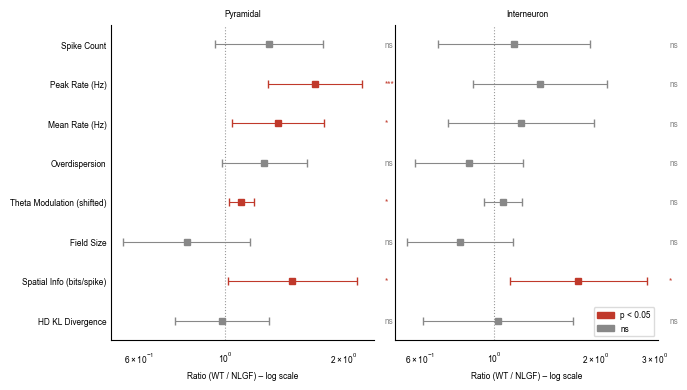

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/glmm_forest_plot_ratios.pdf


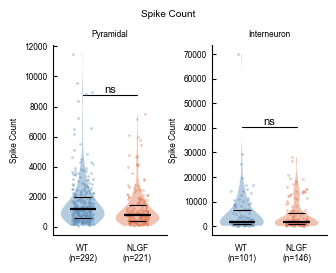

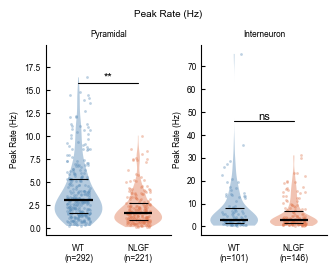

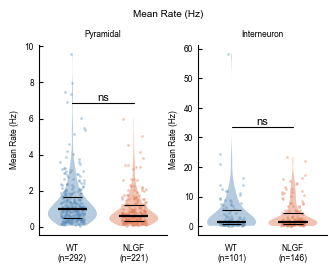

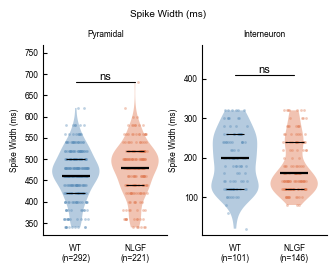

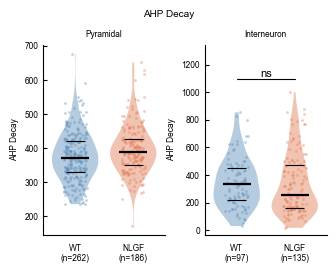

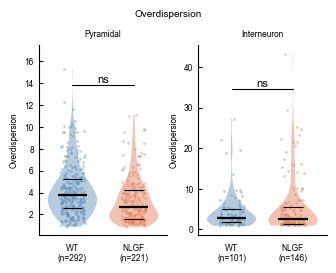

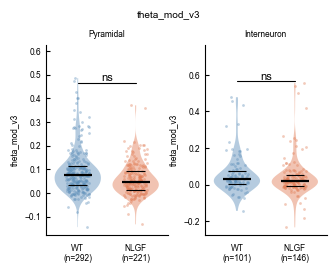

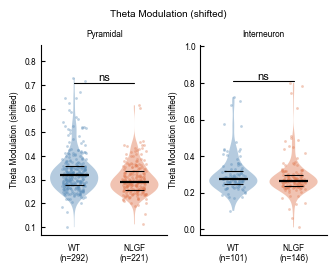

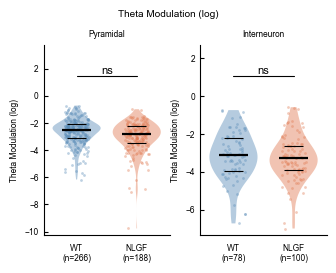

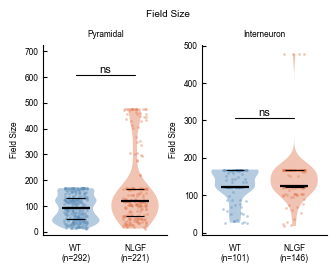

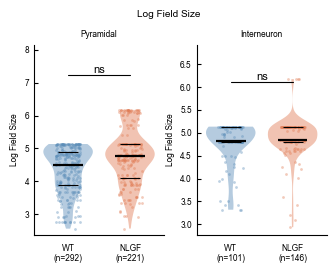

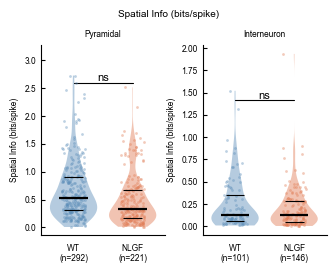

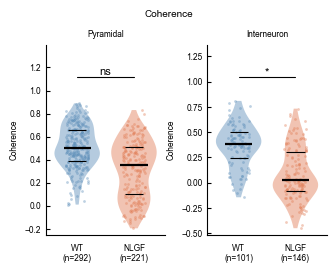

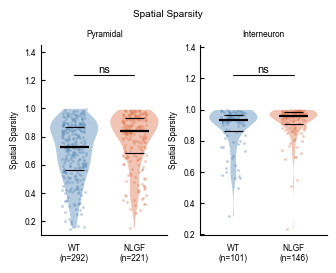

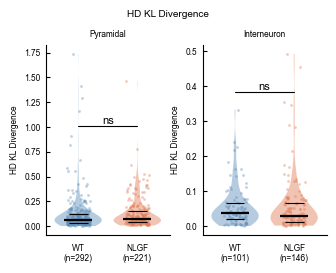

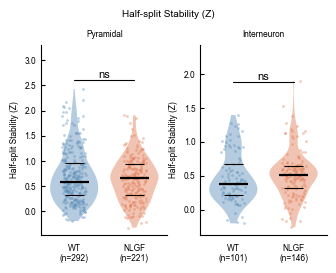

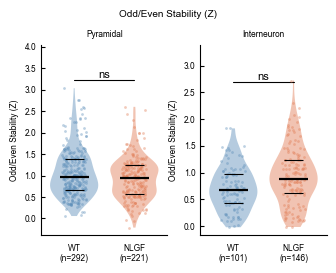

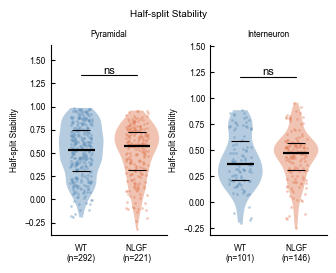

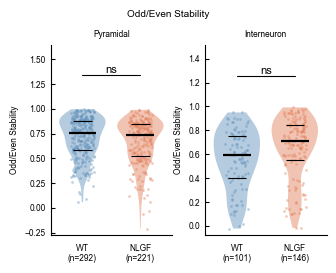

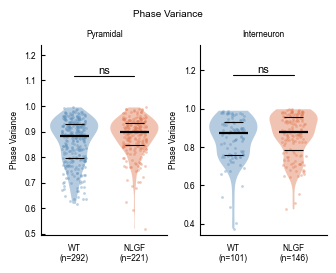

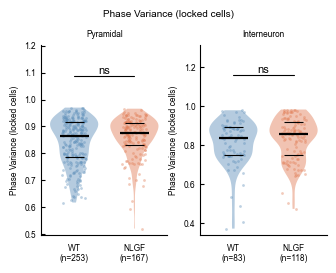

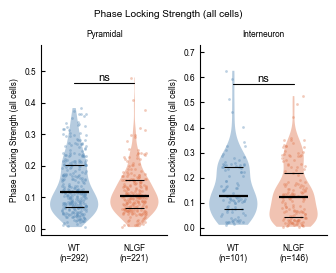

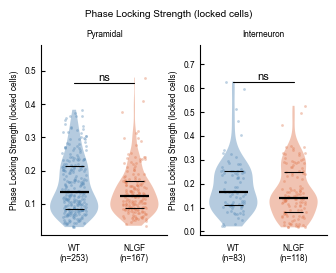

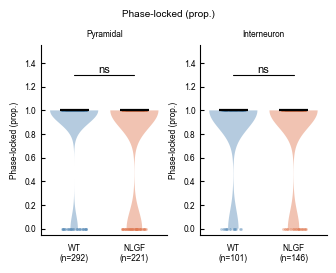

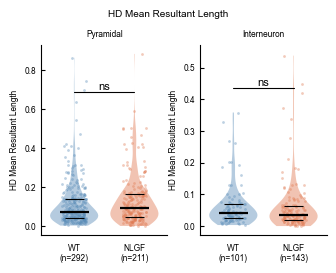

✅ All violin and box plots saved.


In [48]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


METRIC_DISPLAY = {
    "num_spikes":                              "Spike Count",
    "peak_rate":                               "Peak Rate (Hz)",
    "mean_rate":                               "Mean Rate (Hz)",
    "spike_width":                             "Spike Width (ms)",
    "ahp_decay":                               "AHP Decay",
    "overdispersion":                          "Overdispersion",
    "theta_mod_v3_shifted":                    "Theta Modulation (shifted)",
    "theta_mod_v3_log":                        "Theta Modulation (log)",
    "field_size":                              "Field Size",
    "log_field_size":                          "Log Field Size",
    "spatial_info":                            "Spatial Info (bits/spike)",
    "coherence":                               "Coherence",
    "spatial_sparsity":                        "Spatial Sparsity",
    "head_dir_kl_div":                         "HD KL Divergence",
    "half_split_z":                            "Half-split Stability (Z)",
    "odd_even_z":                              "Odd/Even Stability (Z)",
    "half_split_stability":                    "Half-split Stability",
    "odd_even_stability":                      "Odd/Even Stability",
    "phase_variance":                          "Phase Variance",
    "phase_variance_locked_cells":             "Phase Variance (locked cells)",
    "phase_locking_vector_length_locked_cells":"Phase Locking Strength (locked cells)",
    "phase_locking_vector_length":             "Phase Locking Strength (all cells)",
    "phase_locked":                            "Phase-locked (prop.)",
    "head_dir_mean_resultant_length":          "HD Mean Resultant Length",
}

def _pstars(p):
    if pd.isna(p): return ""
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "ns"

METRIC_ORDER = [
    col for col, fam, lnk, lbl, env in METRIC_SPECS
    if env != "open_field" and col in df_linear_track.columns
]
n_ct = len(CELL_TYPES)


# ═══════════════════════════════════════════════════════════════════════════════
# 1.  FOREST PLOT
# ═══════════════════════════════════════════════════════════════════════════════
forest_df = df_summary[df_summary["ratio"].notna()].copy()
forest_df["stars"]  = forest_df["ratio_p_value"].apply(_pstars)
forest_df["is_sig"] = forest_df["ratio_p_value"].fillna(1) < 0.05

forest_metrics = [c for c in METRIC_ORDER if c in forest_df["metric"].values]

if forest_metrics:
    n_rows = len(forest_metrics)
    fig, axes = plt.subplots(
        1, n_ct,
        figsize=(3.35 * n_ct, max(3.0, 0.28 * n_rows + 1.5)),
        sharey=True,
    )
    if n_ct == 1:
        axes = [axes]

    for ax_i, (ax, ct) in enumerate(zip(axes, CELL_TYPES)):
        sub = (
            forest_df[forest_df["cell_type"] == ct]
            .set_index("metric")
            .reindex(forest_metrics)
        )

        for row_i, (metric, row) in enumerate(sub.iterrows()):
            if pd.isna(row.get("ratio")):
                continue
            ratio = float(row["ratio"])
            lo    = max(1e-6, float(row["ratio_lower_CL"]))
            hi    = float(row["ratio_upper_CL"])
            color = "#C0392B" if row["is_sig"] else "#888888"

            ax.errorbar(
                ratio, row_i,
                xerr=[[max(0.0, ratio - lo)], [max(0.0, hi - ratio)]],
                fmt="s", color=color, capsize=3,
                markersize=4, linewidth=0.8, elinewidth=0.8, zorder=3,
            )
            ax.text(
                1.04, row_i, row["stars"],
                transform=ax.get_yaxis_transform(),
                va="center", ha="left",
                color=color,
                fontweight="normal",
            )

        ax.axvline(1.0, color="black", linestyle="dotted", linewidth=0.8, alpha=0.4)
        ax.set_xscale("log")
        ax.set_yticks(range(n_rows))
        if ax_i == 0:
            ax.set_yticklabels([METRIC_DISPLAY.get(m, m) for m in forest_metrics])
        ax.set_ylim(n_rows - 0.5, -0.5)
        ax.set_xlabel("Ratio (WT / NLGF) – log scale")
        ax.set_title(ct)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="x", width=0.8, length=3)
        ax.tick_params(axis="y", width=0.8, length=0)   # no y ticks for forest plot

    axes[-1].legend(
        handles=[
            mpatches.Patch(color="#C0392B", label="p < 0.05"),
            mpatches.Patch(color="#888888", label="ns"),
        ],
        loc="lower right", framealpha=0.7,
    )
    plt.tight_layout(pad=0.2)
    fp = os.path.join(linear_track_OUTDIR, "glmm_forest_plot_ratios.pdf")
    plt.savefig(fp)
    plt.show()
    print(f"Saved: {fp}")
else:
    print("No log-link ratio results in df_summary – skipping forest plot.")


# ═══════════════════════════════════════════════════════════════════════════════
# 2.  VIOLIN + BOX PLOTS  (one figure per metric)
# ═══════════════════════════════════════════════════════════════════════════════
df_plot = df_linear_track[
    df_linear_track["cell_type"].isin(CELL_TYPES) &
    df_linear_track["Genotype"].notna()
].copy()
df_plot["Genotype"] = df_plot["Genotype"].astype(str)
rng_m = np.random.default_rng(42)

def _sig_bracket(ax, genos_ct, vals, col, ct):
    """Draw a significance bracket above the plot."""
    if len(genos_ct) < 2:
        return
    row_s = df_summary[
        (df_summary["metric"] == col) & (df_summary["cell_type"] == ct)
    ]
    if row_s.empty:
        return
    p_val = row_s.iloc[0]["p_fdr"] if pd.notna(row_s.iloc[0]["p_fdr"]) else row_s.iloc[0]["p_value"]
    stars = _pstars(p_val)
    if not stars:
        return
    all_v   = np.concatenate(list(vals.values()))
    y_top   = np.nanquantile(all_v, 0.97)
    y_range = np.nanmax(all_v) - np.nanmin(all_v) or 1.0
    bar_y   = y_top + 0.30 * y_range
    tip_y   = bar_y - 0.0 * y_range
    y_lo, y_hi = ax.get_ylim()
    ax.set_ylim(bottom=y_lo, top=max(y_hi, bar_y + 0.25 * y_range))
    x0, x1 = 0, len(genos_ct) - 1
    ax.plot([x0, x0, x1, x1], [tip_y, bar_y, bar_y, tip_y],
            color="black", linewidth=0.8)
    ax.text(
        (x0 + x1) / 2, bar_y, stars,
        ha="center", va="bottom", fontsize=8,
        fontweight="normal", color="black",
    )

for col in METRIC_ORDER:
    df_m = df_plot[["Genotype", "cell_type", col]].copy()
    df_m[col] = pd.to_numeric(df_m[col], errors="coerce")
    df_m = df_m.dropna(subset=[col])
    if df_m.empty:
        continue

    genos_all = [g for g in GENO_ORDER if g in df_m["Genotype"].values]

    # ── Violin ────────────────────────────────────────────────────────────────
    fig_v, axes_v = plt.subplots(1, n_ct, figsize=(1.6 * n_ct, 2.6), sharey=False)
    if n_ct == 1:
        axes_v = [axes_v]

    for ax, ct in zip(axes_v, CELL_TYPES):
        sub      = df_m[df_m["cell_type"] == ct]
        genos_ct = [g for g in genos_all if g in sub["Genotype"].values]
        if sub.empty or not genos_ct:
            ax.set_visible(False)
            continue

        vals = {g: sub.loc[sub["Genotype"] == g, col].dropna().values for g in genos_ct}

        if all(len(vals[g]) >= 3 for g in genos_ct):
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                parts = ax.violinplot(
                    [vals[g] for g in genos_ct],
                    positions=list(range(len(genos_ct))),
                    showmedians=False, showextrema=False, widths=0.8,
                )
            for i_v, pc in enumerate(parts["bodies"]):
                pc.set_facecolor(GENO_COLORS.get(genos_ct[i_v], "#aaaaaa"))
                pc.set_alpha(0.45)
                pc.set_edgecolor("none")

        for xi, g in enumerate(genos_ct):
            q1  = np.nanpercentile(vals[g], 25)
            med = np.nanmedian(vals[g])
            q3  = np.nanpercentile(vals[g], 75)
            ax.hlines([q1, q3], xi - 0.16, xi + 0.16,
                      colors="black", linewidth=0.8, zorder=7)
            ax.hlines(med, xi - 0.24, xi + 0.24,
                      colors="black", linewidth=1.6, zorder=6)

        for xi, g in enumerate(genos_ct):
            jitter = rng_m.uniform(-0.20, 0.20, size=len(vals[g]))
            ax.scatter(xi + jitter, vals[g],
                       color=GENO_COLORS.get(g, "#aaaaaa"),
                       s=4, alpha=0.4, zorder=5, linewidths=0)

        _sig_bracket(ax, genos_ct, vals, col, ct)

        ax.set_xticks(list(range(len(genos_ct))))
        ax.set_xticklabels([f"{g}\n(n={len(vals[g])})" for g in genos_ct])
        ax.set_xlim(-0.55, len(genos_ct) - 0.45)
        ax.set_ylabel(METRIC_DISPLAY.get(col, col))
        ax.set_title(ct)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="x", width=0.8, length=3)
        ax.tick_params(axis="y", width=0.8, length=3, direction="in")

    fig_v.suptitle(METRIC_DISPLAY.get(col, col))
    plt.tight_layout(pad=0.2, rect=[0, 0, 1, 0.95])
    vp = os.path.join(linear_track_OUTDIR, f"violin_{_safe_filename(col)}.pdf")
    plt.savefig(vp)
    plt.show()
    plt.close(fig_v)

    # # ── Box ───────────────────────────────────────────────────────────────────
    # fig_b, axes_b = plt.subplots(1, n_ct, figsize=(1.6 * n_ct, 2.6), sharey=False)
    # if n_ct == 1:
    #     axes_b = [axes_b]

    # for ax, ct in zip(axes_b, CELL_TYPES):
    #     sub      = df_m[df_m["cell_type"] == ct]
    #     genos_ct = [g for g in genos_all if g in sub["Genotype"].values]
    #     if sub.empty or not genos_ct:
    #         ax.set_visible(False)
    #         continue

    #     vals = {g: sub.loc[sub["Genotype"] == g, col].dropna().values for g in genos_ct}

    #     for xi, g in enumerate(genos_ct):
    #         ax.boxplot(
    #             vals[g], positions=[xi], widths=0.6,
    #             patch_artist=True, manage_ticks=False,
    #             boxprops=dict(facecolor=GENO_COLORS.get(g, "#aaaaaa"),
    #                           alpha=0.55, linewidth=0.8),
    #             medianprops=dict(color="black", linewidth=1.0),
    #             whiskerprops=dict(linewidth=0.8),
    #             capprops=dict(linewidth=0.8),
    #             flierprops=dict(marker=".", markersize=2, alpha=0.25,
    #                             markerfacecolor=GENO_COLORS.get(g, "#aaaaaa"),
    #                             markeredgewidth=0),
    #         )

    #     for xi, g in enumerate(genos_ct):
    #         jitter = rng_m.uniform(-0.20, 0.20, size=len(vals[g]))
    #         ax.scatter(xi + jitter, vals[g],
    #                    color=GENO_COLORS.get(g, "#aaaaaa"),
    #                    s=4, alpha=0.4, zorder=4, linewidths=0)

    #     _sig_bracket(ax, genos_ct, vals, col, ct)

    #     ax.set_xticks(list(range(len(genos_ct))))
    #     ax.set_xticklabels([f"{g}\n(n={len(vals[g])})" for g in genos_ct])
    #     ax.set_xlim(-0.55, len(genos_ct) - 0.45)
    #     ax.set_ylabel(METRIC_DISPLAY.get(col, col))
    #     ax.set_title(ct)
    #     ax.spines["top"].set_visible(False)
    #     ax.spines["right"].set_visible(False)
    #     ax.tick_params(axis="x", width=0.8, length=3)
    #     ax.tick_params(axis="y", width=0.8, length=3, direction="in")

    
    # fig_b.suptitle(METRIC_DISPLAY.get(col, col))
    # plt.tight_layout(pad=0.2, rect=[0, 0, 1, 0.95])
    # bp = os.path.join(linear_track_OUTDIR, f"boxplot_{_safe_filename(col)}.pdf")
    # plt.savefig(bp)
    # plt.show()
    # plt.close(fig_b)

print("✅ All violin and box plots saved.")

# Genotype Analysis using non-parametric tests (Mann-Whitney U). Results are saved in "genotype_nonparametric_summary.csv" in the output directory.

**What this does:**
- Runs Mann-Whitney U (two-sided) comparing WT vs NLGF cell-level values for every metric × environment × cell type combination
- Computes **rank-biserial correlation** as effect size ($r = 1 - \frac{2U}{n_1 n_2}$, positive = NLGF ranks higher)
- Applies **Benjamini-Hochberg FDR correction** across all tests
- Colour-codes both raw and corrected p-values in the output table
- Saves to CSV

In [49]:
# ── Mann-Whitney U tests: WT vs NLGF per metric × environment × cell type ────
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from IPython.display import display, HTML

ENVIRONMENTS = ['linear_track']
CELL_TYPES   = ['Pyramidal', 'Interneuron']
GENOTYPES    = ['WT', 'NLGF']

mwu_rows = []

for (col, family, link, label, env_restrict) in METRIC_SPECS:
    envs = [env_restrict] if env_restrict else ENVIRONMENTS

    for env in envs:
        for ct in CELL_TYPES:
            sub = df_linear_track[
                (df_linear_track['environment'] == env) &
                (df_linear_track['cell_type']   == ct)
            ][[col, 'Genotype']].dropna()

            wt_vals   = sub[sub['Genotype'] == 'WT'  ][col].values
            nlgf_vals = sub[sub['Genotype'] == 'NLGF'][col].values

            if len(wt_vals) < 5 or len(nlgf_vals) < 5:
                continue

            stat, p = mannwhitneyu(wt_vals, nlgf_vals, alternative='two-sided')

            # Rank-biserial correlation as effect size (−1 to +1)
            n1, n2 = len(wt_vals), len(nlgf_vals)
            r_rb = 1 - (2 * stat) / (n1 * n2)

            mwu_rows.append({
                'metric':        col,
                'label':         label,
                'environment':   env,
                'cell_type':     ct,
                'n_WT':          n1,
                'n_NLGF':        n2,
                'median_WT':     round(float(np.median(wt_vals)),   4),
                'median_NLGF':   round(float(np.median(nlgf_vals)), 4),
                'U_statistic':   round(stat, 2),
                'p_raw':         p,
                'effect_r':      round(r_rb, 4),
            })

df_mwu = pd.DataFrame(mwu_rows)

# FDR correction (Benjamini-Hochberg) across all tests
reject, p_fdr, _, _ = multipletests(df_mwu['p_raw'], method='fdr_bh')
df_mwu['p_fdr']  = p_fdr
df_mwu['sig_raw'] = df_mwu['p_raw'].apply(sig_label)
df_mwu['sig_fdr'] = df_mwu['p_fdr'].apply(sig_label)

# ── Display ───────────────────────────────────────────────────────────────────
def _colour_p(p):
    if p < 0.001: return 'background-color:#c62828;color:white;font-weight:bold'
    if p < 0.01:  return 'background-color:#ef5350;color:white;font-weight:bold'
    if p < 0.05:  return 'background-color:#ffcc80;color:black;font-weight:bold'
    return ''

display(HTML("<h3>Mann-Whitney U: WT vs NLGF per metric × environment × cell type</h3>"
             "<p>Effect size = rank-biserial r (positive = NLGF > WT ranks). "
             "p_fdr = Benjamini-Hochberg corrected.</p>"))

display(
    df_mwu.style
        .applymap(_colour_p, subset=['p_raw', 'p_fdr'])
        .format({
            'median_WT':   '{:.4f}',
            'median_NLGF': '{:.4f}',
            'U_statistic': '{:.1f}',
            'p_raw':       '{:.4f}',
            'p_fdr':       '{:.4f}',
            'effect_r':    '{:.3f}',
        })
)

# Save
mwu_path = os.path.join(linear_track_OUTDIR,
    'mannwhitney_WT_vs_NLGF_per_celltype.csv')
df_mwu.to_csv(mwu_path, index=False)
print(f"\n✅ Saved: {mwu_path}")
print(f"   {len(df_mwu)} tests | {(df_mwu['p_raw'] < 0.05).sum()} significant raw | "
      f"{(df_mwu['p_fdr'] < 0.05).sum()} significant FDR-corrected")

,metric,label,environment,cell_type,n_WT,n_NLGF,median_WT,median_NLGF,U_statistic,p_raw,effect_r,p_fdr,sig_raw,sig_fdr
0,num_spikes,Negative Binomial,linear_track,Pyramidal,292,221,1147.0000,747.0000,39685.0,0.0000,-0.230,0.0000,***,***
1,num_spikes,Negative Binomial,linear_track,Interneuron,101,146,1840.0000,1754.0000,7343.5,0.9581,0.004,0.9581,ns,ns
2,peak_rate,Gamma,linear_track,Pyramidal,292,221,3.0918,1.6942,45231.0,0.0000,-0.402,0.0000,***,***
3,peak_rate,Gamma,linear_track,Interneuron,101,146,2.9056,2.8731,8008.0,0.2504,-0.086,0.3182,ns,ns
4,mean_rate,Gamma,linear_track,Pyramidal,292,221,0.9546,0.6173,40235.0,0.0000,-0.247,0.0000,***,***
5,mean_rate,Gamma,linear_track,Interneuron,101,146,1.5321,1.4590,7435.0,0.9113,-0.008,0.9384,ns,ns
6,spike_width,Gaussian,linear_track,Pyramidal,292,221,460.0000,480.0000,28312.5,0.0168,0.122,0.0400,*,*
7,spike_width,Gaussian,linear_track,Interneuron,101,146,200.0000,160.0000,8513.5,0.0377,-0.155,0.0857,*,ns
8,ahp_decay,Gaussian,linear_track,Pyramidal,262,186,372.5041,387.7735,20384.5,0.0032,0.163,0.0094,**,**
9,ahp_decay,Gaussian,linear_track,Interneuron,97,135,330.9023,256.7159,7175.5,0.2133,-0.096,0.2963,ns,ns



✅ Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/mannwhitney_WT_vs_NLGF_per_celltype.csv
   50 tests | 22 significant raw | 21 significant FDR-corrected


**Comparison of GLMM and Mann-Whiteny data**

| Section | Detail |
|---|---|
| **Join** | `metric × cell_type` on linear_track only (GLMM doesn't stratify by environment) |
| **✅ both** | GLMM `p_value < 0.05` AND MWU `p_raw < 0.05` — strongest evidence |
| **GLMM only** | Parametric model detects it but rank test doesn't — possible due to GLMM modelling random effects / leveraging distributional assumptions |
| **MWU only** | Rank test detects it but GLMM doesn't — may indicate the assumption violation in the GLMM |
| **— neither** | No evidence in either test |

The table is colour-coded green (both significant), yellow (one only), white (neither). Also saved to `glmm_vs_mwu_concordance.csv`.

## Compare GLMM vs Mann-Whitney U

In [50]:
# ── Compare GLMM vs Mann-Whitney U: concordance of significance ───────────────
from IPython.display import display, HTML

ALPHA = 0.05

# GLMM: use emmeans p_value; filter to converged models only
glmm = df_summary[df_summary["converged"] == True][
    ["metric", "cell_type", "estimate", "lower_CL", "upper_CL", "p_value", "n", "n_mice"]
].copy()
glmm = glmm.rename(columns={
    "estimate": "glmm_estimate",
    "lower_CL": "glmm_lower_CL",
    "upper_CL": "glmm_upper_CL",
    "p_value":  "glmm_p",
    "n":        "glmm_n",
    "n_mice":   "glmm_n_mice",
})
glmm["glmm_sig"] = glmm["glmm_p"] < ALPHA

# MWU: use linear_track only (GLMM was fit on open-field data)
mwu = df_mwu[df_mwu["environment"] == "linear_track"][
    ["metric", "cell_type", "n_WT", "n_NLGF", "median_WT", "median_NLGF",
     "U_statistic", "p_raw", "p_fdr", "effect_r"]
].copy()
mwu = mwu.rename(columns={
    "p_raw": "mwu_p_raw",
    "p_fdr": "mwu_p_fdr",
})
mwu["mwu_sig"] = mwu["mwu_p_raw"] < ALPHA

# Merge on metric × cell_type
comp = pd.merge(
    glmm, mwu,
    on=["metric", "cell_type"],
    how="outer",
    indicator=True,
)

# Classification
def classify(row):
    g = bool(row.get("glmm_sig"))  if pd.notna(row.get("glmm_sig"))  else False
    m = bool(row.get("mwu_sig"))   if pd.notna(row.get("mwu_sig"))   else False
    if g and m:
        return "✅ both"
    elif g:
        return "GLMM only"
    elif m:
        return "MWU only"
    else:
        return "— neither"

comp["concordance"] = comp.apply(classify, axis=1)

# sig stars helper
def _fmt_p(p):
    if pd.isna(p):    return "—"
    if p < 0.001:     return f"{p:.4f} ***"
    if p < 0.01:      return f"{p:.4f} **"
    if p < 0.05:      return f"{p:.4f} *"
    return f"{p:.4f}"

# ── Display: summary by concordance ──────────────────────────────────────────
display(HTML("<h3>GLMM vs Mann-Whitney U — concordance of significance (open field, p&lt;0.05)</h3>"))

for label, grp in comp.groupby("concordance", sort=False):
    if grp.empty:
        continue
    display(HTML(f"<h4>{label} ({len(grp)} comparisons)</h4>"))
    show = grp[[
        "metric", "cell_type",
        "glmm_p", "glmm_estimate", "glmm_lower_CL", "glmm_upper_CL",
        "mwu_p_raw", "mwu_p_fdr", "effect_r",
    ]].sort_values(["cell_type", "metric"])

    def _colour_row(row):
        g  = row.get("glmm_p",    np.nan)
        m  = row.get("mwu_p_raw", np.nan)
        g_sig = pd.notna(g) and g < ALPHA
        m_sig = pd.notna(m) and m < ALPHA
        if g_sig and m_sig:   bg = "#c8e6c9"   # green
        elif g_sig or m_sig:  bg = "#fff9c4"   # yellow
        else:                 bg = ""
        return [f"background-color:{bg}" if bg else "" for _ in row]

    display(
        show.style
            .apply(_colour_row, axis=1)
            .format({
                "glmm_p":        _fmt_p,
                "glmm_estimate": "{:.4f}",
                "glmm_lower_CL": "{:.4f}",
                "glmm_upper_CL": "{:.4f}",
                "mwu_p_raw":     _fmt_p,
                "mwu_p_fdr":     _fmt_p,
                "effect_r":      "{:.3f}",
            })
            .set_properties(**{"font-size": "11px"})
    )

# ── Print a quick count summary ───────────────────────────────────────────────
print("\n── Concordance counts ──────────────────────────────────────────────────")
print(comp["concordance"].value_counts().to_string())

# ── Save ──────────────────────────────────────────────────────────────────────
comp_path = os.path.join(linear_track_OUTDIR, "glmm_vs_mwu_concordance.csv")
comp[["metric", "cell_type", "glmm_p", "glmm_estimate", "glmm_lower_CL", "glmm_upper_CL",
      "glmm_n", "glmm_n_mice", "mwu_p_raw", "mwu_p_fdr", "effect_r",
      "n_WT", "n_NLGF", "median_WT", "median_NLGF", "concordance"]
].to_csv(comp_path, index=False)
print(f"\n✅ Saved: {comp_path}")

,metric,cell_type,glmm_p,glmm_estimate,glmm_lower_CL,glmm_upper_CL,mwu_p_raw,mwu_p_fdr,effect_r
0,ahp_decay,Interneuron,—,nan,nan,nan,0.2133,0.2963,-0.096
4,field_size,Interneuron,0.2069,-0.2328,-0.5943,0.1287,0.9196,0.9384,0.008
6,half_split_stability,Interneuron,0.7756,-0.0251,-0.1974,0.1473,0.0748,0.1290,0.134
8,half_split_z,Interneuron,0.8231,-0.0293,-0.2865,0.2278,0.0748,0.1290,0.134
10,head_dir_kl_div,Interneuron,0.9145,0.0282,-0.4866,0.5430,0.2542,0.3182,-0.085
12,head_dir_mean_resultant_length,Interneuron,0.3378,0.1009,-0.1054,0.3072,0.2582,0.3182,-0.085
14,log_field_size,Interneuron,0.1687,-0.2555,-0.6193,0.1083,0.9196,0.9384,0.008
16,mean_rate,Interneuron,0.4745,0.1819,-0.3166,0.6803,0.9113,0.9384,-0.008
18,num_spikes,Interneuron,0.6013,0.1383,-0.3806,0.6573,0.9581,0.9581,0.004
24,overdispersion,Interneuron,0.3639,-0.1703,-0.5381,0.1974,0.4103,0.4771,-0.062


,metric,cell_type,glmm_p,glmm_estimate,glmm_lower_CL,glmm_upper_CL,mwu_p_raw,mwu_p_fdr,effect_r
20,odd_even_stability,Interneuron,0.6091,-0.0486,-0.2349,0.1377,0.0007 ***,0.0025 **,0.253
22,odd_even_z,Interneuron,0.5462,-0.1039,-0.4416,0.2337,0.0007 ***,0.0025 **,0.253
1,ahp_decay,Pyramidal,—,nan,nan,nan,0.0032 **,0.0094 **,0.163
5,field_size,Pyramidal,0.2346,-0.2267,-0.6007,0.1472,0.0000 ***,0.0000 ***,0.237
15,log_field_size,Pyramidal,0.1860,-0.2672,-0.6632,0.1288,0.0000 ***,0.0000 ***,0.237
19,num_spikes,Pyramidal,0.1108,0.2581,-0.0592,0.5755,0.0000 ***,0.0000 ***,-0.230
25,overdispersion,Pyramidal,0.0718,0.2294,-0.0203,0.4791,0.0000 ***,0.0000 ***,-0.280
31,phase_locking_vector_length,Pyramidal,0.4556,0.1649,-0.2683,0.5980,0.0163 *,0.0400 *,-0.124
35,phase_variance,Pyramidal,0.4556,-0.1649,-0.5980,0.2683,0.0163 *,0.0400 *,0.124
43,spike_width,Pyramidal,—,nan,nan,nan,0.0168 *,0.0400 *,0.122


,metric,cell_type,glmm_p,glmm_estimate,glmm_lower_CL,glmm_upper_CL,mwu_p_raw,mwu_p_fdr,effect_r
2,coherence,Interneuron,0.0020 **,0.2873,0.1052,0.4694,0.0000 ***,0.0000 ***,-0.590
40,spatial_sparsity,Interneuron,0.0369 *,-0.3858,-0.7482,-0.0234,0.0042 **,0.0116 *,0.215
42,spike_width,Interneuron,0.0292 *,19.1423,1.9329,36.3517,0.0377 *,0.0857,-0.155
3,coherence,Pyramidal,0.0059 **,0.1983,0.0570,0.3395,0.0000 ***,0.0000 ***,-0.432
17,mean_rate,Pyramidal,0.0250 *,0.3080,0.0387,0.5774,0.0000 ***,0.0000 ***,-0.247
27,peak_rate,Pyramidal,0.0002 ***,0.5283,0.2509,0.8057,0.0000 ***,0.0000 ***,-0.402
29,phase_locked,Pyramidal,0.0148 *,0.7874,0.1545,1.4204,0.0013 **,0.0040 **,-0.111
39,spatial_info,Pyramidal,0.0409 *,0.3942,0.0162,0.7722,0.0000 ***,0.0000 ***,-0.254
41,spatial_sparsity,Pyramidal,0.0232 *,-0.3878,-0.7225,-0.0531,0.0000 ***,0.0000 ***,0.262
45,theta_mod_v3,Pyramidal,0.0127 *,0.0301,0.0064,0.0538,0.0000 ***,0.0002 ***,-0.212


,metric,cell_type,glmm_p,glmm_estimate,glmm_lower_CL,glmm_upper_CL,mwu_p_raw,mwu_p_fdr,effect_r
38,spatial_info,Interneuron,0.0151 *,0.5771,0.1114,1.0428,0.2006,0.2866,-0.096



── Concordance counts ──────────────────────────────────────────────────
concordance
— neither    27
✅ both       12
MWU only     10
GLMM only     1

✅ Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/glmm_vs_mwu_concordance.csv


## Plots for MWU test 

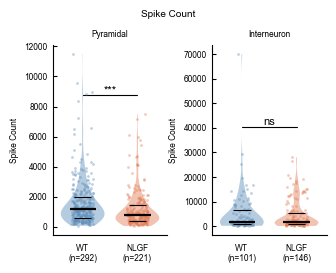

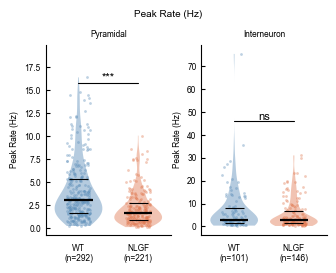

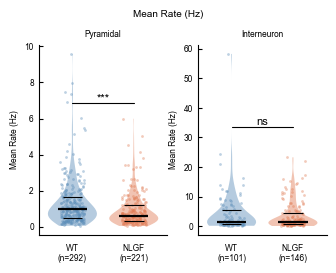

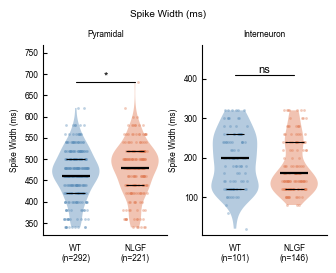

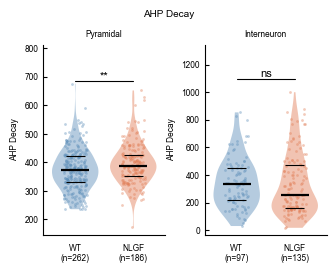

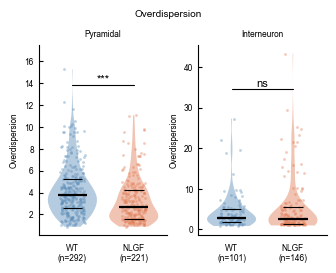

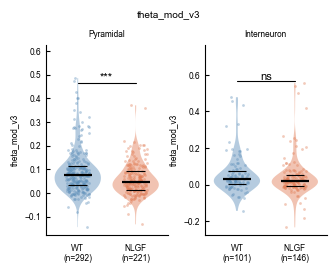

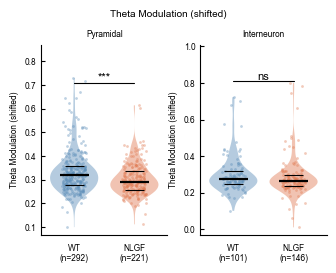

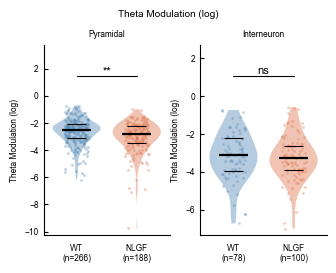

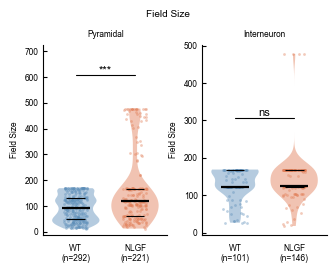

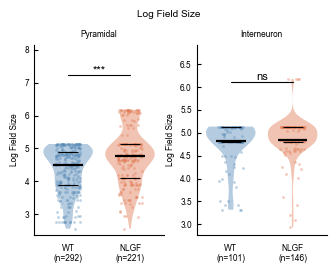

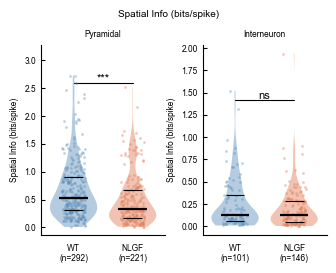

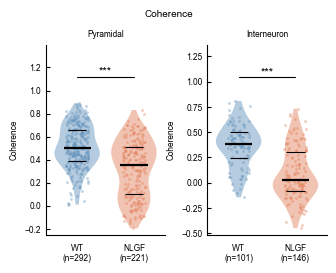

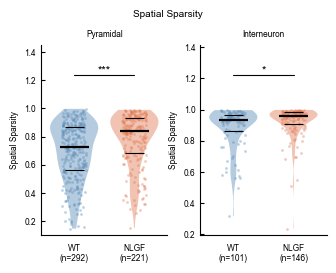

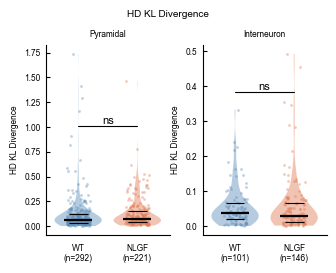

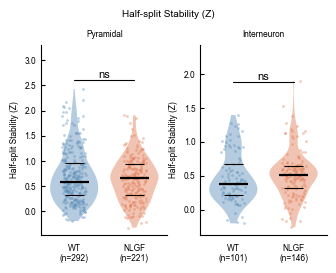

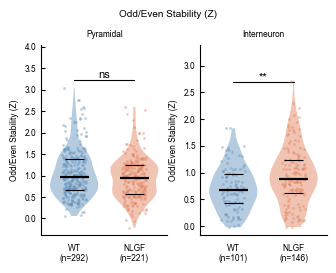

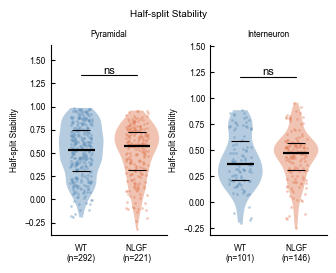

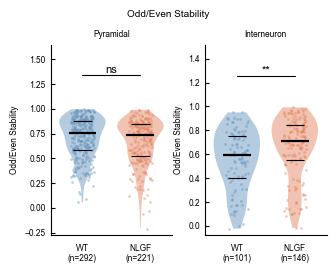

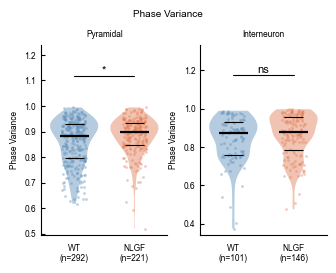

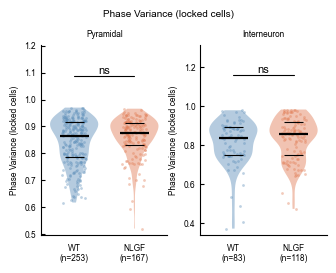

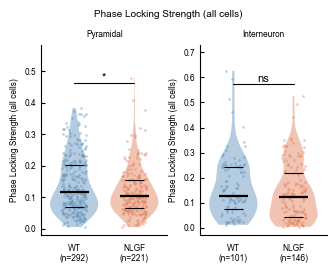

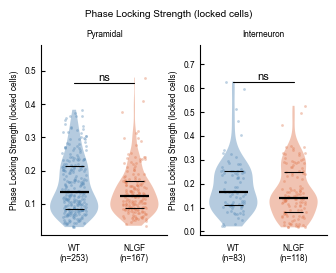

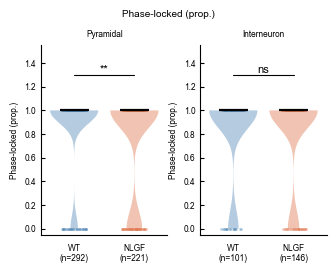

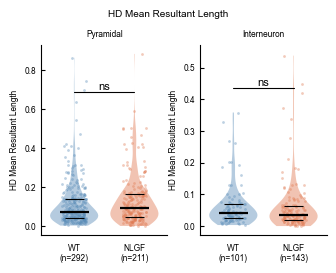

✅ All violin and box plots saved.


In [51]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


METRIC_DISPLAY = {
    "num_spikes":                              "Spike Count",
    "peak_rate":                               "Peak Rate (Hz)",
    "mean_rate":                               "Mean Rate (Hz)",
    "spike_width":                             "Spike Width (ms)",
    "ahp_decay":                               "AHP Decay",
    "overdispersion":                          "Overdispersion",
    "theta_mod_v3_shifted":                    "Theta Modulation (shifted)",
    "theta_mod_v3_log":                        "Theta Modulation (log)",
    "field_size":                              "Field Size",
    "log_field_size":                          "Log Field Size",
    "spatial_info":                            "Spatial Info (bits/spike)",
    "coherence":                               "Coherence",
    "spatial_sparsity":                        "Spatial Sparsity",
    "head_dir_kl_div":                         "HD KL Divergence",
    "half_split_z":                            "Half-split Stability (Z)",
    "odd_even_z":                              "Odd/Even Stability (Z)",
    "half_split_stability":                    "Half-split Stability",
    "odd_even_stability":                      "Odd/Even Stability",
    "phase_variance":                          "Phase Variance",
    "phase_variance_locked_cells":             "Phase Variance (locked cells)",
    "phase_locking_vector_length_locked_cells":"Phase Locking Strength (locked cells)",
    "phase_locking_vector_length":             "Phase Locking Strength (all cells)",
    "phase_locked":                            "Phase-locked (prop.)",
    "head_dir_mean_resultant_length":          "HD Mean Resultant Length",
}

def _pstars(p):
    if pd.isna(p): return ""
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "ns"

METRIC_ORDER = [
    col for col, fam, lnk, lbl, env in METRIC_SPECS
    if env != "open_field" and col in df_linear_track.columns
]
n_ct = len(CELL_TYPES)


# ═══════════════════════════════════════════════════════════════════════════════
# 1.  VIOLIN + BOX PLOTS  (one figure per metric)
# ═══════════════════════════════════════════════════════════════════════════════
df_plot = df_linear_track[
    df_linear_track["cell_type"].isin(CELL_TYPES) &
    df_linear_track["Genotype"].notna()
].copy()
df_plot["Genotype"] = df_plot["Genotype"].astype(str)
rng_m = np.random.default_rng(42)

def _sig_bracket(ax, genos_ct, vals, col, ct):
    """Draw a significance bracket above the plot."""
    if len(genos_ct) < 2:
        return
    row_s = df_mwu[
        (df_mwu["metric"] == col) & (df_mwu["cell_type"] == ct)
    ]
    if row_s.empty:
        return
    p_val = row_s.iloc[0]["p_fdr"]  # use FDR-corrected p-value for annotation
    stars = _pstars(p_val)
    if not stars:
        return
    all_v   = np.concatenate(list(vals.values()))
    y_top   = np.nanquantile(all_v, 0.97)
    y_range = np.nanmax(all_v) - np.nanmin(all_v) or 1.0
    bar_y   = y_top + 0.30 * y_range
    tip_y   = bar_y - 0.0 * y_range
    y_lo, y_hi = ax.get_ylim()
    ax.set_ylim(bottom=y_lo, top=max(y_hi, bar_y + 0.25 * y_range))
    x0, x1 = 0, len(genos_ct) - 1
    ax.plot([x0, x0, x1, x1], [tip_y, bar_y, bar_y, tip_y],
            color="black", linewidth=0.8)
    ax.text(
        (x0 + x1) / 2, bar_y, stars,
        ha="center", va="bottom", fontsize=8,
        fontweight="normal", color="black",
    )

for col in METRIC_ORDER:
    df_m = df_plot[["Genotype", "cell_type", col]].copy()
    df_m[col] = pd.to_numeric(df_m[col], errors="coerce")
    df_m = df_m.dropna(subset=[col])
    if df_m.empty:
        continue

    genos_all = [g for g in GENO_ORDER if g in df_m["Genotype"].values]

    # ── Violin ────────────────────────────────────────────────────────────────
    fig_v, axes_v = plt.subplots(1, n_ct, figsize=(1.6 * n_ct, 2.6), sharey=False)
    if n_ct == 1:
        axes_v = [axes_v]

    for ax, ct in zip(axes_v, CELL_TYPES):
        sub      = df_m[df_m["cell_type"] == ct]
        genos_ct = [g for g in genos_all if g in sub["Genotype"].values]
        if sub.empty or not genos_ct:
            ax.set_visible(False)
            continue

        vals = {g: sub.loc[sub["Genotype"] == g, col].dropna().values for g in genos_ct}

        if all(len(vals[g]) >= 3 for g in genos_ct):
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                parts = ax.violinplot(
                    [vals[g] for g in genos_ct],
                    positions=list(range(len(genos_ct))),
                    showmedians=False, showextrema=False, widths=0.8,
                )
            for i_v, pc in enumerate(parts["bodies"]):
                pc.set_facecolor(GENO_COLORS.get(genos_ct[i_v], "#aaaaaa"))
                pc.set_alpha(0.45)
                pc.set_edgecolor("none")

        for xi, g in enumerate(genos_ct):
            q1  = np.nanpercentile(vals[g], 25)
            med = np.nanmedian(vals[g])
            q3  = np.nanpercentile(vals[g], 75)
            ax.hlines([q1, q3], xi - 0.16, xi + 0.16,
                      colors="black", linewidth=0.8, zorder=7)
            ax.hlines(med, xi - 0.24, xi + 0.24,
                      colors="black", linewidth=1.6, zorder=6)

        for xi, g in enumerate(genos_ct):
            jitter = rng_m.uniform(-0.20, 0.20, size=len(vals[g]))
            ax.scatter(xi + jitter, vals[g],
                       color=GENO_COLORS.get(g, "#aaaaaa"),
                       s=4, alpha=0.4, zorder=5, linewidths=0)

        _sig_bracket(ax, genos_ct, vals, col, ct)

        ax.set_xticks(list(range(len(genos_ct))))
        ax.set_xticklabels([f"{g}\n(n={len(vals[g])})" for g in genos_ct])
        ax.set_xlim(-0.55, len(genos_ct) - 0.45)
        ax.set_ylabel(METRIC_DISPLAY.get(col, col))
        ax.set_title(ct)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="x", width=0.8, length=3)
        ax.tick_params(axis="y", width=0.8, length=3, direction="in")

    fig_v.suptitle(METRIC_DISPLAY.get(col, col))
    plt.tight_layout(pad=0.2, rect=[0, 0, 1, 0.95])
    vp = os.path.join(linear_track_OUTDIR, f"violin_{_safe_filename(col)}_MWU.pdf")
    plt.savefig(vp)
    plt.show()
    plt.close(fig_v)

    # # ── Box ───────────────────────────────────────────────────────────────────
    # fig_b, axes_b = plt.subplots(1, n_ct, figsize=(1.6 * n_ct, 2.6), sharey=True)
    # if n_ct == 1:
    #     axes_b = [axes_b]

    # for ax, ct in zip(axes_b, CELL_TYPES):
    #     sub      = df_m[df_m["cell_type"] == ct]
    #     genos_ct = [g for g in genos_all if g in sub["Genotype"].values]
    #     if sub.empty or not genos_ct:
    #         ax.set_visible(False)
    #         continue

    #     vals = {g: sub.loc[sub["Genotype"] == g, col].dropna().values for g in genos_ct}

    #     for xi, g in enumerate(genos_ct):
    #         ax.boxplot(
    #             vals[g], positions=[xi], widths=0.6,
    #             patch_artist=True, manage_ticks=False,
    #             boxprops=dict(facecolor=GENO_COLORS.get(g, "#aaaaaa"),
    #                           alpha=0.55, linewidth=0.8),
    #             medianprops=dict(color="black", linewidth=1.0),
    #             whiskerprops=dict(linewidth=0.8),
    #             capprops=dict(linewidth=0.8),
    #             flierprops=dict(marker=".", markersize=2, alpha=0.25,
    #                             markerfacecolor=GENO_COLORS.get(g, "#aaaaaa"),
    #                             markeredgewidth=0),
    #         )

    #     for xi, g in enumerate(genos_ct):
    #         jitter = rng_m.uniform(-0.20, 0.20, size=len(vals[g]))
    #         ax.scatter(xi + jitter, vals[g],
    #                    color=GENO_COLORS.get(g, "#aaaaaa"),
    #                    s=4, alpha=0.4, zorder=4, linewidths=0)

    #     _sig_bracket(ax, genos_ct, vals, col, ct)

    #     ax.set_xticks(list(range(len(genos_ct))))
    #     ax.set_xticklabels([f"{g}\n(n={len(vals[g])})" for g in genos_ct])
    #     ax.set_xlim(-0.55, len(genos_ct) - 0.45)
    #     ax.set_ylabel(METRIC_DISPLAY.get(col, col))
    #     ax.set_title(ct)
    #     ax.spines["top"].set_visible(False)
    #     ax.spines["right"].set_visible(False)
    #     ax.tick_params(axis="x", width=0.8, length=3)
    #     ax.tick_params(axis="y", width=0.8, length=3, direction="in")

    
    # fig_b.suptitle(METRIC_DISPLAY.get(col, col))
    # plt.tight_layout(pad=0.2, rect=[0, 0, 1, 0.95])
    # bp = os.path.join(linear_track_OUTDIR, f"boxplot_{_safe_filename(col)}.pdf")
    # plt.savefig(bp)
    # plt.show()
    # plt.close(fig_b)

print("✅ All violin and box plots saved.")

## Mann-Whitney test only on spatial cells 

In [52]:
# ── Mann-Whitney U tests: WT vs NLGF per metric × environment × cell type ────
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from IPython.display import display, HTML

ENVIRONMENTS = ['linear_track']
CELL_TYPES   = ['Pyramidal', 'Interneuron']
GENOTYPES    = ['WT', 'NLGF']
df_spatial_cells = df_linear_track[df_linear_track["is_spatial"] == True].copy()

#Save original df_spatial_cells for later use
df_spatial_cells.to_csv(os.path.join(linear_track_OUTDIR, "spatial_cells_linear_track.csv"), index=False)


mwu_rows = []

for (col, family, link, label, env_restrict) in METRIC_SPECS:
    envs = [env_restrict] if env_restrict else ENVIRONMENTS

    for env in envs:
        for ct in CELL_TYPES:
            sub = df_spatial_cells[
                (df_spatial_cells['environment'] == env) &
                (df_spatial_cells['cell_type']   == ct)
            ][[col, 'Genotype']].dropna()

            wt_vals   = sub[sub['Genotype'] == 'WT'  ][col].values
            nlgf_vals = sub[sub['Genotype'] == 'NLGF'][col].values

            if len(wt_vals) < 5 or len(nlgf_vals) < 5:
                continue

            stat, p = mannwhitneyu(wt_vals, nlgf_vals, alternative='two-sided')

            # Rank-biserial correlation as effect size (−1 to +1)
            n1, n2 = len(wt_vals), len(nlgf_vals)
            r_rb = 1 - (2 * stat) / (n1 * n2)

            mwu_rows.append({
                'metric':        col,
                'label':         label,
                'environment':   env,
                'cell_type':     ct,
                'n_WT':          n1,
                'n_NLGF':        n2,
                'median_WT':     round(float(np.median(wt_vals)),   4),
                'median_NLGF':   round(float(np.median(nlgf_vals)), 4),
                'U_statistic':   round(stat, 2),
                'p_raw':         p,
                'effect_r':      round(r_rb, 4),
            })

df_mwu = pd.DataFrame(mwu_rows)

# FDR correction (Benjamini-Hochberg) across all tests
reject, p_fdr, _, _ = multipletests(df_mwu['p_raw'], method='fdr_bh')
df_mwu['p_fdr']  = p_fdr
df_mwu['sig_raw'] = df_mwu['p_raw'].apply(sig_label)
df_mwu['sig_fdr'] = df_mwu['p_fdr'].apply(sig_label)

# ── Display ───────────────────────────────────────────────────────────────────
def _colour_p(p):
    if p < 0.001: return 'background-color:#c62828;color:white;font-weight:bold'
    if p < 0.01:  return 'background-color:#ef5350;color:white;font-weight:bold'
    if p < 0.05:  return 'background-color:#ffcc80;color:black;font-weight:bold'
    return ''

display(HTML("<h3>Mann-Whitney U: WT vs NLGF per metric × environment × cell type</h3>"
             "<p>Effect size = rank-biserial r (positive = NLGF > WT ranks). "
             "p_fdr = Benjamini-Hochberg corrected.</p>"))

display(
    df_mwu.style
        .applymap(_colour_p, subset=['p_raw', 'p_fdr'])
        .format({
            'median_WT':   '{:.4f}',
            'median_NLGF': '{:.4f}',
            'U_statistic': '{:.1f}',
            'p_raw':       '{:.4f}',
            'p_fdr':       '{:.4f}',
            'effect_r':    '{:.3f}',
        })
)

# Save
mwu_path = os.path.join(linear_track_OUTDIR,
    'mannwhitney_WT_vs_NLGF_per_celltype_spatial_cells.csv')
df_mwu.to_csv(mwu_path, index=False)
print(f"\n✅ Saved: {mwu_path}")
print(f"   {len(df_mwu)} tests | {(df_mwu['p_raw'] < 0.05).sum()} significant raw | "
      f"{(df_mwu['p_fdr'] < 0.05).sum()} significant FDR-corrected")

,metric,label,environment,cell_type,n_WT,n_NLGF,median_WT,median_NLGF,U_statistic,p_raw,effect_r,p_fdr,sig_raw,sig_fdr
0,num_spikes,Negative Binomial,linear_track,Pyramidal,132,67,778.0000,446.0000,6098.5,0.0000,-0.379,0.0002,***,***
1,num_spikes,Negative Binomial,linear_track,Interneuron,12,8,596.5000,535.5000,53.0,0.7345,-0.104,0.8199,ns,ns
2,peak_rate,Gamma,linear_track,Pyramidal,132,67,3.0055,1.6942,6168.0,0.0000,-0.395,0.0002,***,***
3,peak_rate,Gamma,linear_track,Interneuron,12,8,2.1155,1.9010,54.0,0.6784,-0.125,0.8199,ns,ns
4,mean_rate,Gamma,linear_track,Pyramidal,132,67,0.6473,0.3710,6101.5,0.0000,-0.380,0.0002,***,***
5,mean_rate,Gamma,linear_track,Interneuron,12,8,0.4967,0.4455,53.0,0.7345,-0.104,0.8199,ns,ns
6,spike_width,Gaussian,linear_track,Pyramidal,132,67,480.0000,480.0000,4258.0,0.6683,0.037,0.8199,ns,ns
7,spike_width,Gaussian,linear_track,Interneuron,12,8,220.0000,240.0000,38.5,0.4850,0.198,0.7677,ns,ns
8,ahp_decay,Gaussian,linear_track,Pyramidal,124,58,343.7621,384.7787,2844.5,0.0233,0.209,0.0862,*,ns
9,ahp_decay,Gaussian,linear_track,Interneuron,10,8,393.1544,453.3002,28.0,0.3154,0.300,0.6335,ns,ns



✅ Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/LinearTrackAnalysis/mannwhitney_WT_vs_NLGF_per_celltype_spatial_cells.csv
   48 tests | 13 significant raw | 10 significant FDR-corrected


## Plots for MWU test (spatial cells only) 

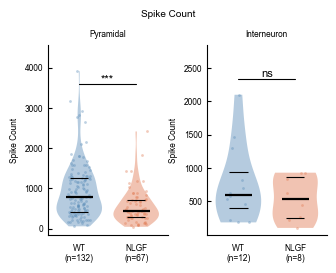

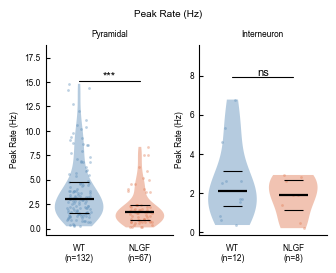

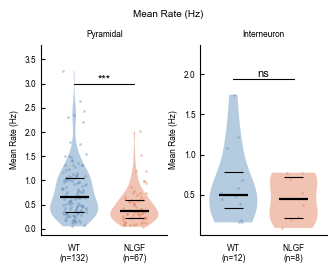

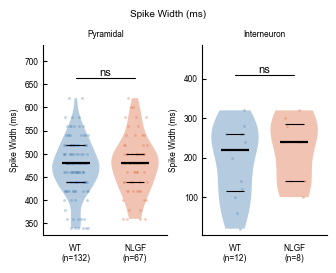

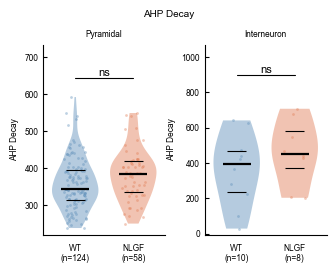

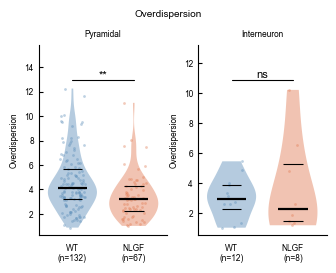

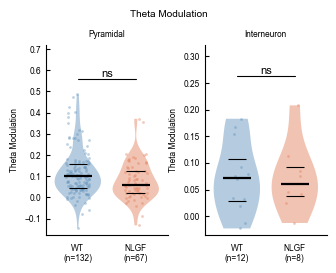

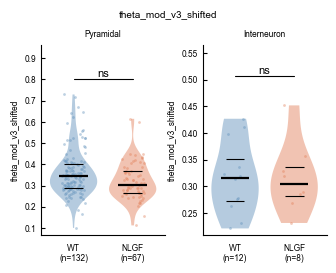

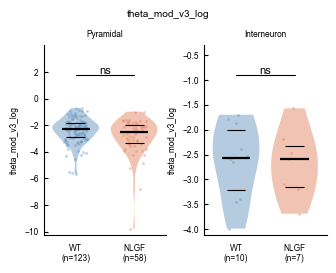

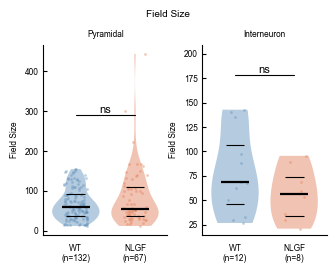

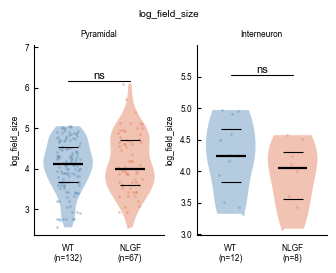

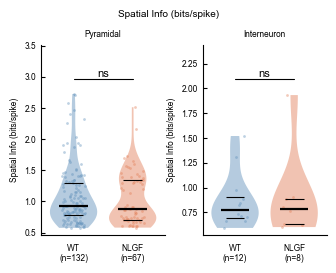

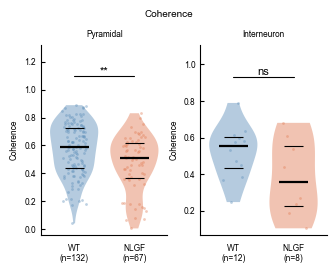

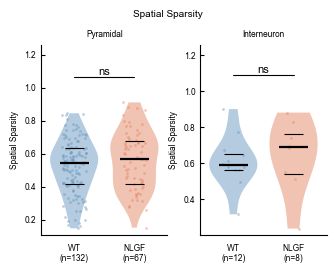

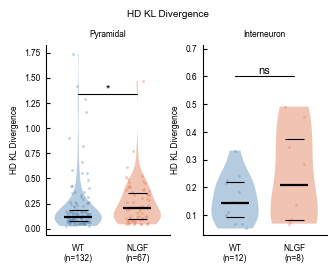

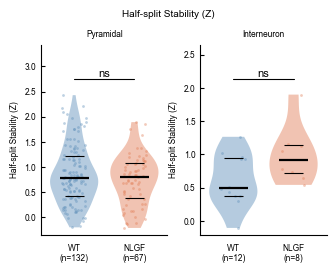

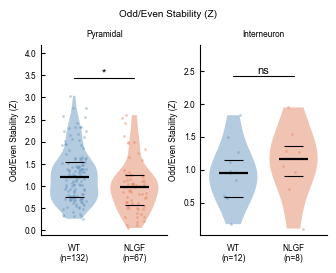

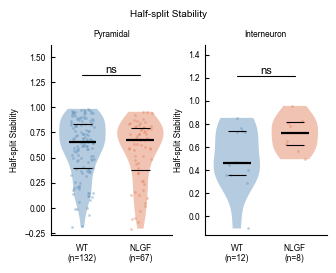

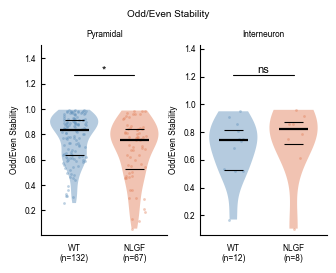

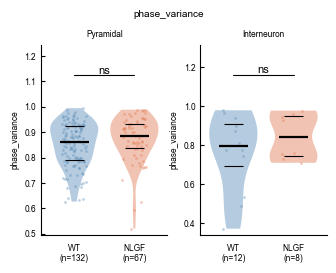

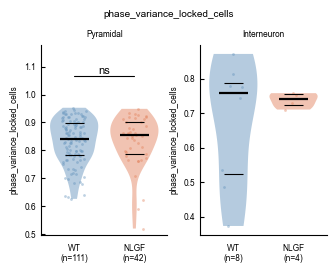

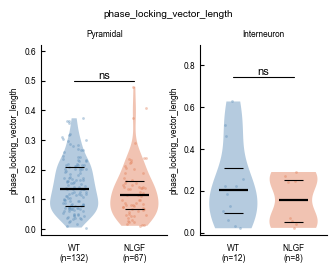

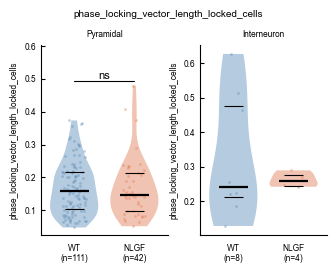

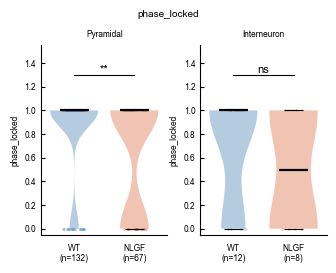

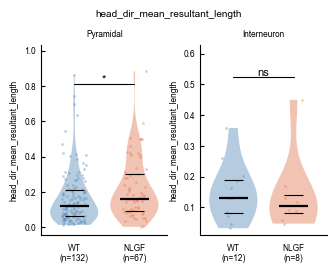

✅ All violin and box plots saved.


In [53]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


METRIC_DISPLAY = {
    "num_spikes":                              "Spike Count",
    "peak_rate":                               "Peak Rate (Hz)",
    "mean_rate":                               "Mean Rate (Hz)",
    "spike_width":                             "Spike Width (ms)",
    "ahp_decay":                               "AHP Decay",
    "overdispersion":                          "Overdispersion",
    "theta_mod_v3":                             "Theta Modulation",
    "field_size":                              "Field Size",
    "spatial_info":                            "Spatial Info (bits/spike)",
    "coherence":                               "Coherence",
    "spatial_sparsity":                        "Spatial Sparsity",
    "head_dir_kl_div":                         "HD KL Divergence",
    "half_split_z":                            "Half-split Stability (Z)",
    "odd_even_z":                              "Odd/Even Stability (Z)",
    "half_split_stability":                    "Half-split Stability",
    "odd_even_stability":                      "Odd/Even Stability",
}

def _pstars(p):
    if pd.isna(p): return ""
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "ns"

METRIC_ORDER = [
    col for col, fam, lnk, lbl, env in METRIC_SPECS
    if col in df_spatial_cells.columns
]
n_ct = len(CELL_TYPES)


# ═══════════════════════════════════════════════════════════════════════════════
# 1.  VIOLIN + BOX PLOTS  (one figure per metric)
# ═══════════════════════════════════════════════════════════════════════════════
df_plot = df_spatial_cells[
    df_spatial_cells["cell_type"].isin(CELL_TYPES) &
    df_spatial_cells["Genotype"].notna()
].copy()
df_plot["Genotype"] = df_plot["Genotype"].astype(str)
rng_m = np.random.default_rng(42)

def _sig_bracket(ax, genos_ct, vals, col, ct):
    """Draw a significance bracket above the plot."""
    if len(genos_ct) < 2:
        return
    row_s = df_mwu[
        (df_mwu["metric"] == col) & (df_mwu["cell_type"] == ct)
    ]
    if row_s.empty:
        return
    p_val = row_s.iloc[0]["p_fdr"]  # use FDR-corrected p-value for annotation
    stars = _pstars(p_val)
    if not stars:
        return
    all_v   = np.concatenate(list(vals.values()))
    y_top   = np.nanquantile(all_v, 0.97)
    y_range = np.nanmax(all_v) - np.nanmin(all_v) or 1.0
    bar_y   = y_top + 0.30 * y_range
    tip_y   = bar_y - 0.0 * y_range
    y_lo, y_hi = ax.get_ylim()
    ax.set_ylim(bottom=y_lo, top=max(y_hi, bar_y + 0.25 * y_range))
    x0, x1 = 0, len(genos_ct) - 1
    ax.plot([x0, x0, x1, x1], [tip_y, bar_y, bar_y, tip_y],
            color="black", linewidth=0.8)
    ax.text(
        (x0 + x1) / 2, bar_y, stars,
        ha="center", va="bottom", fontsize=8,
        fontweight="normal", color="black",
    )

for col in METRIC_ORDER:
    df_m = df_plot[["Genotype", "cell_type", col]].copy()
    df_m[col] = pd.to_numeric(df_m[col], errors="coerce")
    df_m = df_m.dropna(subset=[col])
    if df_m.empty:
        continue

    genos_all = [g for g in GENO_ORDER if g in df_m["Genotype"].values]

    # ── Violin ────────────────────────────────────────────────────────────────
    fig_v, axes_v = plt.subplots(1, n_ct, figsize=(1.6 * n_ct, 2.6), sharey=False)
    if n_ct == 1:
        axes_v = [axes_v]

    for ax, ct in zip(axes_v, CELL_TYPES):
        sub      = df_m[df_m["cell_type"] == ct]
        genos_ct = [g for g in genos_all if g in sub["Genotype"].values]
        if sub.empty or not genos_ct:
            ax.set_visible(False)
            continue

        vals = {g: sub.loc[sub["Genotype"] == g, col].dropna().values for g in genos_ct}

        if all(len(vals[g]) >= 3 for g in genos_ct):
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                parts = ax.violinplot(
                    [vals[g] for g in genos_ct],
                    positions=list(range(len(genos_ct))),
                    showmedians=False, showextrema=False, widths=0.8,
                )
            for i_v, pc in enumerate(parts["bodies"]):
                pc.set_facecolor(GENO_COLORS.get(genos_ct[i_v], "#aaaaaa"))
                pc.set_alpha(0.45)
                pc.set_edgecolor("none")

        for xi, g in enumerate(genos_ct):
            q1  = np.nanpercentile(vals[g], 25)
            med = np.nanmedian(vals[g])
            q3  = np.nanpercentile(vals[g], 75)
            ax.hlines([q1, q3], xi - 0.16, xi + 0.16,
                      colors="black", linewidth=0.8, zorder=7)
            ax.hlines(med, xi - 0.24, xi + 0.24,
                      colors="black", linewidth=1.6, zorder=6)

        for xi, g in enumerate(genos_ct):
            jitter = rng_m.uniform(-0.20, 0.20, size=len(vals[g]))
            ax.scatter(xi + jitter, vals[g],
                       color=GENO_COLORS.get(g, "#aaaaaa"),
                       s=4, alpha=0.4, zorder=5, linewidths=0)

        _sig_bracket(ax, genos_ct, vals, col, ct)

        ax.set_xticks(list(range(len(genos_ct))))
        ax.set_xticklabels([f"{g}\n(n={len(vals[g])})" for g in genos_ct])
        ax.set_xlim(-0.55, len(genos_ct) - 0.45)
        ax.set_ylabel(METRIC_DISPLAY.get(col, col))
        ax.set_title(ct)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="x", width=0.8, length=3)
        ax.tick_params(axis="y", width=0.8, length=3, direction="in")

    fig_v.suptitle(METRIC_DISPLAY.get(col, col))
    plt.tight_layout(pad=0.2, rect=[0, 0, 1, 0.95])
    vp = os.path.join(linear_track_OUTDIR, f"violin_{_safe_filename(col)}_MWU_spatial_cells.pdf")
    plt.savefig(vp)
    plt.show()
    plt.close(fig_v)

    # # ── Box ───────────────────────────────────────────────────────────────────
    # fig_b, axes_b = plt.subplots(1, n_ct, figsize=(1.6 * n_ct, 2.6), sharey=True)
    # if n_ct == 1:
    #     axes_b = [axes_b]

    # for ax, ct in zip(axes_b, CELL_TYPES):
    #     sub      = df_m[df_m["cell_type"] == ct]
    #     genos_ct = [g for g in genos_all if g in sub["Genotype"].values]
    #     if sub.empty or not genos_ct:
    #         ax.set_visible(False)
    #         continue

    #     vals = {g: sub.loc[sub["Genotype"] == g, col].dropna().values for g in genos_ct}

    #     for xi, g in enumerate(genos_ct):
    #         ax.boxplot(
    #             vals[g], positions=[xi], widths=0.6,
    #             patch_artist=True, manage_ticks=False,
    #             boxprops=dict(facecolor=GENO_COLORS.get(g, "#aaaaaa"),
    #                           alpha=0.55, linewidth=0.8),
    #             medianprops=dict(color="black", linewidth=1.0),
    #             whiskerprops=dict(linewidth=0.8),
    #             capprops=dict(linewidth=0.8),
    #             flierprops=dict(marker=".", markersize=2, alpha=0.25,
    #                             markerfacecolor=GENO_COLORS.get(g, "#aaaaaa"),
    #                             markeredgewidth=0),
    #         )

    #     for xi, g in enumerate(genos_ct):
    #         jitter = rng_m.uniform(-0.20, 0.20, size=len(vals[g]))
    #         ax.scatter(xi + jitter, vals[g],
    #                    color=GENO_COLORS.get(g, "#aaaaaa"),
    #                    s=4, alpha=0.4, zorder=4, linewidths=0)

    #     _sig_bracket(ax, genos_ct, vals, col, ct)

    #     ax.set_xticks(list(range(len(genos_ct))))
    #     ax.set_xticklabels([f"{g}\n(n={len(vals[g])})" for g in genos_ct])
    #     ax.set_xlim(-0.55, len(genos_ct) - 0.45)
    #     ax.set_ylabel(METRIC_DISPLAY.get(col, col))
    #     ax.set_title(ct)
    #     ax.spines["top"].set_visible(False)
    #     ax.spines["right"].set_visible(False)
    #     ax.tick_params(axis="x", width=0.8, length=3)
    #     ax.tick_params(axis="y", width=0.8, length=3, direction="in")

    
    # fig_b.suptitle(METRIC_DISPLAY.get(col, col))
    # plt.tight_layout(pad=0.2, rect=[0, 0, 1, 0.95])
    # bp = os.path.join(linear_track_OUTDIR, f"boxplot_{_safe_filename(col)}.pdf")
    # plt.savefig(bp)
    # plt.show()
    # plt.close(fig_b)

print("✅ All violin and box plots saved.")

# FORGET THE CELLS BELOW THIS ONE _ DIFFERENT KIND OF ANALYSIS

In [ ]:
"""
Now we have a dataframe with all the openfieldb trials, and we want to add transformed columns for better visualization 
and stats later on.
The code below applies log, log1p, logit, and Yeo-Johnson transforms to selected columns, 
creating new columns with suffixes like _log, _log1p, _logit, and _yj.
You can edit the lists of columns to transform according to your needs. 
The helper functions handle edge
cases like zeros or values outside the (0,1) range for log and logit transforms.
"""

# import os
# import numpy as np
# import pandas as pd
# from sklearn.preprocessing import PowerTransformer

# path = "/Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenFieldAnalysis/linear_track.parquet"
# out_path = path.replace(".parquet", "_with_transforms.parquet")

# df_transform = pd.read_parquet(path, engine="pyarrow")

# # --- helpers ---
# def safe_log(x, eps=1e-12):
#     x = pd.to_numeric(x, errors="coerce")
#     return np.log(x.clip(lower=eps))

# def safe_log1p(x):
#     x = pd.to_numeric(x, errors="coerce")
#     return np.log1p(x.clip(lower=0))

# def logit01(x, eps=1e-6):
#     x = pd.to_numeric(x, errors="coerce")
#     p = x.clip(eps, 1 - eps)
#     return np.log(p / (1 - p))

# def yeo_johnson(x):
#     x = pd.to_numeric(x, errors="coerce")
#     mask = x.notna()
#     out = pd.Series(np.nan, index=x.index, dtype="float64")
#     if mask.sum() >= 2:
#         pt = PowerTransformer(method="yeo-johnson", standardize=False)
#         out.loc[mask] = pt.fit_transform(x.loc[mask].to_numpy().reshape(-1,1)).ravel()
#     return out

# # --- choose transforms (edit these lists to your needs) ---
# log_cols = ["peak_rate", "mean_firing_rate", "overdispersion",
#             "spatial_info", "phase_locking_z_stat", "head_dir_mean_resultant_length", 
#             ]  # positive values, but can be zero or very small

# log1p_cols = ["num_spikes"]  # counts with possible zeros

# logit_cols = ["phase_variance","phase_locking_vector", "contamination_R" ]  # bounded 0..1

# pval_cols = ["phase_locking_p_value"]  # if you insist keeping it: -log10(p)

# yj_cols = ["theta_modulation", "odd_even_stability"]  # only if a column can be negative or crosses 0 (e.g., if your theta_modulation sometimes does)

# no_transform_cols = ["num_spikes", "AHP_decay", "field_size", "phase_mean", 
#                      "half_split_stability", "coherence"
#                      "head_dir_mean_resultant_angle", "contamination_Q", 
#                      ]  # if you want to keep the original without transform, but it doesn't need one

# # --- apply ---
# for c in log_cols:
#     if c in df_transform.columns:
#         df_transform[c + "_log"] = safe_log(df_transform[c])

# for c in log1p_cols:
#     if c in df_transform.columns:
#         df_transform[c + "_log1p"] = safe_log1p(df_transform[c])

# for c in logit_cols:
#     if c in df_transform.columns:
#         df_transform[c + "_logit"] = logit01(df_transform[c])

# for c in pval_cols:
#     if c in df_transform.columns:
#         p = pd.to_numeric(df_transform[c], errors="coerce").clip(1e-300, 1.0)
#         df_transform[c + "_mlog10"] = -np.log10(p)

# for c in yj_cols:
#     if c in df_transform.columns:
#         df_transform[c + "_yj"] = yeo_johnson(df_transform[c])

# # Optional: make sure categoricals don't cause parquet quirks
# # df_transform = df_transform.copy()
# # for c in df_transform.select_dtypes(["category"]).columns:
# #     df_transform[c] = df_transform[c].astype("string")

# df_transform.to_parquet(out_path, index=False, engine="pyarrow")
# print("Wrote:", out_path)
# #save as csv if you want to open in excel, but parquet is better for pandas
# df_transform.to_csv(out_path.replace(".parquet", ".csv"), index=False)


In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.preprocessing import PowerTransformer

# yj_cols = ["theta_modulation", "odd_even_stability"]

# def add_yeo_johnson_columns(df: pd.DataFrame, cols, suffix="_yj", standardize=False):
#     """
#     Adds Yeo–Johnson transformed versions of cols to df as <col><suffix>.
#     Returns (df_out, lambda_table_df)
#     """
#     df_out = df.copy()
#     lambda_rows = []

#     for col in cols:
#         if col not in df_out.columns:
#             print(f"Skipping {col}: not in dataframe")
#             continue

#         s = pd.to_numeric(df_out[col], errors="coerce")
#         mask = s.notna()

#         if mask.sum() < 3:
#             print(f"Skipping {col}: not enough non-missing values (n={mask.sum()})")
#             df_out[col + suffix] = np.nan
#             continue

#         pt = PowerTransformer(method="yeo-johnson", standardize=standardize)
#         yj = pt.fit_transform(s.loc[mask].to_numpy().reshape(-1, 1)).ravel()

#         df_out[col + suffix] = np.nan
#         df_out.loc[mask, col + suffix] = yj

#         lambda_rows.append({
#             "column": col,
#             "n_used": int(mask.sum()),
#             "lambda": float(pt.lambdas_[0]),
#             "standardize": bool(standardize),
#             "new_column": col + suffix
#         })

#     lambda_df = pd.DataFrame(lambda_rows)
#     return df_out, lambda_df

# df_linear_track, yj_lambda_table = add_yeo_johnson_columns(
#     df_linear_track, yj_cols, suffix="_yj", standardize=False
# )

# display(yj_lambda_table)
# save_path = os.path.join(linear_track_OUTDIR, "yeo_johnson_lambda_table.csv")
# yj_lambda_table.to_csv(save_path, index=False)
# print("Saved Yeo-Johnson lambda table to:", save_path)



## ANOVA TYPE III ANALYSIS

In [ ]:
# """
# Stats functions and plotting utilities for Open field analysis

# """

# import itertools
# import matplotlib.patches as mpatches

# def _find_col(df, names):
#     def norm(s):
#         return re.sub(r"[\s_]+", "", str(s)).lower()
#     norm_map = {norm(c): c for c in df.columns}
#     for n in names:
#         key = norm(n)
#         if key in norm_map:
#             return norm_map[key]
#     raise KeyError(f"Could not find any of {names}. Available columns: {list(df.columns)}")

# def _sig_stars(p):
#     if p is None or not np.isfinite(p):
#         return "NA"
#     if p < 0.001:
#         return "***"
#     if p < 0.01:
#         return "**"
#     if p < 0.05:
#         return "*"
#     return "ns"
# #
# def _format_p(p):
#     if p is None or not np.isfinite(p):
#         return "NA"
#     # if p < 0.001:
#         return "<0.001"
#     return f"{p:.3f}"

# def _build_order(levels, preferred_tokens):
#     levels = [lv for lv in levels if pd.notna(lv)]
#     used = set()
#     out = []

#     def norm(x): 
#         return str(x).strip().lower()

#     for tok in preferred_tokens:
#         tok_n = tok.lower()
#         match = None
#         for lv in levels:
#             lv_n = norm(lv)
#             if lv_n == tok_n or tok_n in lv_n:
#                 match = lv
#                 break
#         if match is not None and match not in used:
#             out.append(match)
#             used.add(match)

#     for lv in levels:
#         if lv not in used:
#             out.append(lv)
#     return out

# def _tukey_pairs(df_ct_stats: pd.DataFrame, metric: str, genotype_col: str, present_genos: list):
#     work = df_ct_stats[[metric, genotype_col]].dropna().copy()
#     work[metric] = pd.to_numeric(work[metric], errors="coerce")
#     work = work.dropna(subset=[metric])

#     counts = work.groupby(genotype_col)[metric].size()
#     valid_genos = counts[counts >= 2].index.tolist()
#     work = work[work[genotype_col].isin(valid_genos)]
#     if work[genotype_col].nunique() < 2:
#         return []

#     tuk = pairwise_tukeyhsd(
#         endog=work[metric].to_numpy(),
#         groups=work[genotype_col].astype(str).to_numpy(),
#         alpha=0.05
#     )
#     tuk_df = pd.DataFrame(tuk._results_table.data[1:], columns=tuk._results_table.data[0])

#     geno_lookup = {str(g): g for g in present_genos}
#     out = []
#     for _, r in tuk_df.iterrows():
#         g1s, g2s = str(r["group1"]), str(r["group2"])
#         if g1s in geno_lookup and g2s in geno_lookup:
#             out.append(((geno_lookup[g1s], geno_lookup[g2s]), float(r["p-adj"])))
#     return out

# # BRACKETS # Utility function to draw significance brackets between two x positions at a given y level with a label (e.g. p-value)
# def _draw_bracket(ax, x1, x2, y, h, text, fontsize=8):
#     ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.0, c="black", zorder=8)
#     ax.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom", fontsize=fontsize, zorder=9)


# # This is a utility function to drop boxplot fliers (for cleaner visualization) while keeping the underlying data points for stats tests and median overlay.
# def _drop_boxplot_fliers_points_only(df: pd.DataFrame, metric: str, group_cols: list[str]) -> pd.DataFrame:
#     g = df.groupby(group_cols)[metric]
#     q1 = g.quantile(0.25)
#     q3 = g.quantile(0.75)
#     iqr = q3 - q1
#     lo = (q1 - 1.5 * iqr).rename("lo")
#     hi = (q3 + 1.5 * iqr).rename("hi")

#     bounds = pd.concat([lo, hi], axis=1).reset_index()
#     tmp = df.merge(bounds, on=group_cols, how="left")
#     tmp = tmp[tmp[metric].between(tmp["lo"], tmp["hi"], inclusive="both")]
#     return tmp.drop(columns=["lo", "hi"])

# # Utility to make a string safe for filenames (removes/replace special characters, truncates to reasonable length)
# def _safe_filename(s: str) -> str:
#     s = str(s).strip()
#     s = re.sub(r"[^\w\-.]+", "_", s)  # keep letters/numbers/_/./-
#     return s[:180]

# # Utility to ensure a path is a pathlib.Path object
# def _as_path(p):
#     return p if isinstance(p, Path) else Path(str(p))

# # Main analysis function: runs 2-way ANOVA and saves boxplots by Genotype and Cell type
# def analyze_linear_track_by_celltype_and_genotype(
#     df_linear_track: pd.DataFrame,
#     outdir: str,
#     celltype_col: str | None = None,
#     genotype_col: str | None = None,
#     exclude_numeric_cols: list[str] | None = None,
#     min_n: int = 10,
#     save_png: bool = True,
#     png_dpi: int = 300,
#     png_figsize: tuple[float, float] | None = (6.5, 3.6),  # quarter-slide for 16:9
# ):
      
#     if celltype_col is None:
#         celltype_col = _find_col(df_linear_track, ["Cell Type", "Cell type", "cell_type", "celltype"])
#     if genotype_col is None:
#         genotype_col = _find_col(
#             df_linear_track,
#             ["Genotype", "Phenotype", "genotype", "geno", "genotype_group", "Genotype group"],
#         )

#     print("Using CellType_COL =", celltype_col)
#     print("Using Genotype_COL =", genotype_col)

#     numeric_cols = df_linear_track.select_dtypes(include=[np.number]).columns.tolist()
#     exclude = set(exclude_numeric_cols or ["tetrode", "channel", "cluster", "mouse_name"])
#     cols_to_use = [c for c in numeric_cols if c not in exclude]

#     # ---------- 1) 2-way ANOVA: Genotype x Cell type ----------
#     anova_rows = []
#     term_gt = f'C(Q("{genotype_col}"))'
#     term_ct = f'C(Q("{celltype_col}"))'
#     term_int = f"{term_gt}:{term_ct}"

#     for metric in cols_to_use:
#         test_data = df_linear_track[[metric, genotype_col, celltype_col]].dropna()
#         if len(test_data) < min_n:
#             continue
#         if test_data[genotype_col].nunique() < 2 or test_data[celltype_col].nunique() < 2:
#             continue

#         try:
#             formula = f'Q("{metric}") ~ {term_gt} * {term_ct}'
#             model = ols(formula, data=test_data).fit()
#             aov = anova_lm(model, typ=3)  # Type III ANOVA

#             p_gt  = float(aov.loc[term_gt,  "PR(>F)"]) if term_gt  in aov.index else np.nan
#             p_ct  = float(aov.loc[term_ct,  "PR(>F)"]) if term_ct  in aov.index else np.nan
#             p_int = float(aov.loc[term_int, "PR(>F)"]) if term_int in aov.index else np.nan

#             f_gt  = float(aov.loc[term_gt,  "F"]) if term_gt  in aov.index and "F" in aov.columns else np.nan
#             f_ct  = float(aov.loc[term_ct,  "F"]) if term_ct  in aov.index and "F" in aov.columns else np.nan
#             f_int = float(aov.loc[term_int, "F"]) if term_int in aov.index and "F" in aov.columns else np.nan

#             anova_rows.append({
#                 "column": metric,
#                 "n_observations": int(len(test_data)),
#                 "n_genotypes": int(test_data[genotype_col].nunique()),
#                 "n_cell_types": int(test_data[celltype_col].nunique()),
#                 "F_Genotype": f_gt,
#                 "F_CellType": f_ct,
#                 "F_Interaction": f_int,
#                 "p_Genotype": p_gt,
#                 "p_CellType": p_ct,
#                 "p_Interaction": p_int,
#                 "sig_Genotype": _sig_stars(p_gt),
#                 "sig_CellType": _sig_stars(p_ct),
#                 "sig_Interaction": _sig_stars(p_int),
#             })
#         except Exception as e:
#             print(f"Could not run ANOVA for {metric}: {e}")

#     df_anova = pd.DataFrame(anova_rows).sort_values("p_Genotype", na_position="last")
#     display_df("2-way ANOVA: Genotype x Cell type", df_anova)

#     anova_save_path = os.path.join(outdir, "linear_track_2way_anova_genotype_celltype.csv")
#     df_anova.to_csv(anova_save_path, index=False)
#     print(f"Saved ANOVA table to: {anova_save_path}")

#     aov_lookup = df_anova.set_index("column").to_dict(orient="index")

#     # ---------- 2) Boxplots PDF: metric by Cell type (hue=Genotype) ----------
#     pdf_path = os.path.join(outdir, "linear_track_boxplots_by_genotype_and_celltype.pdf")
#     outdir_path = _as_path(outdir)
    
#     png_dir = outdir_path / "png"
#     if save_png:
#         png_dir.mkdir(parents=True, exist_ok=True)

#     with PdfPages(pdf_path) as pdf:
#         fig = plt.figure(figsize=(11.69, 8.27)) # A4 landscape
#         gt_levels = sorted(df_linear_track[genotype_col].dropna().unique().tolist())
#         ct_levels = sorted(df_linear_track[celltype_col].dropna().unique().tolist())
#         txt = (
#             "Open field dataset - Boxplots by Genotype and Cell type\n"
#             f"Genotypes: {', '.join(map(str, gt_levels))}\n"
#             f"Cell types: {', '.join(map(str, ct_levels))}\n"
#             "Black diamonds = medians (value printed)\n"
#             "Brackets = pairwise genotype post-hoc p-values within each cell type (Tukey HSD-adjusted)\n"
#             "Outliers removed from boxplots for visualization, but all points used for stats and median calculation"
#         )
        
#         fig.text(0.05, 0.9, txt, fontsize=20, va="top") 
#         plt.axis("off")
#         pdf.savefig(fig, bbox_inches="tight")
#         plt.close(fig)

#         hue_order = _build_order(gt_levels, ["WT", "NLGF"])
#         x_order = _build_order(ct_levels, ["pyramidal", "interneurons"])

#         box_width = 0.32
#         point_jitter = 0.30
#         point_alpha = 0.4
#         point_size = 2.0


#         for metric in cols_to_use:
#             plot_data = df_linear_track[[metric, genotype_col, celltype_col]].dropna()
#             if len(plot_data) == 0:
#                 continue
#             if plot_data[celltype_col].nunique() < 2:
#                 continue
#             if plot_data[genotype_col].nunique() < 2:
#                 continue

#             fig = plt.figure(figsize=(png_figsize if (save_png and png_figsize) else (11.69, 8.27)))
#             ax = fig.add_subplot(111)

#             # --- palette: make WT lighter blue ---
#             base = sns.color_palette("tab10", n_colors=len(hue_order))
#             palette = dict(zip(hue_order, base))
            
#             for g in hue_order:
#                 if "wt" in str(g).strip().lower():
#                     palette[g] = sns.color_palette("Blues", 6)[2]  # lighter blue
#                 if "nlgf" in str(g).strip().lower():
#                     palette[g] = sns.color_palette("Oranges", 6)[2]  # lighter orange

#             n_hue = max(1, len(hue_order))
#             j = 0.8 * (box_width / (2 * n_hue))   # e.g. ~0.09 when n_hue=2


#             sns.boxplot(
#                 data=plot_data,
#                 x=celltype_col,
#                 y=metric,
#                 hue=genotype_col,
#                 order=x_order,
#                 hue_order=hue_order,
#                 palette=palette,
#                 showfliers=False,
#                 # width=box_width,
#                 linewidth=0.8,
#                 ax=ax,
#             )

#             plot_points = _drop_boxplot_fliers_points_only(plot_data, metric, [celltype_col, genotype_col])
#             if plot_points.empty:
#                 plot_points = plot_data  # fallback: avoid seaborn error if everything got filtered
            
            
#             sns.stripplot(
#                 data=plot_points,
#                 x=celltype_col,
#                 y=metric,
#                 hue=genotype_col,
#                 order=x_order,
#                 hue_order=hue_order,
#                 palette=palette,
#                 dodge=True,
#                 jitter=point_jitter,
#                 size=point_size,
#                 alpha=point_alpha,
#                 linewidth=0.25,
#                 ax=ax,
#                 legend=False,  # we'll add a custom legend later (to avoid duplicate entries from boxplot and stripplot
#             )

#             fstats_fs = 7
#             label_fs = 9
#             tick_fs = 8
#             legend_fs = 8
#             legend_title_fs = 9
            
#             handles, labels = ax.get_legend_handles_labels()
#             by_label = dict(zip(labels, handles))
#             ax.legend(
#                 by_label.values(),
#                 by_label.keys(),
#                 title=genotype_col,
#                 title_fontsize=legend_title_fs,
#                 fontsize=legend_fs,
#                 bbox_to_anchor=(1.02, 1),
#                 loc="upper left",
#                 borderaxespad=0,
#             )

#             # ---- Title + F-stats (2nd line) ----
#             row = aov_lookup.get(metric, {})
#             f_gt = row.get("F_Genotype", np.nan)
#             f_ct = row.get("F_CellType", np.nan)
#             f_int = row.get("F_Interaction", np.nan)

#             p_gt  = row.get("p_Genotype", np.nan)
#             p_ct  = row.get("p_CellType", np.nan)
#             p_int = row.get("p_Interaction", np.nan)
            
#             fline = (
#                 f"F_Genotype={f_gt:.3f} (p={_format_p(p_gt)})    "
#                 f"F_CellType={f_ct:.3f} (p={_format_p(p_ct)})    "
#                 f"F_Interaction={f_int:.3f} (p={_format_p(p_int)})"
#             )
        
            
#             # ax.set_title(f"{metric}\n{fline}")
#             pretty = str(metric).replace("_", " ").title()
#             set_panel_title(ax, pretty)

#             # ax.set_title(metric, fontsize=title_fs, fontweight="bold", pad=14)
            
#             ax.text(
#                 0.5, 1.01, fline,
#                 transform=ax.transAxes,
#                 ha="center", va="bottom",
#                 fontsize=fstats_fs,
#                 fontweight="bold",
#                 # fontstyle="italic",
#                 color = "dimgray",
#             )
            
#             ax.set_xlabel(celltype_col, fontsize=label_fs, fontweight="bold")
#             ax.set_ylabel(pretty, fontsize=label_fs, fontweight="bold")
#             ax.tick_params(axis="both", labelsize=tick_fs)
#             ax.tick_params(axis="x")  # rotation = 30 is usually enough for small plots; here I dind't use it
            
#             # ---- Median overlay (diamond + value) ----
#             med = (
#                 plot_data
#                 .groupby([celltype_col, genotype_col], dropna=False)[metric]
#                 .median()
#                 .reset_index(name="median")
#             )

#             m = max(1, len(hue_order))
#             box_width = 0.8
#             y0, y1 = ax.get_ylim()
#             ypad = 0.05 * (y1 - y0)
#             label_pad = 0.01 * (y1 - y0)

#             for i, ct in enumerate(x_order):
#                 for j, gt in enumerate(hue_order):
#                     sub = med[(med[celltype_col] == ct) & (med[genotype_col] == gt)]
#                     if sub.empty:
#                         continue
#                     med_val = float(sub["median"].iloc[0])
#                     offset = (j - (m - 1) / 2) * (box_width / m)
#                     x_pos = i + offset
#                     ax.scatter([x_pos], [med_val], color="black", s=5, marker="D", zorder=6)
#                     ax.text(x_pos, med_val + label_pad, f"{med_val:.3g}", ha="center", va="bottom", fontsize=7, zorder=7, fontweight="normal", fontstyle="italic")


#             # ---- Pairwise genotype p-values within each cell type (brackets) ----
#             geno_to_index = {g: idx for idx, g in enumerate(hue_order)}
#             ct_to_index = {ct: idx for idx, ct in enumerate(x_order)}
            
#             # Use the CURRENT limits from what is actually drawn (boxplot + stripplot)
#             y0, y1 = ax.get_ylim()
#             yr_vis = y1 - y0
#             ypad = 0.05 * yr_vis
#             h = 0.01 * yr_vis
            
#             # ---- Pairwise genotype post-hoc within each cell type (Tukey HSD) ----
#             geno_to_index = {g: idx for idx, g in enumerate(hue_order)}
#             ct_to_index = {ct: idx for idx, ct in enumerate(x_order)}

#             # Use the CURRENT limits from what is actually drawn (boxplot + stripplot)
#             y0, y1 = ax.get_ylim()
#             yr_vis = y1 - y0
#             ypad = 0.05 * yr_vis
#             h = 0.01 * yr_vis

#             # -------- Pass 1: compute stats (plot_data) + decide bracket baselines (plot_points)
#             ct_results = {}   # ct -> list of ((g1,g2), p_adj_from_tukey)
#             ct_ybase = {}     # ct -> visible max
#             y_needed_top = y1

#             for ct in x_order:
#                 df_ct_stats = plot_data[plot_data[celltype_col] == ct]
#                 if df_ct_stats.empty:
#                     continue

#                 df_ct_vis = plot_points[plot_points[celltype_col] == ct]
#                 if df_ct_vis.empty:
#                     # nothing visible for this cell type -> don't draw brackets
#                     continue

#                 y_base = float(df_ct_vis[metric].max())
#                 ct_ybase[ct] = y_base

#                 present_genos = [g for g in hue_order if g in set(df_ct_stats[genotype_col].unique())]
#                 if len(present_genos) < 2:
#                     continue

#                 pairs_with_p = _tukey_pairs(df_ct_stats, metric, genotype_col, present_genos)
#                 if not pairs_with_p:
#                     continue

#                 ct_results[ct] = pairs_with_p

#                 # how high we may need to go for this ct (stacking)
#                 n = len(ct_results[ct])
#                 top_for_ct = y_base + ypad + (n - 1) * ypad + h + ypad
#                 y_needed_top = max(y_needed_top, top_for_ct)

#             # Set ylim once, high enough for all brackets
#             ax.set_ylim(y0, y_needed_top)

#             # -------- Pass 2: draw brackets using visible-based y positions
#             stack_y = {ct: ct_ybase[ct] + ypad for ct in ct_results.keys()}

#             for ct, results in ct_results.items():
#                 i = ct_to_index[ct]
#                 for (g1, g2), padj in results:
#                     j1 = geno_to_index[g1]
#                     j2 = geno_to_index[g2]
#                     off1 = (j1 - (m - 1) / 2) * (box_width / m)
#                     off2 = (j2 - (m - 1) / 2) * (box_width / m)
#                     x_left = i + off1
#                     x_right = i + off2
#                     if x_left > x_right:
#                         x_left, x_right = x_right, x_left

#                     y = stack_y[ct]
#                     label = f"p={_format_p(padj)} ({_sig_stars(padj)})"
#                     _draw_bracket(ax, x_left, x_right, y, h, label, fontsize=8)
#                     stack_y[ct] = y + ypad

#             fig.tight_layout()
#             if save_png:
#                 png_name = f"{_safe_filename(metric)}__by_celltype_hue_genotype.png"
#                 png_path = png_dir / png_name
#                 fig.savefig(png_path, dpi=png_dpi, bbox_inches="tight")
#             pdf.savefig(fig)
#             plt.close(fig)

#     print(f"Saved boxplots PDF to: {pdf_path}")
#     return df_anova, anova_save_path, pdf_path



In [ ]:
# Run the ANOVA and boxplot analysis for all numeric columns by Genotype and Cell type 
df_anova_genotype_celltype, anova_csv, boxplot_pdf = analyze_linear_track_by_celltype_and_genotype(
    df_linear_track=df_linear_track,
    outdir=linear_track_OUTDIR,
)

#CONTINUE FROM HERE 

# MLM/GEE pipeline 

**MLM = Mixed Linear Model** (also called Linear Mixed-Effects Model). The code uses R's lmerTest package to fit a model like y ~ Genotype * Cell_type + (1|mouse_name), where (1|mouse_name) is the random effect that accounts for the fact that multiple cells come from the same animal. This is the "mixed" part.

**GEE = Generalized Estimating Equations**. This is an alternative method for handling correlated/clustered data (e.g., multiple neurons per mouse). GEE estimates population-averaged effects rather than subject-specific effects, and is robust to misspecification of the within-cluster correlation structure.

Both are appropriate here because the data has a nested/clustered structure — multiple cells recorded from the same mouse — which violates the independence assumption of a standard ANOVA. The comment in the cell even notes this: "can handle unbalanced data better than ANOVA". The pipeline appears to use the MLM path (via lmerTest + emmeans), with GEE as a conceptual alternative, hence the combined label.

In [ ]:
"""
Optional: R-based mixed model + emmeans analysis (if you have rpy2 and R with lmerTest and emmeans installed). 
This is more complex but gives you more detailed stats (e.g. pairwise comparisons with adjusted p-values and confidence intervals) 
and can handle unbalanced data better than ANOVA. 
You can skip this if you just want the ANOVA and boxplots.

The R code currently uses lmerTest for mixed models and emmeans for post-hoc comparisons. 
# It runs a model like: y ~ Genotype * Cell_type + (1|mouse_name) and then extracts Type III ANOVA, fixed effects, emmeans for Genotype within each Cell type, and pairwise comparisons. 
# You can customize the model formula, random effects structure, and which emmeans comparisons to run.
"""

#TODO: Check the adjustment method in the R code (ADJ variable) and make sure it matches what you want (e.g. "holm", "fdr", "bonferroni", etc.)

import pandas as pd
import numpy as np

def mixedlm_emmeans_full_r(
    df: pd.DataFrame,
    metric: str,
    genotype_col: str = "Genotype",
    celltype_col: str = "Cell type",
    animal_col: str = "mouse_name",
    adjust: str = "holm",
    reml: bool = False,
):
    d = df[[metric, genotype_col, celltype_col, animal_col]].dropna().copy()
    d["y_tmp"] = pd.to_numeric(d[metric], errors="coerce")
    d = d.dropna(subset=["y_tmp"])

    d[genotype_col] = pd.Categorical(d[genotype_col].astype(str))
    d[celltype_col] = pd.Categorical(d[celltype_col].astype(str))
    d[animal_col]   = pd.Categorical(d[animal_col].astype(str))

    d = d.rename(columns={
        genotype_col: "Genotype",
        celltype_col: "Cell_type",
        animal_col:   "mouse_name",
    })
    genotype_col = "Genotype"
    celltype_col = "Cell_type"
    animal_col   = "mouse_name"

    import rpy2.robjects as ro
    from rpy2.robjects import pandas2ri
    from rpy2.robjects.conversion import localconverter      

    ro.r("suppressPackageStartupMessages(library(lmerTest))")
    ro.r("suppressPackageStartupMessages(library(emmeans))")

    with localconverter(ro.default_converter + pandas2ri.converter):
        r_df = ro.conversion.py2rpy(d)
   
    ro.globalenv["dat"] = r_df
    ro.globalenv["geno_col"] = genotype_col
    ro.globalenv["ct_col"]   = celltype_col
    ro.globalenv["an_col"]   = animal_col 
    ro.globalenv["ADJ"]      = adjust
    ro.globalenv["REML_FLAG"] = bool(reml)

    r_code = r"""
    dat2 <- dat
    dat2[[geno_col]] <- factor(as.character(dat2[[geno_col]]))
    dat2[[ct_col]]   <- factor(as.character(dat2[[ct_col]])) 
    dat2[[an_col]]   <- factor(as.character(dat2[[an_col]])) # ensure it's treated as a random effect (categorical)
    dat2 <- droplevels(dat2)

    # No backticks needed now (names are safe)
    f_txt <- sprintf("y_tmp ~ %s * %s + (1|%s)", geno_col, ct_col, an_col)
    form  <- as.formula(f_txt)

    fit <- lmer(form, data=dat2, REML=REML_FLAG)

    a3 <- anova(fit, type=3)
    a3_df <- as.data.frame(a3)
    a3_df$Effect <- rownames(a3_df)
    rownames(a3_df) <- NULL
    a3_df <- a3_df[, c("Effect", setdiff(names(a3_df), "Effect"))]

    coefs <- summary(fit)$coefficients
    coefs_df <- data.frame(term=rownames(coefs), coefs, check.names=FALSE)
    rownames(coefs_df) <- NULL

    ci <- confint(fit, parm="beta_", method="Wald")
    ci_df <- data.frame(term=rownames(ci), ci_low=ci[,1], ci_high=ci[,2], check.names=FALSE)
    rownames(ci_df) <- NULL
    coefs_df <- merge(coefs_df, ci_df, by="term", all.x=TRUE, sort=FALSE)

    emm_2x2 <- emmeans(fit, specs = ~ Genotype * Cell_type)
    emm_2x2_df <- as.data.frame(emm_2x2); rownames(emm_2x2_df) <- NULL

    emm_g_ct <- emmeans(fit, specs = ~ Genotype | Cell_type)
    emm_g_ct_df <- as.data.frame(emm_g_ct); rownames(emm_g_ct_df) <- NULL

    ph <- pairs(emm_g_ct, reverse=TRUE, by="Cell_type", adjust=ADJ) 
    ph_df <- as.data.frame(ph); rownames(ph_df) <- NULL

    # ---- NEW: caption-ready one-line summary (difference, CI, adjusted p) ----
    ph_ci_df <- as.data.frame(confint(ph))
    rownames(ph_ci_df) <- NULL

    caption_df <- merge(
      ph_df[, c("Cell_type", "contrast", "estimate", "p.value")],
      ph_ci_df[, c("Cell_type", "contrast", "lower.CL", "upper.CL")],
      by = c("Cell_type", "contrast"),
      all.x = TRUE,
      sort = FALSE
    )
    names(caption_df)[names(caption_df) == "estimate"] <- "difference"
    # -----------------------------------------------------------------------

    list(
      anova_type3 = a3_df,
      fixed_effects = coefs_df,
      emmeans_2x2 = emm_2x2_df,
      emmeans_genotype_within_celltype = emm_g_ct_df,
      posthoc_genotype_within_celltype = ph_df,
      caption_summary = caption_df
    )
    """
#TODO: Check the adjustment method in the R code (ADJ variable) and make sure it matches what you want (e.g., "holm", "bonferroni", "fdr", etc.).
    out = ro.r(r_code)

    with localconverter(ro.default_converter + pandas2ri.converter):
        return {
            "anova_type3": ro.conversion.rpy2py(out.rx2("anova_type3")),
            "fixed_effects": ro.conversion.rpy2py(out.rx2("fixed_effects")),
            "emmeans_2x2": ro.conversion.rpy2py(out.rx2("emmeans_2x2")),
            "emmeans_genotype_within_celltype": ro.conversion.rpy2py(out.rx2("emmeans_genotype_within_celltype")),
            "posthoc_genotype_within_celltype": ro.conversion.rpy2py(out.rx2("posthoc_genotype_within_celltype")),
            "caption_summary": ro.conversion.rpy2py(out.rx2("caption_summary")),
        }


In [ ]:
"""
Run mixed models + emmeans for all numeric columns (except some metadata) and print results"""

metric_cols = df_transform.select_dtypes(include=[np.number]).columns.tolist()
excepting_cols = ["tetrode", "channel", "cluster", "mouse_name", "Age_weeks"]
metric_cols = [col for col in metric_cols if col not in excepting_cols]

print("Numeric columns available for mixed model analysis:", metric_cols)

for metric in metric_cols:
    res = mixedlm_emmeans_full_r(df_transform, metric=metric, adjust="holm")

    print(f"\n--- Results for metric: {metric} ---")
    print(res["caption_summary"])

In [ ]:
"""More detailed results for the first metric (ANOVA table, fixed effects, emmeans, post-hoc)
"""
metric_cols = df_transform.select_dtypes(include=[np.number]).columns.tolist()
excepting_cols = ["tetrode", "channel", "cluster", "mouse_name", "Age_weeks"]
metric_cols = [col for col in metric_cols if col not in excepting_cols]

print("Numeric columns available for mixed model analysis:", metric_cols)

for metric in metric_cols:
    res = mixedlm_emmeans_full_r(
        df_transform,
        metric=metric,
        genotype_col="Genotype",
        celltype_col="Cell type",
        animal_col="mouse_name",
        adjust="holm",
    
    )

    save_path = os.path.join(
        linear_track_OUTDIR, 
        f"mixedlm_emmeans_{_safe_filename(metric)}.xlsx"
    )
    os.makedirs(linear_track_OUTDIR, exist_ok=True)

    with pd.ExcelWriter(save_path, engine="openpyxl") as writer:
        res["anova_type3"].to_excel(writer, sheet_name="ANOVA_Type3", index=False)
        res["fixed_effects"].to_excel(writer, sheet_name="Fixed_Effects", index=False)
        res["emmeans_2x2"].to_excel(writer, sheet_name="EMMeans_2x2", index=False)
        res["emmeans_genotype_within_celltype"].to_excel(writer, sheet_name="EMMeans_G_within_CT", index=False)
        res["posthoc_genotype_within_celltype"].to_excel(writer, sheet_name="GenotypeDiff_within_CT", index=False)

        # If you added the caption table earlier:
        if "caption_summary" in res:
            res["caption_summary"].to_excel(writer, sheet_name="Caption_Summary", index=False)

    print(f"Saved Excel workbook to: {save_path}")

    print(f"\n\n=== Metric: {metric} ===")
    print("Type III ANOVA:")
    print(res["anova_type3"])
    print("\nFixed effects coefficients:")
    print(res["fixed_effects"])
    print("\nEstimated marginal means (2x2):")
    print(res["emmeans_2x2"])
    print("\nPost-hoc pairwise Genotype comparisons within each Cell type (Holm-adjusted):")
    print(res["posthoc_genotype_within_celltype"])    

###todo: CHange the plots so it displays the median as well as the other test (not just the interaction, and also move the letters of the second line down). 

In [ ]:
print(df_linear_track.columns.tolist()
      )
print(df_linear_track[["Genotype", "Cell type", "mouse_name", "spike_width"]].head())
print(df_linear_track[["Genotype", "Cell type", "mouse_name", "spike_width"]].groupby(["Genotype", "Cell type"]).size())
# print(df_linear_track[["Genotype", "Cell type", "mouse_name", "spike_width"]].groupby(["Genotype", "Cell type"])["spike_width"].describe())
print("----------------------------------------------------------------")
print(df_linear_track[["Genotype", "Cell type", "mouse_name", "spike_width"]].dtypes)

# Part 2: Behavioral / positional data (cells 20–23)
1. Loads a separate positional stats CSV (linear_track_positional_stats.csv)
2. Normality checks (Shapiro-Wilk) and Mann-Whitney U tests for thigmotaxis, distance traversed, and mean speed
3. Age regressions — scatterplots with linear fits for distance and thigmotaxis vs age, per genotype
4. NaN audit — percentage of cells with missing field_size per mouse


In [ ]:
"""
Normality check and distribution plots for thigmo_score, distance_traversed, and mean_speed
by Genotype (WT vs NLGF)
"""

from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set the input path ONCE (edit this one line only)
linear_track_pos = Path('/Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LT_concat/concatenated_pos_stats.csv')
linear_track_DIR = linear_track_pos.parent
linear_track_Pos_OUTDIR = linear_track_DIR.parent / "LinearTrack_Positional_stats"

linear_track_Pos_OUTDIR.mkdir(parents=True, exist_ok=True)
print("Saving outputs to:", linear_track_Pos_OUTDIR)

df_pos_stats = pd.read_csv(linear_track_pos)

# Columns to check
metrics = ['thigmotaxis', 'distance_traversed', 'mean_speed']



# Check if 'filename' column exists
if 'filename' in df_pos_stats.columns:
    print("Original dataframe shape:", df_pos_stats.shape)
    print("\nSample filenames before filtering:")
    print(df_pos_stats['filename'].head(10))
    
    # Filter for linear_track trials
    print("Original dataframe shape:", df_pos_stats.shape)
    
    if 'environment' in df_pos_stats.columns:
        df_linear_track_pos_stats = df_pos_stats[
            df_pos_stats['environment'].astype(str).str.contains('linear.?track', case=False, na=False)
        ].copy()
        
        print(f"\nAfter filtering for linear_track environment:")
        print("New dataframe shape:", df_linear_track_pos_stats.shape)
        print(f"\nEnvironment values kept: {df_linear_track_pos_stats['environment'].unique()}")
    else:
        print("Warning: 'environment' column not found in dataframe")
        print("Available columns:", df_pos_stats.columns.tolist())
        df_linear_track_pos_stats = df_pos_stats.copy()
    
    # Show how many unique filenames remain
    print(f"\nNumber of unique filenames: {df_linear_track_pos_stats['filename'].nunique()}")
    
else:
    print("Warning: 'filename' column not found in dataframe")
    print("Available columns:", df_pos_stats.columns.tolist())

# Check which columns exist in the dataframe
print("Checking for columns in df_linear_track_pos_stats...")
available_metrics = [m for m in metrics if m in df_linear_track_pos_stats.columns]
missing_metrics = [m for m in metrics if m not in df_linear_track_pos_stats.columns]

if missing_metrics:
    print(f"\nWarning: These columns are not in df_linear_track_pos_stats: {missing_metrics}")
if available_metrics:
    print(f"\nFound these columns: {available_metrics}")
else:
    print("\nNone of the requested columns found. Available columns:")
    print([c for c in df_linear_track_pos_stats.columns if 'thigmo' in c.lower() or 'distance' in c.lower() or 'speed' in c.lower()])

# Proceed with available metrics
if available_metrics:
    # Filter for WT and NLGF genotypes only
    df_analysis = df_linear_track_pos_stats[df_linear_track_pos_stats['Genotype'].isin(['WT', 'NLGF'])].copy()
    
    # Ensure genotype order is WT, NLGF
    df_analysis['Genotype'] = pd.Categorical(df_analysis['Genotype'], categories=['WT', 'NLGF'], ordered=True)
    
    print(f"\n\nSample sizes:")
    print(df_analysis.groupby('Genotype').size())
    
    # --- Define palette: make WT lighter blue, NLGF lighter orange ---
    hue_order = ['WT', 'NLGF']
    base = sns.color_palette("tab10", n_colors=len(hue_order))
    palette = dict(zip(hue_order, base))
    
    for g in hue_order:
        if "wt" in str(g).strip().lower():
            palette[g] = sns.color_palette("Blues", 6)[2]  # lighter blue
        if "nlgf" in str(g).strip().lower():
            palette[g] = sns.color_palette("Oranges", 6)[2]  # lighter orange
    
    # Create figure for plots
    n_metrics = len(available_metrics)
    fig, axes = plt.subplots(n_metrics, 3, figsize=(15, 5*n_metrics))
    if n_metrics == 1:
        axes = axes.reshape(1, -1)
    
    # Store normality test results
    normality_results = []
    # Store Mann-Whitney test results
    mw_results = []
    # Store Levene's test results
    levene_results = []
    # Store primary-test results: Mann-Whitney U unless normality holds for
    # both groups, in which case Student's/Welch's t-test (per Levene's test)
    ttest_results = []
    
    for i, metric in enumerate(available_metrics):
        # Get data for each genotype
        data_wt = df_analysis[df_analysis['Genotype'] == 'WT'][metric].dropna()
        data_nlgf = df_analysis[df_analysis['Genotype'] == 'NLGF'][metric].dropna()
        
        # Shapiro-Wilk test for normality
        if len(data_wt) >= 3:
            stat_wt, p_wt = stats.shapiro(data_wt)
        else:
            stat_wt, p_wt = np.nan, np.nan
            
        if len(data_nlgf) >= 3:
            stat_nlgf, p_nlgf = stats.shapiro(data_nlgf)
        else:
            stat_nlgf, p_nlgf = np.nan, np.nan
        
        normality_results.append({
            'metric': metric,
            'genotype': 'WT',
            'n': len(data_wt),
            'shapiro_stat': stat_wt,
            'shapiro_p': p_wt,
            'is_normal': p_wt > 0.05 if not np.isnan(p_wt) else None
        })
        
        normality_results.append({
            'metric': metric,
            'genotype': 'NLGF',
            'n': len(data_nlgf),
            'shapiro_stat': stat_nlgf,
            'shapiro_p': p_nlgf,
            'is_normal': p_nlgf > 0.05 if not np.isnan(p_nlgf) else None
        })
        
        # Mann-Whitney U test between genotypes
        if len(data_wt) >= 1 and len(data_nlgf) >= 1:
            mw_stat, mw_p = stats.mannwhitneyu(data_wt, data_nlgf, alternative='two-sided')
            mw_results.append({
                'metric': metric,
                'mann_whitney_U': mw_stat,
                'p_value': mw_p,
                'significant': mw_p < 0.05
            })
        else:
            mw_stat, mw_p = np.nan, np.nan
            mw_results.append({
                'metric': metric,
                'mann_whitney_U': np.nan,
                'p_value': np.nan,
                'significant': None
            })

        # Normality is the top-level decision: only if both groups pass the
        # Shapiro-Wilk test do we go on to Levene's test and a parametric
        # t-test; otherwise the primary test is the (already-computed)
        # Mann-Whitney U.
        both_normal = (not np.isnan(p_wt) and p_wt > 0.05
                       and not np.isnan(p_nlgf) and p_nlgf > 0.05)

        # Levene's test for equality of variances -- only meaningful, and only
        # run, when normality holds
        if both_normal and len(data_wt) >= 2 and len(data_nlgf) >= 2:
            levene_stat, levene_p = stats.levene(data_wt, data_nlgf)
            equal_var = levene_p > 0.05
        else:
            levene_stat, levene_p = np.nan, np.nan
            equal_var = None
        levene_results.append({
            'metric':          metric,
            'both_normal':     both_normal,
            'levene_stat':     levene_stat,
            'p_value':         levene_p,
            'equal_variances': equal_var,
        })

        # Primary test: Student's/Welch's t-test (per Levene's) if normal,
        # Mann-Whitney U otherwise
        if both_normal and len(data_wt) >= 2 and len(data_nlgf) >= 2:
            stat, p_val = stats.ttest_ind(data_wt, data_nlgf, equal_var=equal_var)
            test_used = "Student's" if equal_var else "Welch's"
        else:
            stat, p_val = mw_stat, mw_p
            test_used = "Mann-Whitney U"
        ttest_results.append({
            'metric':      metric,
            'both_normal': both_normal,
            'test_used':   test_used,
            'statistic':   stat,
            'p_value':     p_val,
            'significant': p_val < 0.05 if not np.isnan(p_val) else None,
        })
        
        # Pretty metric name
        pretty_metric = metric.replace('_', ' ').title()
        
        # Plot 1: Histogram with normal curve overlay
        ax1 = axes[i, 0]
        for geno in ['WT', 'NLGF']:
            data = df_analysis[df_analysis['Genotype'] == geno][metric].dropna()
            ax1.hist(data, bins=20, alpha=0.6, label=geno, color=palette[geno], density=True, edgecolor='black')
            
            # Overlay normal curve
            if len(data) > 1:
                mu, std = data.mean(), data.std()
                x = np.linspace(data.min(), data.max(), 100)
                ax1.plot(x, stats.norm.pdf(x, mu, std), color=palette[geno], linewidth=2, linestyle='--')
        
        ax1.set_xlabel(pretty_metric)
        ax1.set_ylabel('Density')
        ax1.set_title(f'{pretty_metric}\nHistogram + Normal Overlay')
        ax1.legend()
        ax1.grid(alpha=0.3)
        
        # Plot 2: Q-Q plot
        ax2 = axes[i, 1]
        for geno in ['WT', 'NLGF']:
            data = df_analysis[df_analysis['Genotype'] == geno][metric].dropna()
            if len(data) > 2:
                stats.probplot(data, dist="norm", plot=ax2)
                ax2.get_lines()[-2].set_color(palette[geno])
                ax2.get_lines()[-2].set_marker('o')
                ax2.get_lines()[-2].set_markersize(4)
                ax2.get_lines()[-2].set_label(geno)
                ax2.get_lines()[-1].set_color('gray')
        
        ax2.set_title(f'{pretty_metric}\nQ-Q Plot')
        ax2.legend()
        ax2.grid(alpha=0.3)
        
        # Plot 3: Box plot with Mann-Whitney test annotation
        ax3 = axes[i, 2]
        plot_data = df_analysis[[metric, 'Genotype']].dropna()
        
        # Boxplot with stripplot overlay (thinner boxes)
        sns.boxplot(
            data=plot_data,
            x='Genotype',
            y=metric,
            order=['WT', 'NLGF'],
            palette=palette,
            showfliers=False,
            width=0.5,  # Make boxes thinner
            ax=ax3
        )
        
        # Overlay individual points
        sns.stripplot(
            data=plot_data,
            x='Genotype',
            y=metric,
            order=['WT', 'NLGF'],
            palette=palette,
            alpha=0.5,
            size=8,
            linewidth=0.5,
            color='black',
            ax=ax3
        )
        
        ax3.set_ylabel(pretty_metric)
        ax3.set_xlabel('Genotype')
        ax3.set_title(f'{pretty_metric}\nMann-Whitney U Test')
        ax3.grid(alpha=0.3, axis='y')
        
        # Add both MWU and t-test results
        mw_result = [r for r in mw_results  if r['metric'] == metric][0]
        tt_result = [r for r in ttest_results if r['metric'] == metric][0]

        def _fmt(p):
            if np.isnan(p): return "n/a"
            if p < 0.001:   return "p<0.001***"
            if p < 0.01:    return f"p={p:.3f}**"
            if p < 0.05:    return f"p={p:.3f}*"
            return          f"p={p:.3f} ns"

        if not np.isnan(mw_result['p_value']):
            y_max    = plot_data[metric].max()
            y_min    = plot_data[metric].min()
            y_range  = y_max - y_min or 1.0
            brk_y    = y_max + 0.05 * y_range

            ax3.plot([0, 0, 1, 1],
                     [brk_y, brk_y + 0.02*y_range,
                      brk_y + 0.02*y_range, brk_y],
                     'k-', linewidth=1.5)
            ax3.text(0.5, brk_y + 0.03*y_range,
                     f"MWU: {_fmt(mw_result['p_value'])}",
                     ha='center', va='bottom', fontsize=9, fontweight='bold')
            ax3.text(0.5, brk_y + 0.09*y_range,
                     f"Primary ({tt_result['test_used']}): {_fmt(tt_result['p_value'])}",
                     ha='center', va='bottom', fontsize=9, color='#555555')
            ax3.set_ylim(y_min - 0.05*y_range, brk_y + 0.18*y_range)

        ax3.set_title(f"{pretty_metric}\nMWU vs. primary test ({tt_result['test_used'] or 'n/a'})")
    
    plt.tight_layout()
    plt.savefig(linear_track_Pos_OUTDIR / 'normality_check_behavioral_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Display normality test results
    df_normality = pd.DataFrame(normality_results)
    print("\n\n=== NORMALITY TEST RESULTS (Shapiro-Wilk) ===")
    print(df_normality.to_string(index=False))
    
    # Display Mann-Whitney test results
    df_mw = pd.DataFrame(mw_results)
    print("\n\n=== MANN-WHITNEY U TEST RESULTS (WT vs NLGF) ===")
    print(df_mw.to_string(index=False))

    # Display Levene's test results
    df_levene = pd.DataFrame(levene_results)
    print("\n\n=== LEVENE'S TEST FOR EQUALITY OF VARIANCES (WT vs NLGF) ===")
    print(df_levene.to_string(index=False))

    # Display primary-test results: normality decides Mann-Whitney U vs a
    # Levene's-driven Student's/Welch's t-test
    df_ttest = pd.DataFrame(ttest_results)
    print("\n\n=== PRIMARY TEST RESULTS (WT vs NLGF; normality-first decision) ===")
    print(df_ttest.to_string(index=False))
    
    # Summary interpretation
    print("\n\n=== INTERPRETATION ===")
    print("\nNormality Tests:")
    for _, row in df_normality.iterrows():
        if pd.notna(row['shapiro_p']):
            result = "NORMAL" if row['is_normal'] else "NOT NORMAL"
            print(f"{row['metric']} - {row['genotype']}: {result} (p={row['shapiro_p']:.4f}, n={row['n']})")
        else:
            print(f"{row['metric']} - {row['genotype']}: Insufficient data (n={row['n']})")
    
    print("\nMann-Whitney U Tests (WT vs NLGF):")
    for _, row in df_mw.iterrows():
        if pd.notna(row['p_value']):
            sig = "SIGNIFICANT" if row['significant'] else "NOT SIGNIFICANT"
            print(f"{row['metric']}: {sig} (U={row['mann_whitney_U']:.2f}, p={row['p_value']:.4f})")
        else:
            print(f"{row['metric']}: Insufficient data")
    
    print("\nLevene's Tests for Equality of Variances (WT vs NLGF):")
    for _, row in df_levene.iterrows():
        if pd.notna(row['p_value']):
            result = "EQUAL VARIANCES" if row['equal_variances'] else "UNEQUAL VARIANCES"
            print(f"{row['metric']}: {result} (p={row['p_value']:.4f})")
        else:
            print(f"{row['metric']}: Insufficient data")

    print("\nPrimary Tests (WT vs NLGF; normality decides MWU vs t-test, Levene's decides Student's vs Welch's):")
    for _, row in df_ttest.iterrows():
        if pd.notna(row['p_value']):
            sig = "SIGNIFICANT" if row['significant'] else "NOT SIGNIFICANT"
            print(f"{row['metric']} ({row['test_used']}): {sig} (stat={row['statistic']:.2f}, p={row['p_value']:.4f})")
        else:
            print(f"{row['metric']}: Insufficient data")

    # Save results to CSV
    df_normality.to_csv(linear_track_Pos_OUTDIR / 'normality_test_results.csv', index=False)
    df_mw.to_csv(linear_track_Pos_OUTDIR / 'mann_whitney_test_results.csv', index=False)
    df_levene.to_csv(linear_track_Pos_OUTDIR / 'levene_test_results.csv', index=False)
    df_ttest.to_csv(linear_track_Pos_OUTDIR / 'primary_test_results.csv', index=False)
    print(f"\n\nResults saved to:")
    print(f"  - {linear_track_Pos_OUTDIR / 'normality_test_results.csv'}")
    print(f"  - {linear_track_Pos_OUTDIR / 'mann_whitney_test_results.csv'}")
    print(f"  - {linear_track_Pos_OUTDIR / 'levene_test_results.csv'}")
    print(f"  - {linear_track_Pos_OUTDIR / 'primary_test_results.csv'}")

else:
    print("\nCannot proceed without any valid column names. Please check your data.")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

_rng = np.random.default_rng(77)

METRIC_LABELS_POS = {
    "thigmotaxis":       "Thigmotaxis Score",
    "mean_speed":          "Mean Speed (cm/s)",
    "distance_traversed":  "Distance Traversed (cm)",
}

def _sig_label(p):
    if np.isnan(p):  return ""
    if p < 0.001:    return "***"
    if p < 0.01:     return "**"
    if p < 0.05:     return "*"
    return "ns"

# Build a quick primary-test lookup: metric → p_value (normality decides
# Mann-Whitney U vs. a Levene's-driven Student's/Welch's t-test, per the cell above)
primary_test_lookup = {r["metric"]: r["p_value"] for r in ttest_results}

for metric in ["thigmotaxis", "mean_speed", "distance_traversed"]:
    if metric not in df_analysis.columns:
        print(f"Skipping {metric}: column not found")
        continue

    ylabel = METRIC_LABELS_POS.get(metric, metric)
    genos  = [g for g in GENO_ORDER if g in df_analysis["Genotype"].values]
    vals   = {g: df_analysis[df_analysis["Genotype"] == g][metric].dropna().values
              for g in genos}

    fig, ax = plt.subplots(figsize=(1.35, 1.50))

    # ── Box ───────────────────────────────────────────────────────────────────
    for xi, g in enumerate(genos):
        bp_parts = ax.boxplot(
            vals[g], positions=[xi], widths=0.6,
            patch_artist=True, manage_ticks=False,
            showfliers=False,
            boxprops=dict(facecolor=GENO_COLORS.get(g, "#aaaaaa"),
                          alpha=0.55, linewidth=0.8),
            medianprops=dict(color="black", linewidth=1.0),
            whiskerprops=dict(linewidth=0.8),
            capprops=dict(linewidth=0.8),
        )
        bp_parts["medians"][0].set_zorder(8)

    # ── Individual animal dots ────────────────────────────────────────────────
    for xi, g in enumerate(genos):
        jitter = _rng.uniform(-0.20, 0.20, size=len(vals[g]))
        ax.scatter(xi + jitter, vals[g],
                   color=GENO_COLORS.get(g, "#aaaaaa"),
                   s=15, alpha=0.8, zorder=5, linewidths=0)

    # ── Primary-test significance bracket ─────────────────────────────────────
    if len(genos) >= 2:
        pval   = primary_test_lookup.get(metric, np.nan)
        stars  = _sig_label(pval)
        all_v  = np.concatenate(list(vals.values()))
        y_top  = np.nanmax(all_v)
        y_rng  = np.nanmax(all_v) - np.nanmin(all_v) or 1.0
        bar_y  = y_top + 0.30 * y_rng
        tip_y  = bar_y
        x0, x1 = 0, len(genos) - 1
        ax.plot([x0, x0, x1, x1], [tip_y, bar_y, bar_y, tip_y],
                color="black", linewidth=0.8, zorder=10)
        ax.text((x0 + x1) / 2, bar_y, stars,
                ha="center", va="bottom", fontsize=6,
                fontweight="normal", color="black", zorder=10)
        y_lo, y_hi = ax.get_ylim()
        ax.set_ylim(y_lo, max(y_hi, bar_y + 0.25 * y_rng))

    # ── Axis styling ──────────────────────────────────────────────────────────
    ax.set_xticks(list(range(len(genos))))
    ax.set_xticklabels([f"{g}\n(n={len(vals[g])})" for g in genos])
    ax.set_xlim(-0.55, len(genos) - 0.45)
    ax.set_ylabel(ylabel)
    set_panel_title(ax, f"{ylabel}")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", width=0.8, length=3)
    ax.tick_params(axis="y", width=0.8, length=3, direction="in")
    plt.tight_layout(pad=0.2)

    out_path = linear_track_Pos_OUTDIR / f"box_{metric}_WT_vs_NLGF.pdf"
    fig.savefig(out_path)
    plt.show()
    plt.close(fig)
    print(f"Saved: {out_path}")

In [ ]:
"""
Scatterplot with linear regression: distance_traversed vs age by Genotype
Each point represents an individual animal, with separate regression lines and 95% CI bands for each genotype
"""


# Verify we're using the filtered df_analysis from the cell above
if 'df_linear_track_pos_stats' not in locals():
    print("Error: df_linear_track_pos_stats not found. Please run the normality check cell first.")
else:
    print(f"Using df_linear_track_pos_stats with {len(df_linear_track_pos_stats)} rows and columns: {df_linear_track_pos_stats.columns.tolist()}")
    
    # Check if we have the necessary columns
    if 'distance_traversed' in df_linear_track_pos_stats.columns:
        # Check for age column (try different possible names)
        age_col = None
        for possible_age_col in ['age', 'Age', 'age_weeks', 'Age_weeks', 'age_days', 'Age_days']:
            if possible_age_col in df_linear_track_pos_stats.columns:
                age_col = possible_age_col
                break
        
        if age_col is None:
            print("Warning: No age column found in dataframe")
            print("Available columns:", df_linear_track_pos_stats.columns.tolist())
        else:
            print(f"\nUsing age column: {age_col}")
            
            # Check for animal identifier column
            animal_col = None
            for possible_animal_col in ['mouse_name', 'Mouse_name', 'subject_id', 'Subject_id', 'animal_id', 'Animal_id']:
                if possible_animal_col in df_linear_track_pos_stats.columns:
                    animal_col = possible_animal_col
                    break
            
            if animal_col is None:
                print("Warning: No animal identifier column found")
                print("Available columns:", df_linear_track_pos_stats.columns.tolist())
            else:
                print(f"Using animal column: {animal_col}")
                
                # Aggregate by animal to get one point per animal
                df_by_animal = df_linear_track_pos_stats.groupby([animal_col, 'Genotype'], as_index=False).agg({
                    'distance_traversed': 'mean',
                    age_col: 'first'  # assuming age is constant per animal
                }).dropna()
                
                print(f"\nNumber of animals per genotype:")
                print(df_by_animal.groupby('Genotype').size())
                
                # Create the regression plot
                fig, ax = plt.subplots(figsize=(2.2, 1.6))
                
                # Plot with seaborn regplot for each genotype
                for geno in ['WT', 'NLGF']:
                    data_geno = df_by_animal[df_by_animal['Genotype'] == geno]
                    
                    if len(data_geno) >= 2:
                        # Regression plot with 95% CI
                        sns.regplot(
                            data=data_geno,
                            x=age_col,
                            y='distance_traversed',
                            color=GENO_COLORS.get(geno, "#aaaaaa"),
                            scatter_kws={'s': 10, 'alpha': 0.8, 'edgecolors': 'black', 'linewidths': 0.2},
                            line_kws={'linewidth': 0.8},
                            label=geno,
                            ax=ax
                        )
                
        
                # Formatting
                ax.set_xlabel(age_col.replace('_', ' ').title(), fontsize=6, fontweight='regular')
                ax.set_ylabel('Distance Traversed', fontsize=6, fontweight='regular')
                ax.set_title('Distance Traversed vs Age by Genotype\n(Linear Regression with 95% CI)', 
                            fontsize=7, fontweight='bold', pad=10)
                ax.legend(title='Genotype', fontsize=6, title_fontsize=7)
                ax.grid(alpha=0.3, linestyle='--')
                
                # Compute and display regression statistics for each genotype
                from scipy import stats as scipy_stats
                
                print("\n=== LINEAR REGRESSION STATISTICS ===")
                for geno in ['WT', 'NLGF']:
                    data_geno = df_by_animal[df_by_animal['Genotype'] == geno]
                    
                    if len(data_geno) >= 2:
                        x = data_geno[age_col].values
                        y = data_geno['distance_traversed'].values
                        
                        # Remove any NaN values
                        mask = ~(np.isnan(x) | np.isnan(y))
                        x = x[mask]
                        y = y[mask]
                        
                        if len(x) >= 2:
                            slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(x, y)
                            
                            print(f"\n{geno}:")
                            print(f"  n = {len(x)} animals")
                            print(f"  Slope = {slope:.4f} ± {std_err:.4f}")
                            print(f"  Intercept = {intercept:.4f}")
                            print(f"  R² = {r_value**2:.4f}")
                            print(f"  p-value = {p_value:.4e}")
                            print(f"  Correlation (r) = {r_value:.4f}")

                        # add annotation with slope and p-value
                            y_pos = 0.97 if geno == 'WT' else 0.93
                            p_str = f"{p_value:.3f}" if p_value >= 0.001 else f"{p_value:.2e}"
                            ax.text(
                                0.05, y_pos,
                                f"{geno}:  r = {r_value:.2f},  p = {p_str}",
                                transform=ax.transAxes,
                                fontsize=6,
                                color=GENO_COLORS.get(geno, "#aaaaaa"),
                                va="top", ha="right",
                                fontweight="regular")   
                
                plt.tight_layout()
                
                # Save figure as editable PDF
                regression_fig_path = linear_track_Pos_OUTDIR / 'distance_traversed_vs_age_regression.pdf'
                plt.savefig(regression_fig_path, bbox_inches='tight')
                print(f"\n\nRegression plot saved to: {regression_fig_path}")
                
                plt.show()
                
                # Save the aggregated data to CSV
                df_by_animal.to_csv(linear_track_Pos_OUTDIR / 'distance_by_animal.csv', index=False)
                print(f"Animal-level data saved to: {linear_track_Pos_OUTDIR / 'distance_by_animal.csv'}")
    else:
        print("Warning: 'distance_traversed' column not found in df_analysis")

In [ ]:
"""
Scatterplot with linear regression: thigmotaxis vs age by Genotype
Each point represents an individual animal, with separate regression lines and 95% CI bands for each genotype
"""


# Verify we're using the filtered df_analysis from the cell above
if 'df_linear_track_pos_stats' not in locals():
    print("Error: df_linear_track_pos_stats not found. Please run the normality check cell first.")
else:
    print(f"Using df_linear_track_pos_stats with {len(df_linear_track_pos_stats)} rows and columns: {df_linear_track_pos_stats.columns.tolist()}")
    
    # Check if we have the necessary columns
    if 'thigmotaxis' in df_linear_track_pos_stats.columns:
        # Check for age column (try different possible names)
        age_col = None
        for possible_age_col in ['age', 'Age', 'age_weeks', 'Age_weeks', 'age_days', 'Age_days']:
            if possible_age_col in df_linear_track_pos_stats.columns:
                age_col = possible_age_col
                break
        
        if age_col is None:
            print("Warning: No age column found in dataframe")
            print("Available columns:", df_linear_track_pos_stats.columns.tolist())
        else:
            print(f"\nUsing age column: {age_col}")
            
            # Check for animal identifier column
            animal_col = None
            for possible_animal_col in ['mouse_name', 'Mouse_name', 'subject_id', 'Subject_id', 'animal_id', 'Animal_id']:
                if possible_animal_col in df_linear_track_pos_stats.columns:
                    animal_col = possible_animal_col
                    break
            
            if animal_col is None:
                print("Warning: No animal identifier column found")
                print("Available columns:", df_linear_track_pos_stats.columns.tolist())
            else:
                print(f"Using animal column: {animal_col}")
                
                # Aggregate by animal to get one point per animal
                df_by_animal = df_linear_track_pos_stats.groupby([animal_col, 'Genotype'], as_index=False).agg({
                    'thigmotaxis': 'mean',
                    age_col: 'first'  # assuming age is constant per animal
                }).dropna()
                
                print(f"\nNumber of animals per genotype:")
                print(df_by_animal.groupby('Genotype').size())
                
                # Create the regression plot
                fig, ax = plt.subplots(figsize=(8, 6))
                
                # Plot with seaborn regplot for each genotype
                for geno in ['WT', 'NLGF']:
                    data_geno = df_by_animal[df_by_animal['Genotype'] == geno]
                    
                    if len(data_geno) >= 2:
                        # Regression plot with 95% CI
                        sns.regplot(
                            data=data_geno,
                            x=age_col,
                            y='thigmotaxis',
                            color=GENO_COLORS.get(geno, "#aaaaaa"),
                            scatter_kws={'s': 60, 'alpha': 0.7, 'edgecolors': 'black', 'linewidths': 1},
                            line_kws={'linewidth': 2.5},
                            label=geno,
                            ax=ax
                        )
                
                # Formatting
                ax.set_xlabel(age_col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
                ax.set_ylabel('Thigmotaxis', fontsize=12, fontweight='bold')
                ax.set_title('Thigmotaxis vs Age by Genotype\n(Linear Regression with 95% CI)', 
                            fontsize=13, fontweight='bold', pad=15)
                ax.legend(title='Genotype', fontsize=10, title_fontsize=11)
                ax.grid(alpha=0.3, linestyle='--')
                
                # Compute and display regression statistics for each genotype
                from scipy import stats as scipy_stats
                
                print("\n=== LINEAR REGRESSION STATISTICS ===")
                for geno in ['WT', 'NLGF']:
                    data_geno = df_by_animal[df_by_animal['Genotype'] == geno]
                    
                    if len(data_geno) >= 2:
                        x = data_geno[age_col].values
                        y = data_geno['thigmotaxis'].values
                        
                        # Remove any NaN values
                        mask = ~(np.isnan(x) | np.isnan(y))
                        x = x[mask]
                        y = y[mask]
                        
                        if len(x) >= 2:
                            slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(x, y)
                            
                            print(f"\n{geno}:")
                            print(f"  n = {len(x)} animals")
                            print(f"  Slope = {slope:.4f} ± {std_err:.4f}")
                            print(f"  Intercept = {intercept:.4f}")
                            print(f"  R² = {r_value**2:.4f}")
                            print(f"  p-value = {p_value:.4e}")
                            print(f"  Correlation (r) = {r_value:.4f}")

                            # add annotation with slope and p-value
                            y_pos = 0.95 if geno == 'WT' else 0.90
                            p_str = f"{p_value:.3f}" if p_value >= 0.001 else f"{p_value:.2e}"
                            ax.text(
                                0.05, y_pos,
                                f"{geno}:  r = {r_value:.2f},  p = {p_str}",
                                transform=ax.transAxes,
                                fontsize=10,
                                color=GENO_COLORS.get(geno, "#aaaaaa"),
                                va="bottom",
                                fontweight="bold")   
                
                
                plt.tight_layout()
                
                # Save figure as editable PDF
                regression_fig_path = linear_track_Pos_OUTDIR / 'thigmotaxis_vs_age_regression.pdf'
                plt.savefig(regression_fig_path, bbox_inches='tight')
                print(f"\n\nRegression plot saved to: {regression_fig_path}")
                
                plt.show()
                
                # Save the aggregated data to CSV
                df_by_animal.to_csv(linear_track_Pos_OUTDIR / 'thigmotaxis_by_animal.csv', index=False)
                print(f"Animal-level data saved to: {linear_track_Pos_OUTDIR / 'thigmotaxis_by_animal.csv'}")
    else:
        print("Warning: 'thigmotaxis' column not found in df_analysis")

In [ ]:
"""
Scatterplot with linear regression: mean_speed vs age by Genotype
Each point represents an individual animal, with separate regression lines and 95% CI bands for each genotype
"""


# Verify we're using the filtered df_analysis from the cell above
if 'df_linear_track_pos_stats' not in locals():
    print("Error: df_linear_track_pos_stats not found. Please run the normality check cell first.")
else:
    print(f"Using df_linear_track_pos_stats with {len(df_linear_track_pos_stats)} rows and columns: {df_linear_track_pos_stats.columns.tolist()}")
    
    # Check if we have the necessary columns
    if 'mean_speed' in df_linear_track_pos_stats.columns:
        # Check for age column (try different possible names)
        age_col = None
        for possible_age_col in ['age', 'Age', 'age_weeks', 'Age_weeks', 'age_days', 'Age_days']:
            if possible_age_col in df_linear_track_pos_stats.columns:
                age_col = possible_age_col
                break
        
        if age_col is None:
            print("Warning: No age column found in dataframe")
            print("Available columns:", df_linear_track_pos_stats.columns.tolist())
        else:
            print(f"\nUsing age column: {age_col}")
            
            # Check for animal identifier column
            animal_col = None
            for possible_animal_col in ['mouse_name', 'Mouse_name', 'subject_id', 'Subject_id', 'animal_id', 'Animal_id']:
                if possible_animal_col in df_linear_track_pos_stats.columns:
                    animal_col = possible_animal_col
                    break
            
            if animal_col is None:
                print("Warning: No animal identifier column found")
                print("Available columns:", df_linear_track_pos_stats.columns.tolist())
            else:
                print(f"Using animal column: {animal_col}")
                
                # Aggregate by animal to get one point per animal
                df_by_animal = df_linear_track_pos_stats.groupby([animal_col, 'Genotype'], as_index=False).agg({
                    'mean_speed': 'mean',
                    age_col: 'first'  # assuming age is constant per animal
                }).dropna()
                
                print(f"\nNumber of animals per genotype:")
                print(df_by_animal.groupby('Genotype').size())
                
                # Create the regression plot
                fig, ax = plt.subplots(figsize=(8, 6))
                
                # Plot with seaborn regplot for each genotype
                for geno in ['WT', 'NLGF']:
                    data_geno = df_by_animal[df_by_animal['Genotype'] == geno]
                    
                    if len(data_geno) >= 2:
                        # Regression plot with 95% CI
                        sns.regplot(
                            data=data_geno,
                            x=age_col,
                            y='mean_speed',
                            color=GENO_COLORS.get(geno, "#aaaaaa"),
                            scatter_kws={'s': 60, 'alpha': 0.7, 'edgecolors': 'black', 'linewidths': 1},
                            line_kws={'linewidth': 2.5},
                            label=geno,
                            ax=ax
                        )
                
                # Formatting
                ax.set_xlabel(age_col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
                ax.set_ylabel('Mean Speed', fontsize=12, fontweight='bold')
                ax.set_title('Mean Speed vs Age by Genotype\n(Linear Regression with 95% CI)', 
                            fontsize=13, fontweight='bold', pad=15)
                ax.legend(title='Genotype', fontsize=10, title_fontsize=11)
                ax.grid(alpha=0.3, linestyle='--')
                
                # Compute and display regression statistics for each genotype
                from scipy import stats as scipy_stats
                
                print("\n=== LINEAR REGRESSION STATISTICS ===")
                for geno in ['WT', 'NLGF']:
                    data_geno = df_by_animal[df_by_animal['Genotype'] == geno]
                    
                    if len(data_geno) >= 2:
                        x = data_geno[age_col].values
                        y = data_geno['mean_speed'].values
                        
                        # Remove any NaN values
                        mask = ~(np.isnan(x) | np.isnan(y))
                        x = x[mask]
                        y = y[mask]
                        
                        if len(x) >= 2:
                            slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(x, y)
                            
                            print(f"\n{geno}:")
                            print(f"  n = {len(x)} animals")
                            print(f"  Slope = {slope:.4f} ± {std_err:.4f}")
                            print(f"  Intercept = {intercept:.4f}")
                            print(f"  R² = {r_value**2:.4f}")
                            print(f"  p-value = {p_value:.4e}")
                            print(f"  Correlation (r) = {r_value:.4f}")

                             # add annotation with slope and p-value
                            y_pos = 0.95 if geno == 'WT' else 0.90
                            p_str = f"{p_value:.3f}" if p_value >= 0.001 else f"{p_value:.2e}"
                            ax.text(
                                0.05, y_pos,
                                f"{geno}:  r = {r_value:.2f},  p = {p_str}",
                                transform=ax.transAxes,
                                fontsize=10,
                                color=GENO_COLORS.get(geno, "#aaaaaa"),
                                va="bottom",
                                fontweight="bold")   
                
                plt.tight_layout()
                
                # Save figure as editable PDF
                regression_fig_path = linear_track_Pos_OUTDIR / 'mean_speed_vs_age_regression.pdf'
                plt.savefig(regression_fig_path, bbox_inches='tight')
                print(f"\n\nRegression plot saved to: {regression_fig_path}")
                
                plt.show()
                
                # Save the aggregated data to CSV
                df_by_animal.to_csv(linear_track_Pos_OUTDIR / 'mean_speed_by_animal.csv', index=False)
                print(f"Animal-level data saved to: {linear_track_Pos_OUTDIR / 'mean_speed_by_animal.csv'}")
    else:
        print("Warning: 'mean_speed' column not found in df_analysis")

In [ ]:
from scipy import stats as scipy_stats
import pandas as pd
from IPython.display import display

_REGRESSION_METRICS = {
    "distance_traversed": "Distance Traversed (cm)",
    "thigmotaxis":        "Thigmotaxis Score",
    "mean_speed":         "Mean Speed (cm/s)",
}

reg_rows = []

for metric, label in _REGRESSION_METRICS.items():
    if metric not in df_linear_track_pos_stats.columns:
        continue

    df_agg = df_linear_track_pos_stats.groupby([animal_col, 'Genotype'], as_index=False).agg(
        {metric: 'mean', age_col: 'first'}
    ).dropna()

    for geno in ['WT', 'NLGF']:
        sub = df_agg[df_agg['Genotype'] == geno]
        x = sub[age_col].values
        y = sub[metric].values
        mask = ~(np.isnan(x) | np.isnan(y))
        x, y = x[mask], y[mask]

        if len(x) >= 2:
            sl, ic, r, p, se = scipy_stats.linregress(x, y)
            reg_rows.append({
                'Metric':      label,
                'Genotype':    geno,
                'n':           len(x),
                'Slope':       round(sl, 4),
                'Slope_SE':    round(se, 4),
                'Intercept':   round(ic, 4),
                'r':           round(r, 4),
                'R²':          round(r**2, 4),
                'p_value':     round(p, 4),
                'Significant': '*' if p < 0.05 else 'ns',
            })

df_reg_summary = pd.DataFrame(reg_rows)

display(df_reg_summary)

csv_path = linear_track_Pos_OUTDIR / 'linear_regression_summary.csv'
df_reg_summary.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")